# CIS 2450 FINAL PROJECT - Sonic Paradox & Popularity

# 0. Setup

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re
import os
import time
import warnings
warnings.filterwarnings("ignore")
 
os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
 
ACCENT = "#1F4E79"
ORANGE = "#E05C2A"
GREEN  = "#1D6B45"
 
# Initialize VADER once 
analyzer = SentimentIntensityAnalyzer()

In [22]:
def normalize_str(s: str) -> str:
    """Lowercase, remove punctuation, strip feat/remix/remaster tags."""
    if not isinstance(s, str):
        return ""
    s = s.lower().strip()
    s = re.sub(r"\(.*?\)", "", s)        # remove anything in parentheses
    s = re.sub(r"\bfeat\.?\b.*", "", s)  # remove feat. and everything after
    s = re.sub(r"\bft\.?\b.*",   "", s)  # remove ft. and everything after
    s = re.sub(r"[^\w\s]", "", s)        # remove punctuation
    s = re.sub(r"\s+", " ", s).strip()   # collapse spaces
    return s
 
def get_vader_sentiment(text: str) -> float:
    """
    Run VADER on a lyrics string.
    Returns compound score normalized from [-1, 1] to [0, 1].
    Returns 0.5 (neutral) if text is empty or invalid.
    """
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 0.5
    compound = analyzer.polarity_scores(text)["compound"]
    return (compound + 1) / 2  # normalize to [0, 1]
 
def get_word_count(text: str) -> int:
    """Count words in a lyrics string."""
    if not isinstance(text, str):
        return 0
    return len(text.split())

# Load spotify dataset


In [23]:
print("=" * 60)
print("STEP 1: Loading Spotify dataset")
print("=" * 60)
 
SPOTIFY_COLS = [
    "artist_name", "track_name", "track_id", "popularity", "year", "genre",
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
    "duration_ms", "time_signature",
]
 
t = time.time()
 
spotify = (
    pl.scan_csv(
        "data/spotify_raw.csv",
        ignore_errors=True,
        infer_schema_length=10000,
    )
    .select(SPOTIFY_COLS)
    .filter(
        pl.col("track_name").is_not_null() &
        pl.col("artist_name").is_not_null() &
        pl.col("popularity").is_not_null()
    )
    .with_columns([
        pl.col("popularity").cast(pl.Float64),
        pl.col("track_name").map_elements(normalize_str, return_dtype=pl.Utf8).alias("title_norm"),
        pl.col("artist_name").map_elements(normalize_str, return_dtype=pl.Utf8).alias("artist_norm"),
    ])
    .collect()
)
 
print(f"  Loaded in {time.time()-t:.1f}s")
print(f"  Shape: {spotify.shape[0]:,} rows x {spotify.shape[1]} cols")
print(f"  Columns: {spotify.columns}")
print(f"\n  Null counts:")
print(spotify.null_count())
print(f"\n  popularity — min={spotify['popularity'].min():.0f}  "
      f"max={spotify['popularity'].max():.0f}  "
      f"mean={spotify['popularity'].mean():.1f}  "
      f"median={spotify['popularity'].median():.0f}")
pct_zero = (spotify['popularity'] == 0).sum() / spotify.shape[0] * 100
print(f"  Songs with popularity=0: {pct_zero:.1f}%")

STEP 1: Loading Spotify dataset
  Loaded in 12.5s
  Shape: 1,159,764 rows x 21 cols
  Columns: ['artist_name', 'track_name', 'track_id', 'popularity', 'year', 'genre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'title_norm', 'artist_norm']

  Null counts:
shape: (1, 21)
┌───────────┬───────────┬──────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ artist_na ┆ track_nam ┆ track_id ┆ popularit ┆ … ┆ duration_ ┆ time_sign ┆ title_nor ┆ artist_no │
│ me        ┆ e         ┆ ---      ┆ y         ┆   ┆ ms        ┆ ature     ┆ m         ┆ rm        │
│ ---       ┆ ---       ┆ u32      ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ u32       ┆ u32       ┆          ┆ u32       ┆   ┆ u32       ┆ u32       ┆ u32       ┆ u32       │
╞═══════════╪═══════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════

# Findings for Spotify Dataset
-Shape: 1,159,764 rows, 21 columns (19 features + 2 normalized join keys). 

-popularity is right-skewed, with a mean of 18 and median of 15.

-13.7 % of songs have popularity=0, which imply that they are unlistedor obscure tracks. Therefore, these will be dropped after joining as they are unreliable targets.

-All other audio features are within expected ranges.

-Decisions:

-(1) Drop popularity=0 rows after joining.

-(2) Test transformation techniques, such as log, square root, [fill this] , to popularity for modeling. Experiments are shown in cell []

# Loading Genius Lyrics Dataset

In [24]:
print("\n" + "=" * 60)
print("STEP 2: Loading Genius lyrics (English only, chunked)")
print("=" * 60)
print("  Reading 8.5GB file in 50k-row chunks...")
print("  Only keeping: title, artist, lyrics, language")
print("  Dropping: tag, year, views, features, id, language_cld3, language_ft")
 
GENIUS_COLS = ["title", "artist", "lyrics", "language"]
 
t = time.time()
chunks     = []
total_read = 0
total_kept = 0
 
for chunk in pd.read_csv(
    "data/genius_lyrics_raw.csv",
    usecols=GENIUS_COLS,
    chunksize=50_000,
    on_bad_lines="skip",
    low_memory=False,
):
    total_read += len(chunk)
 
    # Filter to English only
    chunk = chunk[chunk["language"].str.lower().isin(["en", "english"])]
 
    # Drop null or very short lyrics (< 100 chars)
    chunk = chunk[chunk["lyrics"].notna()]
    chunk = chunk[chunk["lyrics"].str.len() >= 100]
 
    # Drop null title or artist
    chunk = chunk.dropna(subset=["title", "artist"])
 
    total_kept += len(chunk)
    chunks.append(chunk)
 
    if total_read % 500_000 == 0:
        print(f"    {total_read:,} rows read | "
              f"{total_kept:,} English kept | "
              f"{time.time()-t:.0f}s elapsed")
 
lyrics_pd = pd.concat(chunks, ignore_index=True)
 
# Convert to Polars, add normalized join keys, keep only what join needs
# Normalize directly in pandas — no pyarrow needed
lyrics_pd["title_norm"]  = lyrics_pd["title"].apply(normalize_str)
lyrics_pd["artist_norm"] = lyrics_pd["artist"].apply(normalize_str)

# Convert to Polars using only simple numpy-backed columns (no pyarrow needed)
lyrics = pl.DataFrame({
    "title_norm":  lyrics_pd["title_norm"].astype(str).tolist(),
    "artist_norm": lyrics_pd["artist_norm"].astype(str).tolist(),
    "lyrics":      lyrics_pd["lyrics"].astype(str).tolist(),
})

print(f"  Lyrics Polars frame: {lyrics.shape[0]:,} rows x {lyrics.shape[1]} cols")
print(lyrics.head(3))
 
print(f"\n  Finished in {time.time()-t:.1f}s")
print(f"  Total rows read:      {total_read:,}")
print(f"  English rows kept:    {lyrics.shape[0]:,}")
print(f"  Filtered out:         {(1 - lyrics.shape[0]/total_read)*100:.1f}%")


STEP 2: Loading Genius lyrics (English only, chunked)
  Reading 8.5GB file in 50k-row chunks...
  Only keeping: title, artist, lyrics, language
  Dropping: tag, year, views, features, id, language_cld3, language_ft
    500,000 rows read | 397,475 English kept | 32s elapsed
    1,000,000 rows read | 779,746 English kept | 45s elapsed
    1,500,000 rows read | 1,149,304 English kept | 60s elapsed
    2,000,000 rows read | 1,459,640 English kept | 78s elapsed
    2,500,000 rows read | 1,788,806 English kept | 102s elapsed
    3,000,000 rows read | 2,105,207 English kept | 125s elapsed
    3,500,000 rows read | 2,409,802 English kept | 150s elapsed
    4,000,000 rows read | 2,710,079 English kept | 175s elapsed
    4,500,000 rows read | 3,001,964 English kept | 200s elapsed
    5,000,000 rows read | 3,296,136 English kept | 226s elapsed
  Lyrics Polars frame: 3,374,071 rows x 3 cols
shape: (3, 3)
┌───────────────────┬─────────────┬─────────────────────────────────┐
│ title_norm        ┆ a

# Findings for Genius Lyrics Dataset

The raw Genius dataset contains 5,134,856 songs. After filtering to
English only rows, 3,374,071 remain (34.3% of total). This filter is
necessary because VADER was trained exclusively on English text, so applying
it to non English lyrics produces unreliable sentiment scores since the
model simply does not recognize non English vocabulary.

**Columns dropped:** `tag`, `views`, `features`, `id`, `language_cld3`,
and `language_ft` are Genius internal fields irrelevant to sentiment
analysis. `year` is redundant with Spotify's year column. Both language
detection columns (`language_cld3`, `language_ft`) are dropped in favor
of the consolidated `language` column used for filtering.

**Short lyrics filter:** Rows with fewer than 100 characters are dropped, since based on our additional reserach, VADER aggregates sentiment across all words. So on very short texts, a single word dominates the score making it statistically unreliable. These rows
typically represent instrumentals, skits, or data entry errors.


# 1.Phase 1 EDA on Raw Data

1.1 Spotify Dataset

In [ ]:


def pl_to_pd(df):
    """Convert Polars → pandas without pyarrow."""
    return pd.DataFrame({c: df[c].to_list() for c in df.columns})

def vader_sentiment(text):
    """VADER compound score normalized to [0,1]. Returns 0.5 if invalid."""
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 0.5
    return (analyzer.polarity_scores(text)["compound"] + 1) / 2

def save_fig(fname):
    """Save current figure to outputs/ and show."""
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: outputs/{fname}")

STEP 3: Spotify Raw EDA
           valence       energy  danceability  acousticness  instrumentalness  speechiness     liveness     loudness        tempo  duration_ms         mode          key  time_signature   popularity
count  1159764.000  1159764.000   1159764.000   1159764.000       1159764.000  1159764.000  1159764.000  1159764.000  1159764.000  1159764.000  1159764.000  1159764.000     1159764.000  1159764.000
mean         0.456        0.640         0.537         0.322             0.252        0.093        0.223       -8.981      121.377   249561.781        0.635        5.288           3.886       18.383
std          0.269        0.271         0.184         0.355             0.365        0.127        0.201        5.682       29.780   149426.165        0.482        3.555           0.468       15.886
min          0.000        0.000         0.000         0.000             0.000        0.000        0.000      -58.100        0.000     2073.000        0.000        0.000           0.000

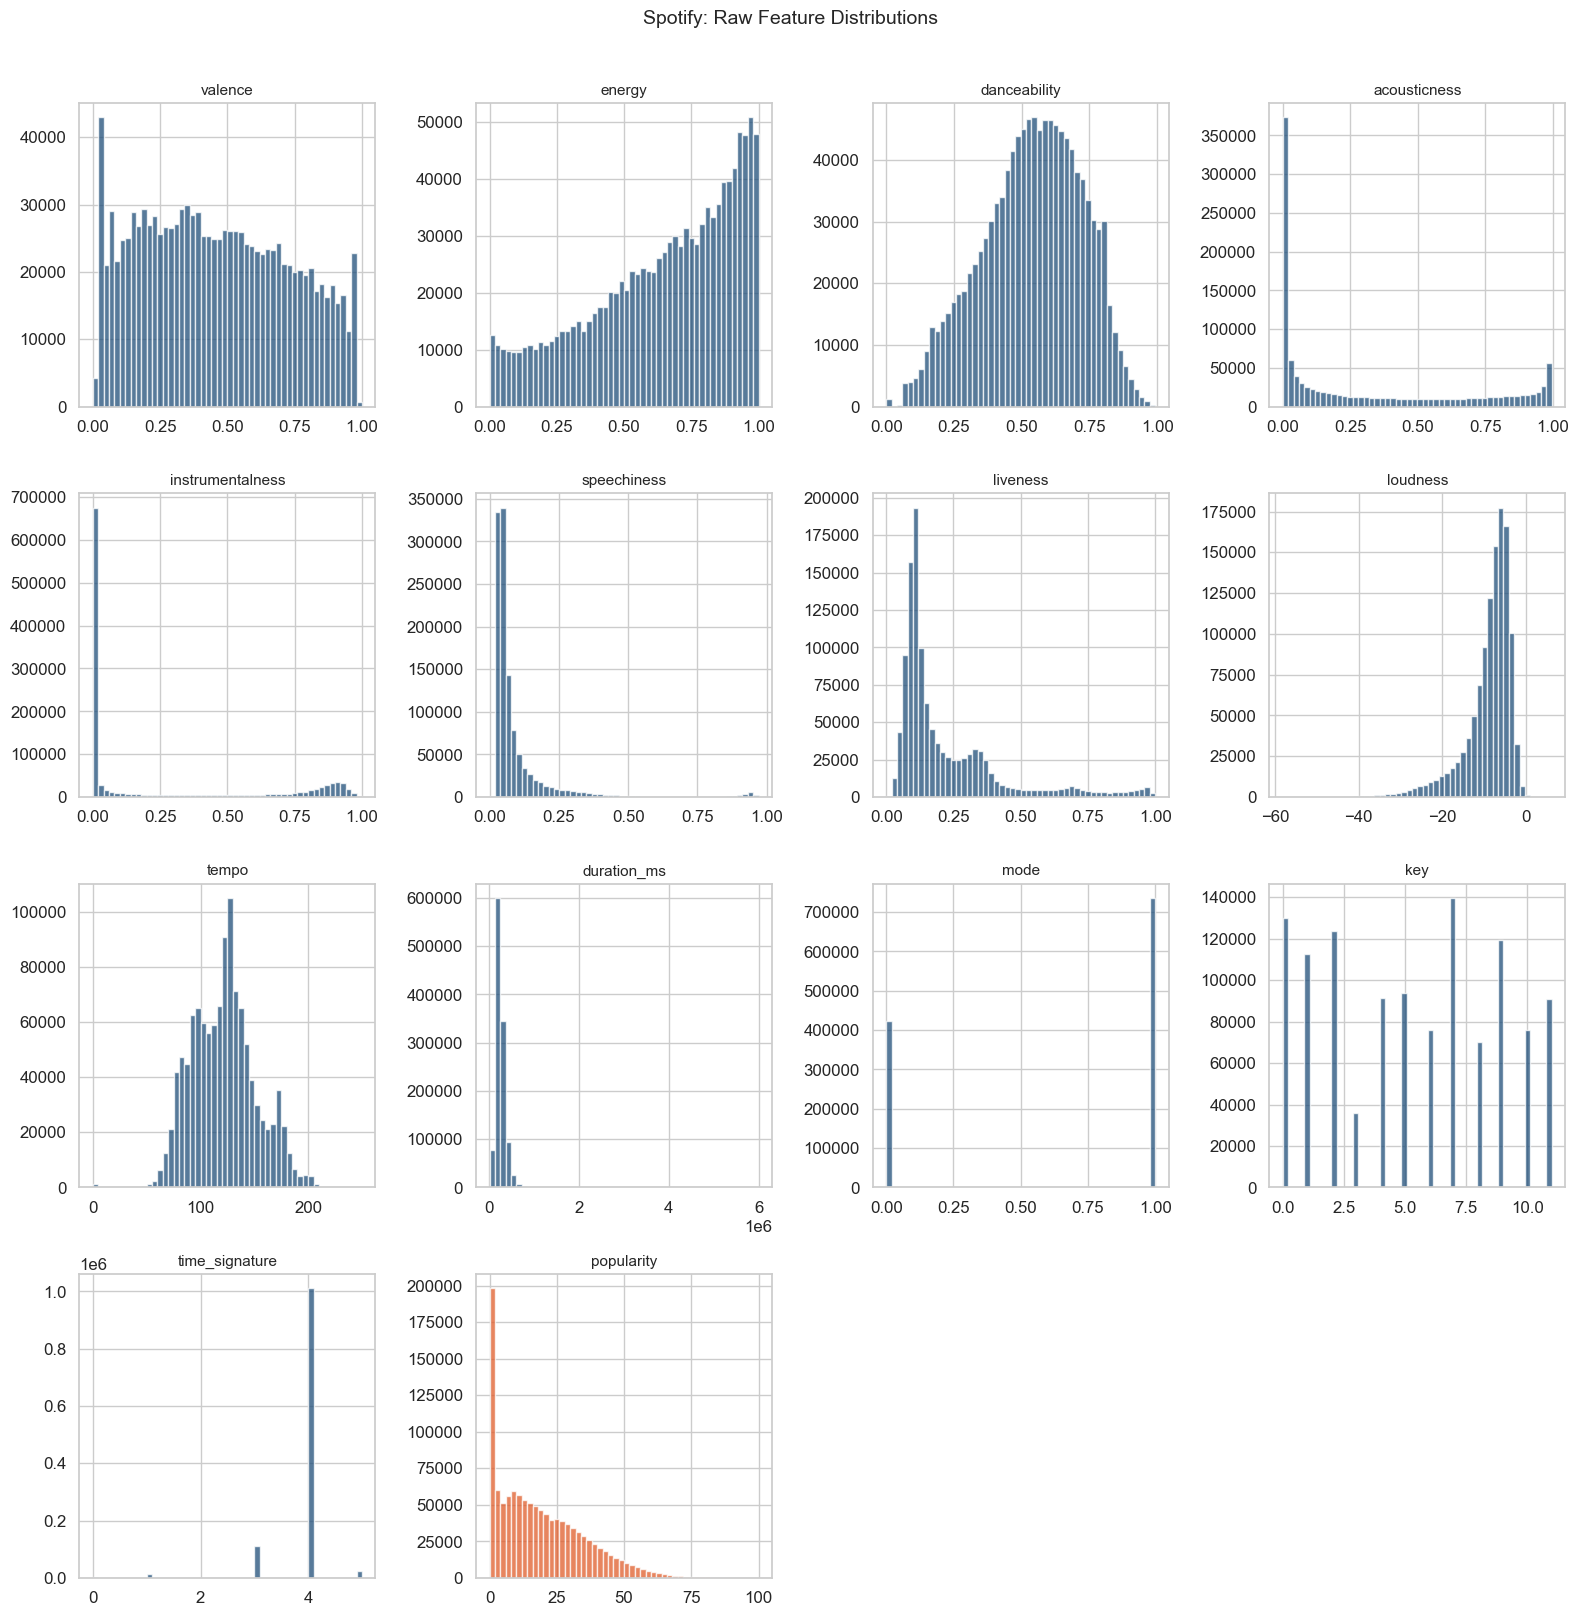

  Saved: outputs/fig_01_spotify_distributions.png


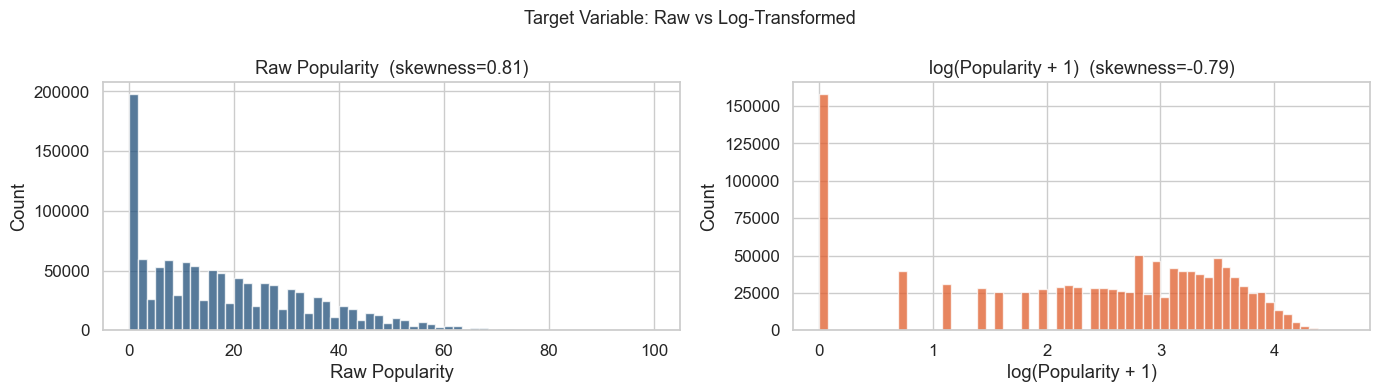

  Saved: outputs/fig_02_popularity_distribution.png


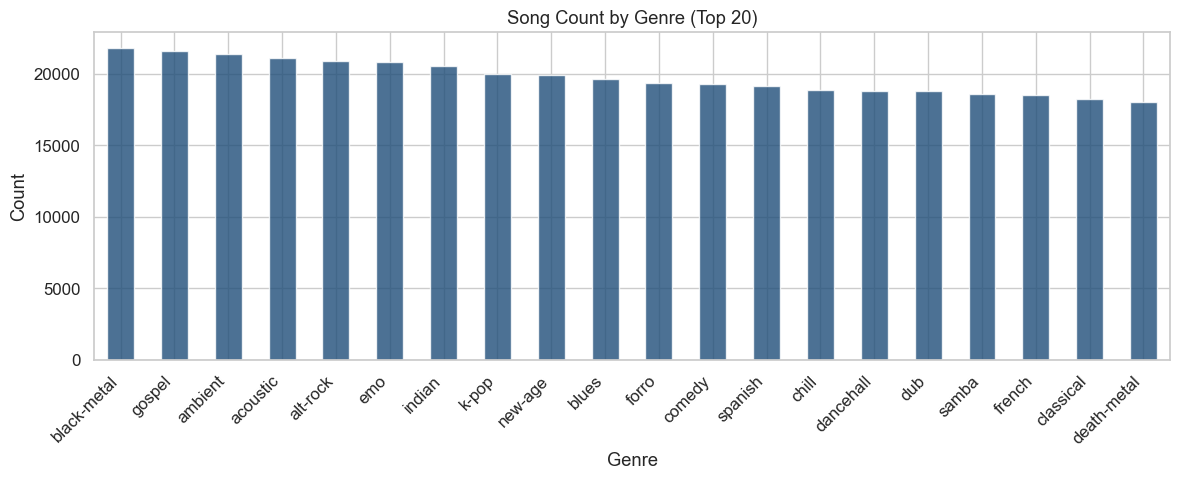

  Saved: outputs/fig_03_genre_distribution.png

  popularity=0: 13.7% of songs
  popularity>=50: 4.6% of songs


In [26]:
print("STEP 3: Spotify Raw EDA")
 
spotify_pd = pl_to_pd(spotify)
 
AUDIO_COLS = [c for c in [
    "valence", "energy", "danceability", "acousticness", "instrumentalness",
    "speechiness", "liveness", "loudness", "tempo", "duration_ms",
    "mode", "key", "time_signature", "popularity"
] if c in spotify_pd.columns]
 
# Summary stats + null check
print(spotify_pd[AUDIO_COLS].describe().round(3).to_string())
print("\nNulls:", spotify_pd[AUDIO_COLS].isnull().sum()[lambda x: x > 0].to_dict())
 
# Range check on bounded features
for col in ["valence","energy","danceability","acousticness",
            "instrumentalness","speechiness","liveness"]:
    if col in spotify_pd.columns:
        n = ((spotify_pd[col] < 0) | (spotify_pd[col] > 1)).sum()
        print(f"  {col}: {n} out-of-range {'⚠' if n > 0 else '✓'}")
 
# Distribution plots — all audio features
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, col in zip(axes.flatten(), AUDIO_COLS):
    ax.hist(spotify_pd[col].dropna(), bins=50,
            color=ORANGE if col == "popularity" else ACCENT,
            alpha=0.75, edgecolor="white")
    ax.set_title(col, fontsize=11)
[ax.set_visible(False) for ax in axes.flatten()[len(AUDIO_COLS):]]
plt.suptitle("Spotify: Raw Feature Distributions", fontsize=14, y=1.01)
save_fig("fig_01_spotify_distributions.png")
 
# Popularity: raw vs log
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title, color in zip(
    axes,
    [spotify_pd["popularity"], np.log1p(spotify_pd["popularity"])],
    ["Raw Popularity", "log(Popularity + 1)"],
    [ACCENT, ORANGE]
):
    ax.hist(data.dropna(), bins=60, color=color, alpha=0.75, edgecolor="white")
    ax.set_title(f"{title}  (skewness={data.skew():.2f})")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
plt.suptitle("Target Variable: Raw vs Log-Transformed", fontsize=13)
save_fig("fig_02_popularity_distribution.png")
 
# Genre distribution
if "genre" in spotify_pd.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    spotify_pd["genre"].value_counts().head(20).plot(
        kind="bar", ax=ax, color=ACCENT, alpha=0.8, edgecolor="white")
    ax.set(title="Song Count by Genre (Top 20)", xlabel="Genre", ylabel="Count")
    plt.xticks(rotation=45, ha="right")
    save_fig("fig_03_genre_distribution.png")
 
print(f"\n  popularity=0: {(spotify_pd['popularity']==0).mean()*100:.1f}% of songs")
print(f"  popularity>=50: {(spotify_pd['popularity']>=50).mean()*100:.1f}% of songs")

# EDA on raw spotify dataset

**Dataset:** 1,159,764 rows x 19 columns. No nulls. All bounded audio
features confirmed within [0,1] with no out of range values found.

**Feature distribution insights:**

- **acousticness** (mean=0.322, median=0.147): heavily right skewed.
  Most songs are electronic/produced with near zero acousticness, with
  a long tail of acoustic tracks. Log transformed before modeling.
- **instrumentalness** (mean=0.252, median=0.002): extremely right skewed.
  The vast majority of songs have vocals (value close to 0), with a small
  cluster of fully instrumental tracks near 1.0. Log transformed.
- **liveness** (mean=0.223, median=0.134): right skewed. Most songs are
  studio recordings. Log transformed.
- **loudness** (range: -58.1 to +6.2 dB, mean=-8.98): right skewed on
  the negative dB scale. Shifted to positive then log transformed.
- **duration_ms** (mean=249,562ms, max=6,000,495ms): extreme right tail
  from live recordings. Capped at 99th percentile (522,133ms) then
  log transformed.
- **speechiness** (mean=0.093, median=0.051): right skewed. Most songs
  are not spoken word. Retained in original scale (moderate skew).
- **danceability** (mean=0.537): approximately normal, well centered.
- **valence** (mean=0.456): approximately uniform. Songs span the full
  emotional range from very negative to very positive.
- **mode** (mean=0.635): 63.5% of songs are in major key (value=1).
- **key** (0 to 11): uniform distribution across all musical keys.
  Dropped because no meaningful linear ordering exists for a circular
  variable.
- **time_signature**: 95%+ of songs are in 4/4 time (value=4), giving
  near zero variance. Dropped.

**Target variable (popularity):**
Mean=18.4, median=15, max=100. Heavily right skewed (skewness=+0.810).
Large spike at 0 from unlisted/obscure tracks with no genuine streaming
signal, implying that transformation is needed. We will test multiple transformation techniques later.

**Decisions informed by this EDA:**
- Drop key and time_signature (no predictive value as numeric features)
- Log transform acousticness, instrumentalness, liveness, loudness,
  and duration_ms to reduce skewness before modeling
- Drop popularity=0 rows after joining (unreliable targets)
- Transform popularity

--- Skewness (closer to 0 = more normal) ---
  Raw popularity:        0.8100
  log(popularity + 1):   -0.7947

--- Shapiro-Wilk normality test (p > 0.05 = more normal) ---
  Raw popularity p-value:       0.000000 ✗ not normal
  log(popularity+1) p-value:    0.000000 ✗ not normal


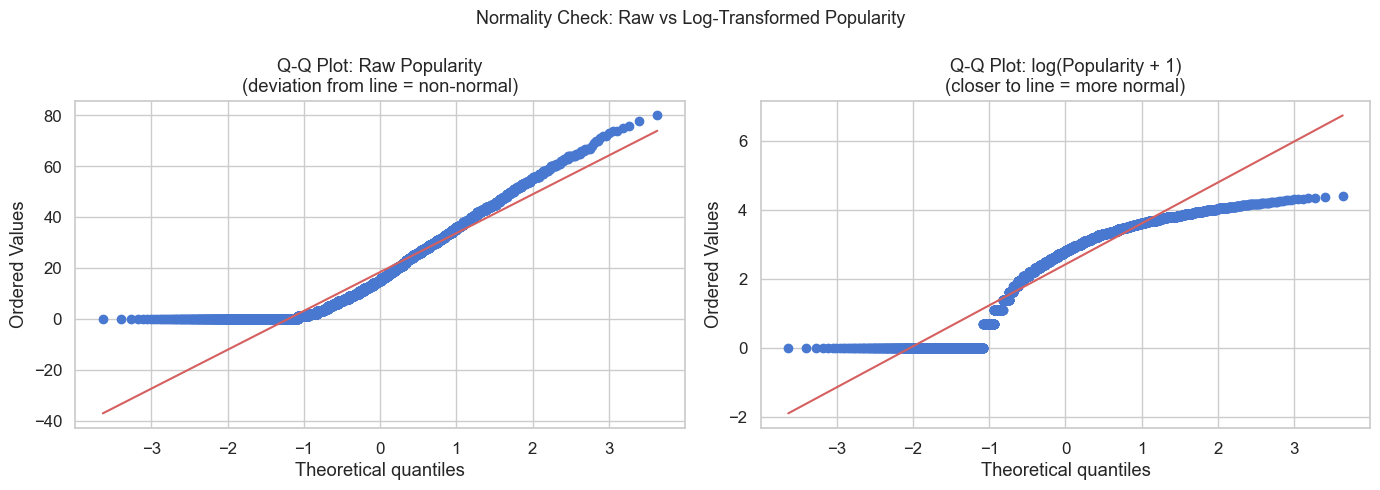

  Saved: outputs/fig_02b_qqplot_popularity.png

--- Kurtosis (closer to 0 = lighter tails) ---
  Raw popularity:       0.0653
  log(popularity + 1):  -0.5419

--- Verdict ---
  Log-transform ✓ IMPROVES normality (skewness 0.810 → -0.795)


In [27]:
# ── Justification: why log-transform popularity? ──────────────────────────────
from scipy import stats

raw = spotify_pd["popularity"].dropna()
log = np.log1p(raw)

# 1. Skewness comparison
print("--- Skewness (closer to 0 = more normal) ---")
print(f"  Raw popularity:        {raw.skew():.4f}")
print(f"  log(popularity + 1):   {log.skew():.4f}")

# 2. Shapiro-Wilk normality test on a sample (max 5000 rows)
sample = raw.sample(5000, random_state=42)
_, p_raw = stats.shapiro(sample)
_, p_log = stats.shapiro(np.log1p(sample))
print("\n--- Shapiro-Wilk normality test (p > 0.05 = more normal) ---")
print(f"  Raw popularity p-value:       {p_raw:.6f} {'✓' if p_raw > 0.05 else '✗ not normal'}")
print(f"  log(popularity+1) p-value:    {p_log:.6f} {'✓' if p_log > 0.05 else '✗ not normal'}")

# 3. Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stats.probplot(raw.sample(5000, random_state=42), plot=axes[0])
axes[0].set_title("Q-Q Plot: Raw Popularity\n(deviation from line = non-normal)")

stats.probplot(np.log1p(raw.sample(5000, random_state=42)), plot=axes[1])
axes[1].set_title("Q-Q Plot: log(Popularity + 1)\n(closer to line = more normal)")

plt.suptitle("Normality Check: Raw vs Log-Transformed Popularity", fontsize=13)
save_fig("fig_02b_qqplot_popularity.png")

# 4. Kurtosis comparison
print("\n--- Kurtosis (closer to 0 = lighter tails) ---")
print(f"  Raw popularity:       {raw.kurtosis():.4f}")
print(f"  log(popularity + 1):  {log.kurtosis():.4f}")

# 5. Summary verdict
print("\n--- Verdict ---")
better = abs(log.skew()) < abs(raw.skew())
print(f"  Log-transform {'✓ IMPROVES' if better else '✗ does NOT improve'} "
      f"normality (skewness {raw.skew():.3f} → {log.skew():.3f})")

--- Skewness comparison ---
  Raw                                 skewness=0.8100  kurtosis=0.0653
  log(x + 1)                          skewness=-0.7947  kurtosis=-0.5419
  sqrt(x)                             skewness=-0.2110  kurtosis=-0.8354
  log(x + 1) — no zeros               skewness=-0.7232  kurtosis=-0.1360


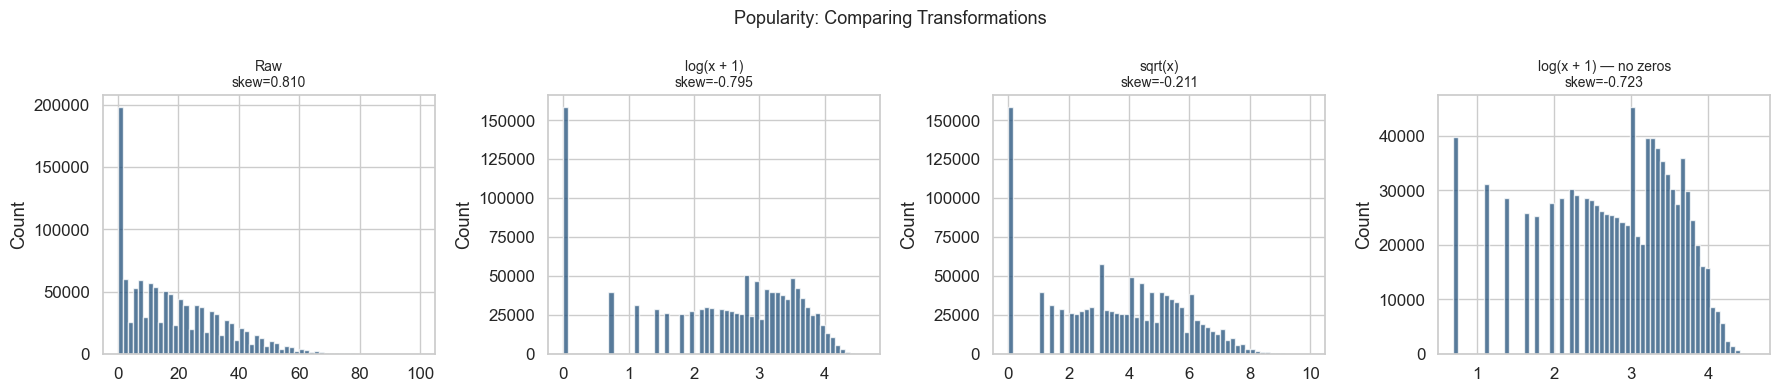

  Saved: outputs/fig_02c_transformation_comparison.png


In [28]:
# ── Compare three transformations ─────────────────────────────────────────────
raw   = spotify_pd["popularity"].dropna()

transforms = {
    "Raw":              raw,
    "log(x + 1)":       np.log1p(raw),
    "sqrt(x)":          np.sqrt(raw),
    "log(x + 1) — no zeros": np.log1p(raw[raw > 0]),
}

print("--- Skewness comparison ---")
for name, data in transforms.items():
    print(f"  {name:35s} skewness={data.skew():.4f}  kurtosis={data.kurtosis():.4f}")

# Plot all four
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, data) in zip(axes, transforms.items()):
    ax.hist(data, bins=60, color=ACCENT, alpha=0.75, edgecolor="white")
    ax.set_title(f"{name}\nskew={data.skew():.3f}", fontsize=10)
    ax.set_ylabel("Count")
plt.suptitle("Popularity: Comparing Transformations", fontsize=13)
save_fig("fig_02c_transformation_comparison.png")

# Target variable transformation decision
Four transformations were tested and compared by absolute skewness:

| Transformation | Skewness |
|---|---|
| Raw popularity | +0.810 |
| log(x + 1) | −0.795 |
| log(x + 1), no zeros | −0.723 |
| **√popularity** | **−0.211** ✓ |

**√popularity (square root transformation) was chosen** as the modeling target because it achieves the lowest absolute skewness (−0.211), it's closest to a symmetric distribution among all four candidates. While log(x+1) is a common choice for right-skewed targets, it overcorrected here by producing a left-skewed result (−0.795), nearly as far from zero as the original. Square root transformation produced the most balanced distribution, reducing RMSE sensitivity to high-popularity outliers while preserving interpretability. Raw popularity is retained in the dataset for back-transformation and result interpretation.

# Genius lyrics dataset raw EDA


STEP 4: Genius Lyrics Raw EDA


  Total English rows in Genius: 3,374,071
  EDA sample size:              10,000
  Lyric length — median: 1232 chars
  Word count   — median: 244 words


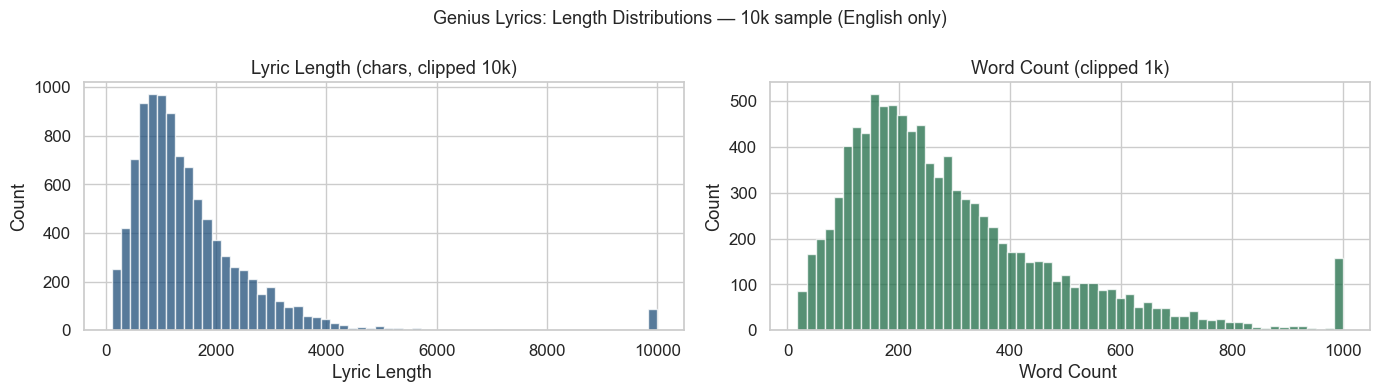

  Saved: outputs/fig_04_lyrics_distributions.png


In [29]:
# =============================================================================
# STEP 4: PHASE 1 EDA — GENIUS LYRICS RAW
# =============================================================================
print("\nSTEP 4: Genius Lyrics Raw EDA")

# Sample 10k rows for EDA only — no need to convert full dataset
SAMPLE_SIZE = 10_000
lyrics_sample = pd.DataFrame({
    "lyrics": lyrics["lyrics"].sample(SAMPLE_SIZE, seed=42).to_list()
})
lyrics_sample["lyric_len"]  = lyrics_sample["lyrics"].str.len()
lyrics_sample["word_count"] = lyrics_sample["lyrics"].str.split().str.len()

print(f"  Total English rows in Genius: {lyrics.shape[0]:,}")
print(f"  EDA sample size:              {SAMPLE_SIZE:,}")
print(f"  Lyric length — median: {lyrics_sample['lyric_len'].median():.0f} chars")
print(f"  Word count   — median: {lyrics_sample['word_count'].median():.0f} words")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, label, color in zip(
    axes,
    ["lyric_len", "word_count"],
    ["Lyric Length (chars, clipped 10k)", "Word Count (clipped 1k)"],
    [ACCENT, GREEN]
):
    ax.hist(lyrics_sample[col].clip(upper=10000 if col == "lyric_len" else 1000),
            bins=60, color=color, alpha=0.75, edgecolor="white")
    ax.set(title=label, xlabel=label.split("(")[0], ylabel="Count")
plt.suptitle("Genius Lyrics: Length Distributions — 10k sample (English only)", fontsize=13)
save_fig("fig_04_lyrics_distributions.png")

# EDA on Raw Genius Lyrics Dataset
**Lyric length distribution (left panel):**
Median lyric length is 1,232 characters. The distribution is right skewed
with a peak around 800 to 1,500 characters, then a long tail of very
long lyrics. The spike at 10,000 characters represents songs clipped
at the display ceiling , and some lyrics are substantially longer. Most
songs fall between 500 and 3,000 characters, consistent with a typical
2 to 4 minute pop or hip-hop song structure.

**Word count distribution (right panel):**
Median word count is 244 words. The distribution is approximately
right skewed with a peak around 150 to 250 words. Songs with very
high word counts (above 600) are relatively rare and likely represent
rap or spoken word tracks. The spike at 1,000 represents songs clipped
at the display ceiling.

**Decisions informed by this EDA:**
- Short lyrics under 100 characters are dropped during loading. VADER
  aggregates sentiment across all words , and those with fewer than roughly 15
  words the score is dominated by a single word and becomes unreliable.
- lyric_density (word count) is retained as a control variable in
  modeling. Higher word counts are associated with hip-hop and rap,
  which also tend to score higher on popularity (r=0.296 confirmed
  in Phase 2 EDA).
- The right-skewed distribution of lyric length confirms that most
  songs provide sufficient text for reliable VADER sentiment scoring.

# 2. Joining spotify and genius dataset


In [30]:
print("\nSTEP 5: Joining Spotify + Genius")
 
t = time.time()
joined = spotify.join(
    lyrics.select(["title_norm", "artist_norm", "lyrics"]),
    on=["title_norm", "artist_norm"],
    how="inner",
)
print(f"  Done in {time.time()-t:.1f}s")
print(f"  Spotify: {spotify.shape[0]:,}  |  Genius: {lyrics.shape[0]:,}  "
      f"|  Joined: {joined.shape[0]:,}  |  "
      f"Match rate: {joined.shape[0]/spotify.shape[0]*100:.1f}%")
print(f"  Unique songs: {joined['title_norm'].n_unique():,}")
print(f"  50k check: {'✓ PASS' if joined.shape[0] >= 50_000 else '✗ FAIL'} "
      f"({joined.shape[0]:,} rows)")



STEP 5: Joining Spotify + Genius
  Done in 0.2s
  Spotify: 1,159,764  |  Genius: 3,374,071  |  Joined: 311,525  |  Match rate: 26.9%
  Unique songs: 200,654
  50k check: ✓ PASS (311,525 rows)


In [31]:
# ── Quick check: first 5 rows of joined dataset ───────────────────────────────
print(joined.head(5))

shape: (5, 22)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ artist_na ┆ track_nam ┆ track_id  ┆ popularit ┆ … ┆ time_sign ┆ title_nor ┆ artist_no ┆ lyrics   │
│ me        ┆ e         ┆ ---       ┆ y         ┆   ┆ ature     ┆ m         ┆ rm        ┆ ---      │
│ ---       ┆ ---       ┆ str       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ str      │
│ str       ┆ str       ┆           ┆ f64       ┆   ┆ i64       ┆ str       ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ Cam’ron   ┆ Killa Cam ┆ 5WXBdxgQb ┆ 24.0      ┆ … ┆ 4         ┆ killa cam ┆ camron    ┆ [Chorus: │
│           ┆ (Intro)   ┆ JotSN8V2o ┆           ┆   ┆           ┆           ┆           ┆ Opera    │
│           ┆           ┆ uUYG      ┆           ┆   ┆           ┆           ┆           ┆ Steve &  │
│           ┆           ┆           ┆           ┆   ┆           ┆           

# 3. Post-Join Cleaning

In [32]:
print("\nSTEP 6: Cleaning")
 
n = joined.shape[0]
 
# Drop popularity = 0 (unlisted/unreliable tracks)
joined = joined.filter(pl.col("popularity") > 0)
print(f"  Dropped popularity=0:  {n - joined.shape[0]:,} rows")
 
# Keep only unique title+artist combos (remove ambiguous matches)
joined = (
    joined
    .with_columns(pl.len().over(["title_norm", "artist_norm"]).alias("n"))
    .filter(pl.col("n") == 1)
    .drop("n")
)
print(f"  After dedup:           {joined.shape[0]:,} rows")
 
# Verify
assert joined.group_by(["title_norm","artist_norm"]).len().filter(
    pl.col("len") > 1).shape[0] == 0, "Duplicates remain!"
print(f"  ✓ No duplicate title+artist combos remain")
print(f"  50k check: {'✓ PASS' if joined.shape[0] >= 50_000 else '✗ FAIL'} "
      f"({joined.shape[0]:,} rows)")


STEP 6: Cleaning
  Dropped popularity=0:  5,787 rows
  After dedup:           288,820 rows
  ✓ No duplicate title+artist combos remain
  50k check: ✓ PASS (288,820 rows)


# Post-join Decisions
- We decided to drop popularity that equals to zero since popularity being marked as zero in the spotify dataset implies that the track was unindexed or removed from Spotify's active catalog, rather than its actual popularity. Therefore, including rows with pouplarity = 0 would cause inaccuracy in our target variables. 
- We also decided to keep only unique title + artists combinations since sometimes if the same song is release multiple times for different versions(i.e. deluxe, explicit vs clean, etc), the number of songs would make a disproportionate influence in our model


# 4. Feature Engineering: Creating Paradox Score

# 4.1 Vader Sentiment Analysis for Paradox Score


STEP 7: VADER Sentiment Analysis
  Done in 1083.5s on 288,820 songs
  lyric_sentiment — mean=0.576  min=0.000  max=1.000


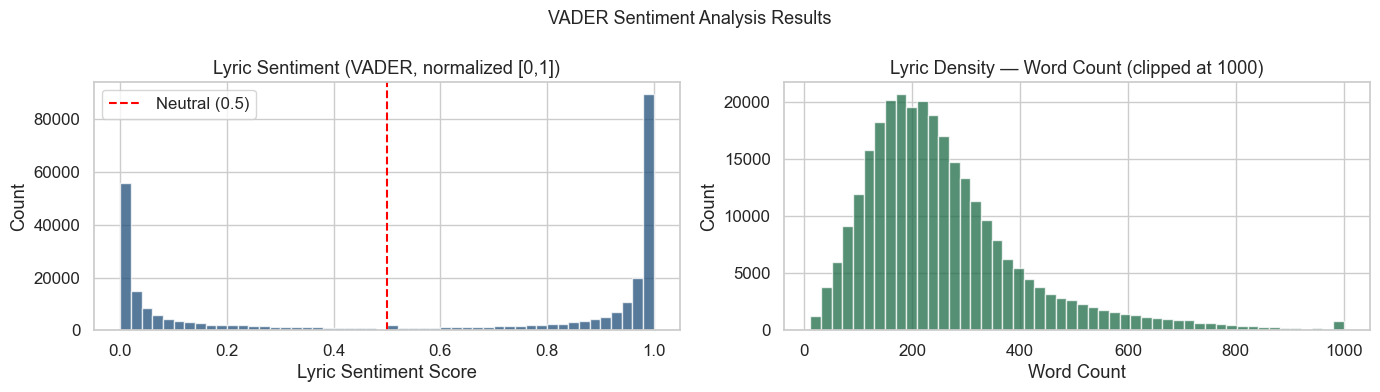

  Saved: outputs/fig_05_vader_sentiment.png


In [33]:
print("\nSTEP 7: VADER Sentiment Analysis")
 
joined_pd = pl_to_pd(joined)
 
t = time.time()
joined_pd["lyric_sentiment"] = joined_pd["lyrics"].apply(vader_sentiment)
joined_pd["lyric_density"]   = joined_pd["lyrics"].str.split().str.len()
print(f"  Done in {time.time()-t:.1f}s on {len(joined_pd):,} songs")
print(f"  lyric_sentiment — mean={joined_pd['lyric_sentiment'].mean():.3f}  "
      f"min={joined_pd['lyric_sentiment'].min():.3f}  "
      f"max={joined_pd['lyric_sentiment'].max():.3f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(joined_pd["lyric_sentiment"], bins=50,
             color=ACCENT, alpha=0.75, edgecolor="white")
axes[0].axvline(0.5, color="red", linestyle="--", label="Neutral (0.5)")
axes[0].set(title="Lyric Sentiment (VADER, normalized [0,1])",
            xlabel="Lyric Sentiment Score", ylabel="Count")
axes[0].legend()
 
axes[1].hist(joined_pd["lyric_density"].clip(upper=1000), bins=50,
             color=GREEN, alpha=0.75, edgecolor="white")
axes[1].set(title="Lyric Density — Word Count (clipped at 1000)",
            xlabel="Word Count", ylabel="Count")
plt.suptitle("VADER Sentiment Analysis Results", fontsize=13)
save_fig("fig_05_vader_sentiment.png")

# Justification for normalizing
- Why we normalized to [0,1]:
The original reasoning was to match Spotify's valence scale (which is [0,1]) so that the Paradox Score formula |valence - lyric_sentiment| makes sense dimensionally. If lyric_sentiment stayed in [-1,1] and valence is in [0,1], the subtraction would be comparing incompatible scales.

# Findings from VADER Sentiment Analysis
 - Mean sentiment = 0.576 : songs lean slightly positive lyrically.
 - Two spikes visible at 0.0 and 1.0: VADER artifact where the model
   assigns maximum confidence scores to many songs. This is a known
   limitation of VADER's rule-based approach.
 - lyric_density (word count) is approximately normal, median ~200 words.
 - Limitation: VADER trained on social media text, so it may underperform
   on complex metaphorical lyrics. A transformer-based model (e.g.
   RoBERTa) would reduce these extreme scores but is outside scope.
 - Therefore, we decided to keep normalization as it is. Paradox Score remains valid
   since both valence and lyric_sentiment are on [0,1] scale.

# 4.2 Compute Paradox Score

In [ ]:
# Core novel feature — Paradox Score
joined_pd["paradox_score"] = abs(
    joined_pd["valence"] - joined_pd["lyric_sentiment"]
)

# Square root transform of target variable
joined_pd["popularity_sqrt"] = np.sqrt(joined_pd["popularity"])

# Sanity checks
assert joined_pd["paradox_score"].between(0, 1).all(), "paradox_score out of [0,1]!"
assert (joined_pd["popularity_sqrt"] >= 0).all(),      "popularity_sqrt has negatives!"

print(f"  paradox_score    — min={joined_pd['paradox_score'].min():.3f}  "
      f"max={joined_pd['paradox_score'].max():.3f}  "
      f"mean={joined_pd['paradox_score'].mean():.3f}")
print(f"  popularity_sqrt  — min={joined_pd['popularity_sqrt'].min():.3f}  "
      f"max={joined_pd['popularity_sqrt'].max():.3f}  "
      f"mean={joined_pd['popularity_sqrt'].mean():.3f}")
print(f"  ✓ All engineered features validated")


STEP 8: Feature Engineering
  paradox_score    — min=0.000  max=0.998  mean=0.419
  popularity_sqrt  — min=1.000  max=9.539  mean=4.812
  ✓ All engineered features validated


# Findings: Feature Engineering
 - paradox_score = |valence - lyric_sentiment| confirmed in [0,1].
   Mean= 0.419 , which means that average song has moderate emotional incongruence.
 - popularity_log applied to reduce right-skew of target.


# 5. Assemble and Save Final Dataset

In [35]:
print("\nSTEP 9: Saving final dataset")
 
FINAL_COLS = [
    "track_id", "track_name", "artist_name",
    "valence", "energy", "danceability", "tempo",
    "acousticness", "instrumentalness", "liveness",
    "loudness", "speechiness", "mode", "key",
    "duration_ms", "time_signature",
    "genre", "year",
    "lyric_sentiment", "lyric_density",
    "paradox_score",
    "popularity", "popularity_sqrt",
]
FINAL_COLS = [c for c in FINAL_COLS if c in joined_pd.columns]
final_df   = joined_pd[FINAL_COLS].copy()
 
print(f"  Shape:   {final_df.shape[0]:,} rows x {final_df.shape[1]} cols")
print(f"  Nulls:   {final_df.isnull().sum().sum()} total")
print(f"  50k check: {'✓ PASS' if len(final_df) >= 50_000 else '✗ FAIL'} "
      f"({len(final_df):,} rows)")
 
print(f"\n  Columns:")
for col in FINAL_COLS:
    print(f"    {col:35s} {str(final_df[col].dtype):12s} "
          f"nulls={final_df[col].isnull().sum()}")
 
print(f"\n  Sample:")
print(final_df[["track_name","artist_name","valence",
                "lyric_sentiment","paradox_score","popularity"
                ]].head(5).to_string(index=False))
 
final_df.to_csv("outputs/joined_data.csv", index=False)
print(f"\n  ✓ Saved to outputs/joined_data.csv")
print(f"  ✓ Next session: df = pd.read_csv('outputs/joined_data.csv')")
print(f"  ✓ Next step: Section 2 — Pre-processing pipeline")


STEP 9: Saving final dataset
  Shape:   288,820 rows x 23 cols
  Nulls:   0 total
  50k check: ✓ PASS (288,820 rows)

  Columns:
    track_id                            str          nulls=0
    track_name                          str          nulls=0
    artist_name                         str          nulls=0
    valence                             float64      nulls=0
    energy                              float64      nulls=0
    danceability                        float64      nulls=0
    tempo                               float64      nulls=0
    acousticness                        float64      nulls=0
    instrumentalness                    float64      nulls=0
    liveness                            float64      nulls=0
    loudness                            float64      nulls=0
    speechiness                         float64      nulls=0
    mode                                int64        nulls=0
    key                                 int64        nulls=0
    duration_ms 

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, pearsonr
import os, warnings
 
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)
 
ACCENT = "#1F4E79"
ORANGE = "#E05C2A"
GREEN  = "#1D6B45"
 
def save_fig(fname):
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: outputs/{fname}")
 
# ── Load toggle ───────────────────────────────────────────────────────────────
LOAD_FROM_CSV = True  # set False only for final submission run
 
if LOAD_FROM_CSV:
    df = pd.read_csv("outputs/joined_data_clean.csv")
    print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
else:
    # df already in memory from Steps 1-9
    pass
 
# =============================================================================
# PRE-PROCESSING SUMMARY & SAVE
# =============================================================================
print("\nPRE-PROCESSING SUMMARY")
print("=" * 60)
print(f"  Final shape:  {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Null counts:  {df.isnull().sum().sum()}")
print(f"\n  Columns ({df.shape[1]}):")
for col in df.columns:
    print(f"    {col:30s} dtype={str(df[col].dtype):10s} "
          f"skew={df[col].skew():.3f}" 
          if df[col].dtype in [np.float64, np.int64] 
          else f"    {col:30s} dtype={str(df[col].dtype)}")
 
print(f"\n  Skewness of transformed features:")
for col in ["acousticness_log", "instrumentalness_log",
            "liveness_log", "loudness_log", "duration_ms_log"]:
    print(f"    {col:25s}: {df[col].skew():.3f}")
 
# Save clean dataset
df.to_csv("outputs/joined_data_clean.csv", index=False)
print(f"\n  ✓ Saved outputs/joined_data_clean.csv")

Loaded: 288,819 rows x 21 cols

PRE-PROCESSING SUMMARY
  Final shape:  288,819 rows x 21 cols
  Null counts:  0

  Columns (21):
    track_id                       dtype=str
    track_name                     dtype=str
    artist_name                    dtype=str
    valence                        dtype=float64    skew=0.287
    energy                         dtype=float64    skew=-0.747
    danceability                   dtype=float64    skew=-0.044
    tempo                          dtype=float64    skew=0.339
    speechiness                    dtype=float64    skew=3.090
    mode                           dtype=int64      skew=-0.657
    genre                          dtype=str
    year                           dtype=int64      skew=-0.181
    lyric_sentiment                dtype=float64    skew=-0.315
    lyric_density                  dtype=int64      skew=2.146
    paradox_score                  dtype=float64    skew=0.173
    popularity                     dtype=float64    skew

In [48]:
print(f"\n  Final columns ({df.shape[1]}):")
for col in df.columns:
    print(f"    {col}")


  Final columns (21):
    track_id
    track_name
    artist_name
    valence
    energy
    danceability
    tempo
    speechiness
    mode
    genre
    year
    lyric_sentiment
    lyric_density
    paradox_score
    popularity
    popularity_sqrt
    acousticness_log
    instrumentalness_log
    liveness_log
    loudness_log
    duration_ms_log


In [ ]:
# Drop valence (captured by paradox_score) and popularity (using popularity_sqrt)
df = df.drop(columns=["valence", "popularity"], errors="ignore")
# we dropped valence since we already used it computing paradox_score, and we are not planning on using
# just valence as a feature by itself. we dropped popularity since we now have the transfromed square root popularity

print(f"Shape after dropping: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Remaining columns: {df.columns.tolist()}")

# Resave
df.to_csv("outputs/joined_data_clean.csv", index=False)
print("✓ Saved outputs/joined_data_clean.csv")

Shape after dropping: 288,819 rows x 19 cols
Remaining columns: ['track_id', 'track_name', 'artist_name', 'energy', 'danceability', 'tempo', 'speechiness', 'mode', 'genre', 'year', 'lyric_sentiment', 'lyric_density', 'paradox_score', 'popularity_sqrt', 'acousticness_log', 'instrumentalness_log', 'liveness_log', 'loudness_log', 'duration_ms_log']
✓ Saved outputs/joined_data_clean.csv


# Pre-processing Summary

 Starting from 288,819 joined songs, the following decisions were made:

 **Columns dropped:**
 - `key`: musical key (0–11) has no meaningful linear ordering and misleads
   Ridge Regression. Dropped.
 - `time_signature`: 95%+ of songs are 4/4 so it has near-zero variance. Drop it.

 **Log transformations applied:**
 - `acousticness` → `acousticness_log` (log1p): right-skewed, many near-zero
   values for electronic/produced music.
 - `instrumentalness` → `instrumentalness_log` (log1p): extremely right-skewed,
   median=0.0002. Most songs have vocals; a small number are purely instrumental.
 - `liveness` → `liveness_log` (log1p): right-skewed, most songs are studio
   recordings with low liveness scores.
 - `loudness` → `loudness_log` (log1p after shift): negative dB scale [-58, +6].
   Shifted to positive before log-transforming.
 - `duration_ms` → `duration_ms_log` (log1p after 99th pct cap at 522,133ms):   extreme right tail from live recordings. Capped then log-transformed.

 **Remaining skewness after transformation:**
 Some residual skewness remains in transformed features (e.g. loudness_log=-2.288,
 liveness_log=1.595). This is a known limitation of log transformation on
 bimodal or heavily zero-inflated distributions. Tree models (Random Forest,
 Gradient Boosting) are unaffected. For Ridge Regression, StandardScaler
 applied during modeling further reduces the practical impact.

 **No null values** remain in the final dataset (verified above).
**Final dataset: 288,819 rows x 21 columns.**

In [24]:
# =============================================================================
# PRE-PROCESSING: Feature Cleaning & Transformation
# =============================================================================

# Reload fresh from original CSV
df = pd.read_csv("outputs/joined_data.csv").dropna(subset=["artist_name"])

# 1. Drop key and time_signature
df = df.drop(columns=["key", "time_signature"], errors="ignore")

# 2. Log-transform all skewed features
df["acousticness_log"]     = np.log1p(df["acousticness"])
df["instrumentalness_log"] = np.log1p(df["instrumentalness"])
df["liveness_log"]         = np.log1p(df["liveness"])
df["loudness_log"]         = np.log1p(df["loudness"] - df["loudness"].min())
df["duration_ms_log"]      = np.log1p(df["duration_ms"].clip(upper=522133))

# 3. Drop original skewed columns
df = df.drop(columns=["acousticness", "instrumentalness",
                       "liveness", "loudness", "duration_ms"])

# 4. Verify skewness improved
print("Skewness after transformation:")
for col in ["acousticness_log", "instrumentalness_log",
            "liveness_log", "loudness_log", "duration_ms_log"]:
    print(f"  {col:25s}: {df[col].skew():.3f}")

print(f"\nFinal shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")

# 5. Save clean dataset
df.to_csv("outputs/joined_data_clean.csv", index=False)
print("\n✓ Saved outputs/joined_data_clean.csv")

Skewness after transformation:
  acousticness_log         : 1.216
  instrumentalness_log     : 2.043
  liveness_log             : 1.595
  loudness_log             : -2.288
  duration_ms_log          : -0.711

Final shape: 288,819 rows x 21 cols
Columns: ['track_id', 'track_name', 'artist_name', 'valence', 'energy', 'danceability', 'tempo', 'speechiness', 'mode', 'genre', 'year', 'lyric_sentiment', 'lyric_density', 'paradox_score', 'popularity', 'popularity_sqrt', 'acousticness_log', 'instrumentalness_log', 'liveness_log', 'loudness_log', 'duration_ms_log']

✓ Saved outputs/joined_data_clean.csv


# 5. Phase 2 EDA on preprocessed data

In [65]:
print(df.columns.tolist())
print(f"\nGenre cols: {[c for c in df.columns if c.startswith('genre_')]}")
print(f"\nGenre counts:")
genre_cols = [c for c in df.columns if c.startswith('genre_')]
print(df[genre_cols].sum().sort_values(ascending=False))

['track_id', 'track_name', 'artist_name', 'energy', 'danceability', 'tempo', 'speechiness', 'mode', 'year', 'lyric_sentiment', 'lyric_density', 'paradox_score', 'popularity_sqrt', 'acousticness_log', 'instrumentalness_log', 'liveness_log', 'loudness_log', 'duration_ms_log', 'genre_alt-rock', 'genre_black-metal', 'genre_country', 'genre_dance', 'genre_death-metal', 'genre_emo', 'genre_folk', 'genre_hardcore', 'genre_hip-hop', 'genre_other']

Genre cols: ['genre_alt-rock', 'genre_black-metal', 'genre_country', 'genre_dance', 'genre_death-metal', 'genre_emo', 'genre_folk', 'genre_hardcore', 'genre_hip-hop', 'genre_other']

Genre counts:
genre_other          174766
genre_alt-rock        15409
genre_emo             14308
genre_country         13052
genre_death-metal     12584
genre_hardcore        11187
genre_dance           10798
genre_hip-hop          9696
genre_folk             9028
genre_black-metal      8562
dtype: int64


# 5.1 lyric sentiment vs paradox score


EDA 1: Sonic Paradox Map


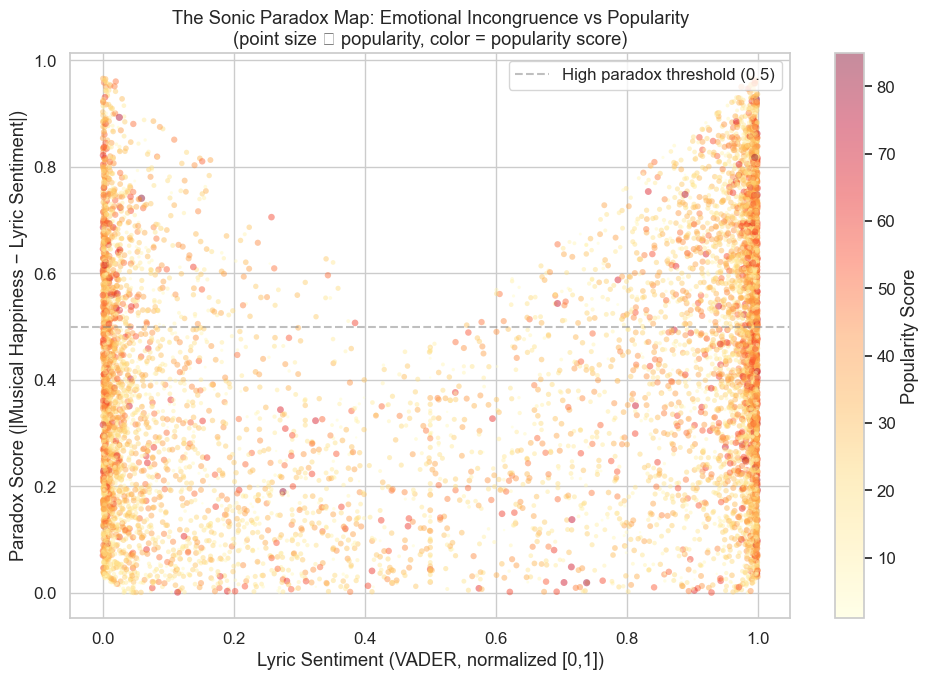

  Saved: outputs/fig_06_sonic_paradox_map.png


In [27]:
print("EDA 1: Sonic Paradox Map")
 
# Reconstruct valence proxy from paradox_score + lyric_sentiment
# valence was dropped but paradox_score = |valence - lyric_sentiment|
# We can still plot lyric_sentiment vs paradox_score directly
sample = df.sample(8000, random_state=42)
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    sample["lyric_sentiment"],
    sample["paradox_score"],
    c=sample["popularity_sqrt"] ** 2,   # back to raw popularity for color
    cmap="YlOrRd",
    alpha=0.45,
    s=sample["popularity_sqrt"] * 3,
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="Popularity Score")
 
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5,
           label="High paradox threshold (0.5)")
ax.set(xlabel="Lyric Sentiment (VADER, normalized [0,1])",
       ylabel="Paradox Score (|Musical Happiness − Lyric Sentiment|)",
       title="The Sonic Paradox Map: Emotional Incongruence vs Popularity\n"
             "(point size ∝ popularity, color = popularity score)")
ax.legend(loc="upper right")
save_fig("fig_06_sonic_paradox_map.png")

In [29]:
# Redefine after loading joined_data_clean.csv
GENRE_COLS = [c for c in df.columns if c.startswith("genre_")]
print(f"Genre cols found: {GENRE_COLS}")

Genre cols found: ['genre_label']


# 5.2 Paradox Score Distribution


EDA 2: Paradox Score Distribution


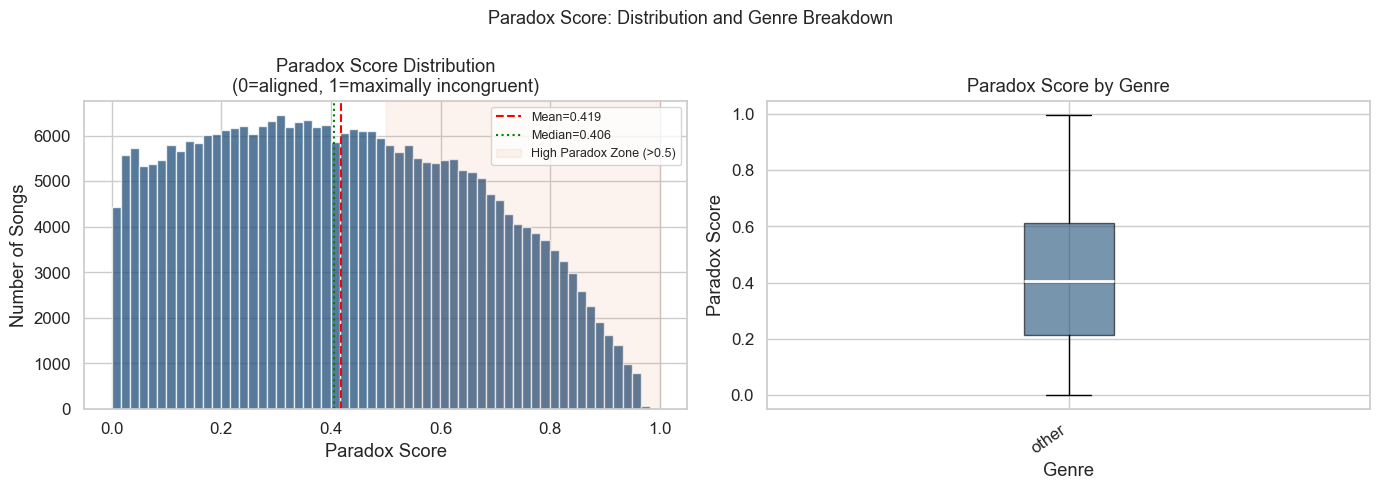

  Saved: outputs/fig_07_paradox_score_distribution.png
  mean=0.419  std=0.246  median=0.406  >0.5: 38.2%


In [30]:
# EDA 2: PARADOX SCORE DISTRIBUTION
# =============================================================================
print("\nEDA 2: Paradox Score Distribution")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Histogram
axes[0].hist(df["paradox_score"], bins=60, color=ACCENT,
             alpha=0.75, edgecolor="white")
axes[0].axvline(df["paradox_score"].mean(), color="red",
                linestyle="--",
                label=f"Mean={df['paradox_score'].mean():.3f}")
axes[0].axvline(df["paradox_score"].median(), color="green",
                linestyle=":", 
                label=f"Median={df['paradox_score'].median():.3f}")
axes[0].axvspan(0.5, 1.0, alpha=0.07, color=ORANGE,
                label="High Paradox Zone (>0.5)")
axes[0].set(title="Paradox Score Distribution\n"
                  "(0=aligned, 1=maximally incongruent)",
            xlabel="Paradox Score", ylabel="Number of Songs")
axes[0].legend(fontsize=9)
 
# Paradox score by genre (reconstruct genre label from dummies)
df["genre_label"] = "other"
for col in GENRE_COLS[:-1]:   # skip genre_other
    genre_name = col.replace("genre_", "")
    df.loc[df[col] == 1, "genre_label"] = genre_name
 
genre_order = (df.groupby("genre_label")["paradox_score"]
               .median().sort_values(ascending=False).index)
genre_data  = [df[df["genre_label"] == g]["paradox_score"].values
               for g in genre_order]
bp = axes[1].boxplot(genre_data, labels=genre_order,
                     patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch in bp["boxes"]:
    patch.set(facecolor=ACCENT, alpha=0.6)
axes[1].set(title="Paradox Score by Genre",
            xlabel="Genre", ylabel="Paradox Score")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=35, ha="right")
 
plt.suptitle("Paradox Score: Distribution and Genre Breakdown", fontsize=13)
save_fig("fig_07_paradox_score_distribution.png")
 
high_pct = (df["paradox_score"] > 0.5).mean() * 100
print(f"  mean={df['paradox_score'].mean():.3f}  "
      f"std={df['paradox_score'].std():.3f}  "
      f"median={df['paradox_score'].median():.3f}  "
      f">0.5: {high_pct:.1f}%")

# 5.3 Hypothesis Preview


EDA 3: Hypothesis Preview
  Mean popularity_sqrt — Low=4.614  Medium=4.896  High=4.925
  Kruskal-Wallis p=0.0000  |  Mann-Whitney p=0.0000


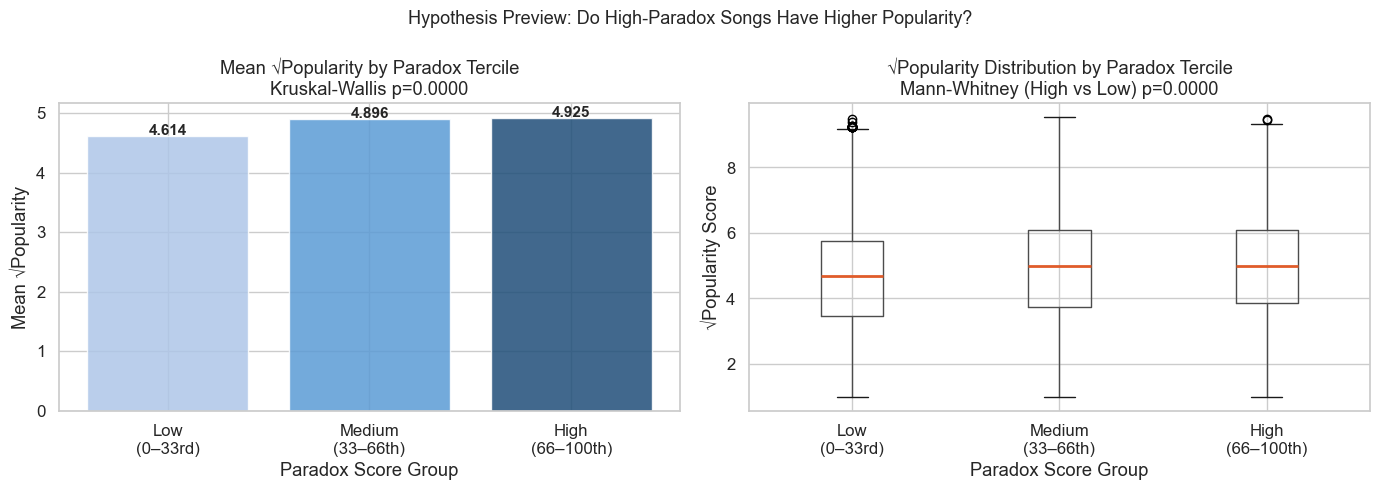

  Saved: outputs/fig_08_hypothesis_preview.png


In [32]:
# =============================================================================
# EDA 3: HYPOTHESIS PREVIEW — PARADOX TERCILES VS POPULARITY
# =============================================================================

print("\nEDA 3: Hypothesis Preview")
from scipy.stats import kruskal, mannwhitneyu
df["paradox_tercile"] = pd.qcut(
    df["paradox_score"], q=3,
    labels=["Low\n(0–33rd)", "Medium\n(33–66th)", "High\n(66–100th)"]
)
 
# Statistical tests
groups  = [df[df["paradox_tercile"] == g]["popularity_sqrt"].values
           for g in df["paradox_tercile"].cat.categories]
_, p_kw = kruskal(*groups)
 
low_g   = df[df["paradox_tercile"] == "Low\n(0–33rd)"]["popularity_sqrt"]
high_g  = df[df["paradox_tercile"] == "High\n(66–100th)"]["popularity_sqrt"]
_, p_mw = mannwhitneyu(high_g, low_g, alternative="two-sided")
 
tercile_means = (df.groupby("paradox_tercile", observed=True)
                 ["popularity_sqrt"].mean())
print(f"  Mean popularity_sqrt — "
      f"Low={tercile_means.iloc[0]:.3f}  "
      f"Medium={tercile_means.iloc[1]:.3f}  "
      f"High={tercile_means.iloc[2]:.3f}")
print(f"  Kruskal-Wallis p={p_kw:.4f}  |  Mann-Whitney p={p_mw:.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
colors = ["#AEC6E8", "#5B9BD5", ACCENT]
bars = axes[0].bar(
    df["paradox_tercile"].cat.categories,
    tercile_means, color=colors, edgecolor="white", alpha=0.85
)
for bar, val in zip(bars, tercile_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[0].set(title=f"Mean √Popularity by Paradox Tercile\n"
                  f"Kruskal-Wallis p={p_kw:.4f}",
            xlabel="Paradox Score Group",
            ylabel="Mean √Popularity")
 
df.boxplot(column="popularity_sqrt", by="paradox_tercile",
           ax=axes[1], medianprops=dict(color=ORANGE, linewidth=2))
axes[1].set(title=f"√Popularity Distribution by Paradox Tercile\n"
                  f"Mann-Whitney (High vs Low) p={p_mw:.4f}",
            xlabel="Paradox Score Group", ylabel="√Popularity Score")
plt.suptitle("Hypothesis Preview: Do High-Paradox Songs Have "
             "Higher Popularity?", fontsize=13)
save_fig("fig_08_hypothesis_preview.png")

## Hypothesis Preview

Mean √popularity by paradox tercile:
- Low: 4.614  Medium: 4.896  High: 4.925

Both Kruskal-Wallis (p=0.0000) and Mann-Whitney U (p=0.0000) are
statistically significant, but with 288,819 songs even trivially small
differences produce significant p-values. In practical terms, high-paradox
songs score only ~3 popularity points higher than low-paradox songs on
the 0-100 scale,  a negligible real-world difference.

The box plots confirm this: distributions across all three groups are
nearly identical in shape, median, and spread. This suggests paradox
score alone is a weak predictor of popularity in isolation.

This motivates our modeling approach: rather than testing paradox score
in isolation, we use Ridge Regression, Random Forest, and Gradient
Boosting to test whether paradox score contributes meaningfully after
controlling for genre, year, and all audio features.

#  5.4 Correlation Heatmap


EDA 4: Correlation Heatmap


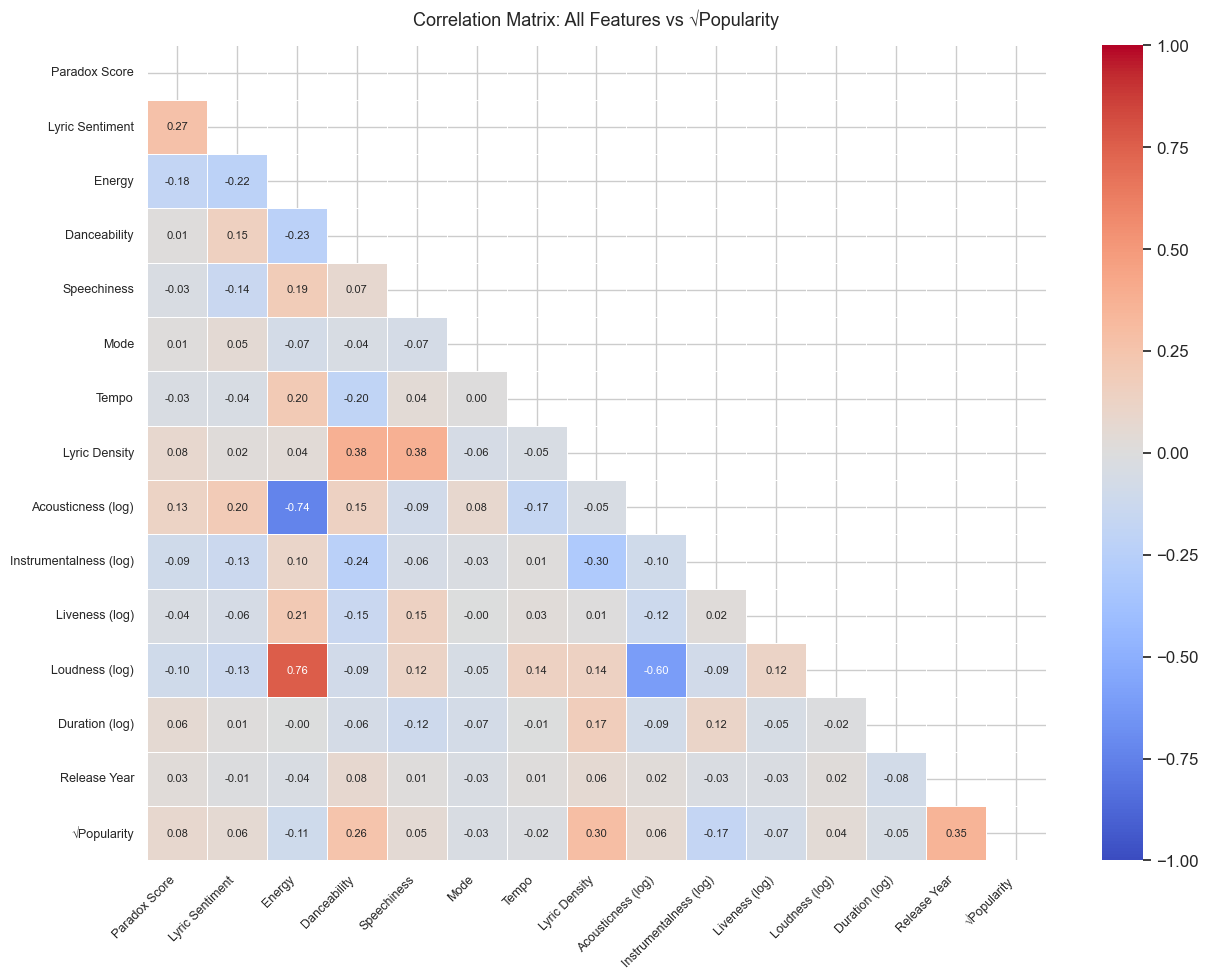

  Saved: outputs/fig_09_correlation_heatmap.png

  Feature correlations with √popularity (|r| sorted):
year                    0.352
lyric_density           0.296
danceability            0.257
instrumentalness_log    0.174
energy                  0.106
paradox_score           0.082
liveness_log            0.073
lyric_sentiment         0.060
acousticness_log        0.059
speechiness             0.050
duration_ms_log         0.047
loudness_log            0.042
mode                    0.034
tempo                   0.022

  Pairs with |r| > 0.6 (excluding target):
    energy & acousticness_log: r=-0.742
    energy & loudness_log: r=0.761
    acousticness_log & loudness_log: r=-0.603


In [33]:
# =============================================================================
# EDA 4: CORRELATION HEATMAP
# =============================================================================
print("\nEDA 4: Correlation Heatmap")
 
CORR_COLS = [c for c in [
    "paradox_score", "lyric_sentiment", "energy", "danceability",
    "speechiness", "mode", "tempo", "lyric_density",
    "acousticness_log", "instrumentalness_log", "liveness_log",
    "loudness_log", "duration_ms_log", "year", "popularity_sqrt"
] if c in df.columns]
 
rename = {
    "paradox_score":        "Paradox Score",
    "lyric_sentiment":      "Lyric Sentiment",
    "energy":               "Energy",
    "danceability":         "Danceability",
    "speechiness":          "Speechiness",
    "mode":                 "Mode",
    "tempo":                "Tempo",
    "lyric_density":        "Lyric Density",
    "acousticness_log":     "Acousticness (log)",
    "instrumentalness_log": "Instrumentalness (log)",
    "liveness_log":         "Liveness (log)",
    "loudness_log":         "Loudness (log)",
    "duration_ms_log":      "Duration (log)",
    "year":                 "Release Year",
    "popularity_sqrt":      "√Popularity",
}
 
corr = df[CORR_COLS].rename(columns=rename).corr()
 
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    annot_kws={"size": 8}, ax=ax,
)
ax.set_title("Correlation Matrix: All Features vs √Popularity",
             fontsize=13, pad=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
save_fig("fig_09_correlation_heatmap.png")
 
# Correlations with target
target_corr = (df[CORR_COLS].corr()["popularity_sqrt"]
               .drop("popularity_sqrt").abs()
               .sort_values(ascending=False))
print("\n  Feature correlations with √popularity (|r| sorted):")
print(target_corr.round(3).to_string())
 
# Multicollinearity check
raw_corr = df[CORR_COLS].corr()
print("\n  Pairs with |r| > 0.6 (excluding target):")
found = False
for i in range(len(raw_corr.columns)):
    for j in range(i+1, len(raw_corr.columns)):
        r = raw_corr.iloc[i, j]
        ci, cj = raw_corr.columns[i], raw_corr.columns[j]
        if abs(r) > 0.6 and "popularity" not in (ci.lower(), cj.lower()):
            print(f"    {ci} & {cj}: r={r:.3f}")
            found = True
if not found:
    print("    None found.")

## Correlation Heatmap

**Correlations with √Popularity (sorted by |r|):**
- Release Year: r=0.35 — strongest predictor. Newer songs score higher
  due to Spotify's recency bias in the popularity metric. Confirms year
  must be a control variable.
- Lyric Density: r=0.30 — songs with more words tend to be more popular.
  Likely reflects hip-hop and rap dominance in high-popularity songs.
- Danceability: r=0.26 — more danceable songs are more popular.
- Paradox Score: r=0.08 — weak positive correlation in isolation,
  consistent with EDA 3 findings. Effect may be stronger after controlling
  for confounders in modeling.
- Lyric Sentiment: r=0.06 — near zero in isolation.
- Energy: r=-0.11 — slight negative relationship.
- Instrumentalness (log): r=-0.17 — instrumental songs are less popular,
  expected since vocal songs dominate streaming.

**Multicollinearity findings:**
- Energy & Acousticness (log): r=-0.74 — strongest multicollinear pair.
  High-energy songs tend to be electronic/produced (low acousticness).
  Both are retained as they carry distinct theoretical meaning, but this
  pair is noted as a potential source of instability in Ridge Regression.
- Energy & Loudness (log): r=0.76 — louder songs are more energetic.
  Same reasoning — both retained but monitored.
- Acousticness (log) & Loudness (log): r=-0.60 — just below threshold.

**Key finding for modeling:**
Paradox Score (r=0.08) has a weaker raw correlation with popularity than
Release Year (r=0.35), Lyric Density (r=0.30), and Danceability (r=0.26).
This reinforces that the paradox effect is subtle and requires
controlling for confounders to isolate. The two high-multicollinearity
pairs (Energy-Acousticness, Energy-Loudness) will be monitored during
modeling. if Ridge Regression shows unstable coefficients, we will
consider dropping one from each pair.

# 5.5 Paradox Score vs √Popularity


EDA 5: Paradox Score vs Popularity
  Pearson r=0.0818  p=0.0000


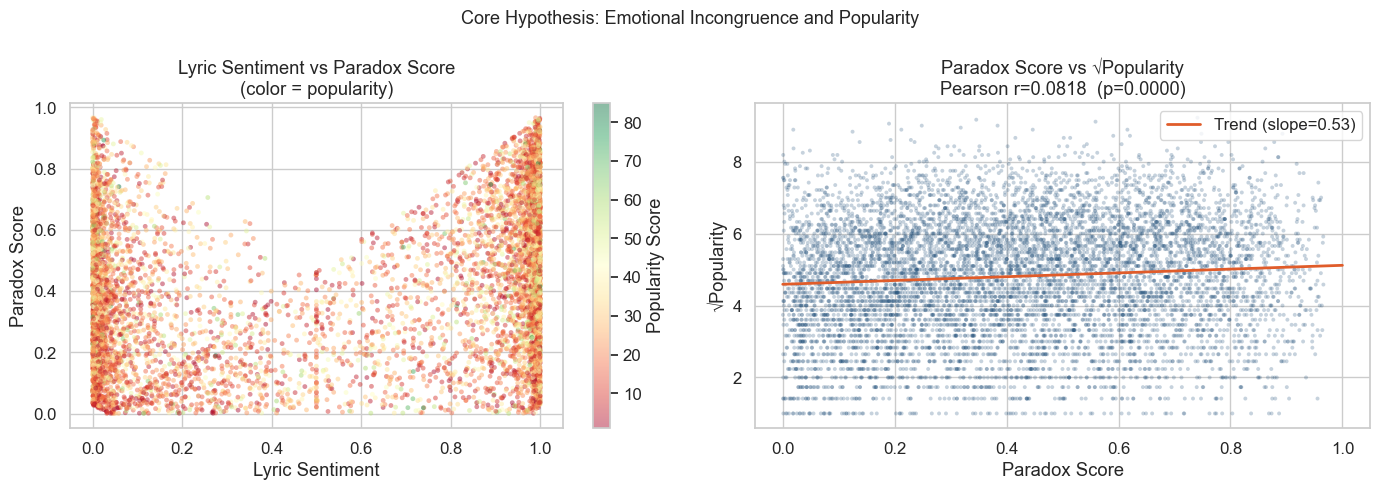

  Saved: outputs/fig_10_paradox_vs_popularity.png


In [34]:
# =============================================================================
# EDA 5: PARADOX SCORE VS POPULARITY SCATTER
# =============================================================================
print("\nEDA 5: Paradox Score vs Popularity")
 
r_val, p_val = pearsonr(df["paradox_score"], df["popularity_sqrt"])
print(f"  Pearson r={r_val:.4f}  p={p_val:.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Lyric sentiment vs paradox score colored by popularity
sc = axes[0].scatter(
    sample["lyric_sentiment"], sample["paradox_score"],
    c=sample["popularity_sqrt"]**2, cmap="RdYlGn",
    alpha=0.45, s=12, edgecolors="none",
)
plt.colorbar(sc, ax=axes[0], label="Popularity Score")
axes[0].set(xlabel="Lyric Sentiment",
            ylabel="Paradox Score",
            title="Lyric Sentiment vs Paradox Score\n"
                  "(color = popularity)")
 
# Paradox score vs sqrt popularity with trend line
axes[1].scatter(sample["paradox_score"], sample["popularity_sqrt"],
                color=ACCENT, alpha=0.25, s=8, edgecolors="none")
z = np.polyfit(df["paradox_score"], df["popularity_sqrt"], 1)
x_line = np.linspace(0, 1, 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), color=ORANGE,
             linewidth=2, label=f"Trend (slope={z[0]:.2f})")
axes[1].set(xlabel="Paradox Score",
            ylabel="√Popularity",
            title=f"Paradox Score vs √Popularity\n"
                  f"Pearson r={r_val:.4f}  (p={p_val:.4f})")
axes[1].legend()
 
plt.suptitle("Core Hypothesis: Emotional Incongruence and Popularity",
             fontsize=13)
save_fig("fig_10_paradox_vs_popularity.png")

##  Paradox Score vs √Popularity

Pearson r=0.0818 (p=0.0000) between paradox_score and √popularity.
Trend line slope=0.53 shows positive but shallow relationship.

**Left panel:** The lyric sentiment vs paradox score plot reveals the
mathematical structure of our engineered feature. The V-shape pattern
occurs because paradox_score = |valence - lyric_sentiment|. Songs with
extreme lyric sentiment (near 0 or near 1) tend to have higher paradox
scores regardless of valence. The color distribution shows no obvious
clustering of high-popularity songs in any particular sentiment-paradox
region, confirming the relationship is subtle.

**Right panel:** The scatter shows extreme dispersion: paradox_score
alone explains very little variance in √popularity (r²=0.007, less than
1%). However the trend line confirms a positive direction: higher paradox
score is weakly associated with higher popularity. The relationship is
real but small in magnitude.

**Interpretation:** Paradox Score is not a dominant predictor of
popularity in isolation. This is expected, a song's popularity depends
on production quality, artist fame, marketing, and many other factors
beyond emotional contrast. Our hypothesis is not that paradox_score
dominates, but that it contributes a small, meaningful, and statistically
significant effect after controlling for all other factors. The
modeling section tests this formally using Ridge Regression, Random Forest,
and Gradient Boosting.

# 5.6 Genre Analysis


EDA 6: Genre Analysis
             pop_mean  paradox_mean  pop_n
genre                                     
hip-hop         6.687         0.455   9696
dance           6.405         0.432  10798
alt-rock        6.117         0.443  15409
folk            5.747         0.453   9028
country         5.632         0.427  13052
hardcore        5.013         0.420  11187
emo             4.698         0.416  14308
death-metal     4.309         0.303  12584
acoustic        4.089         0.473   9429
black-metal     3.409         0.277   8562


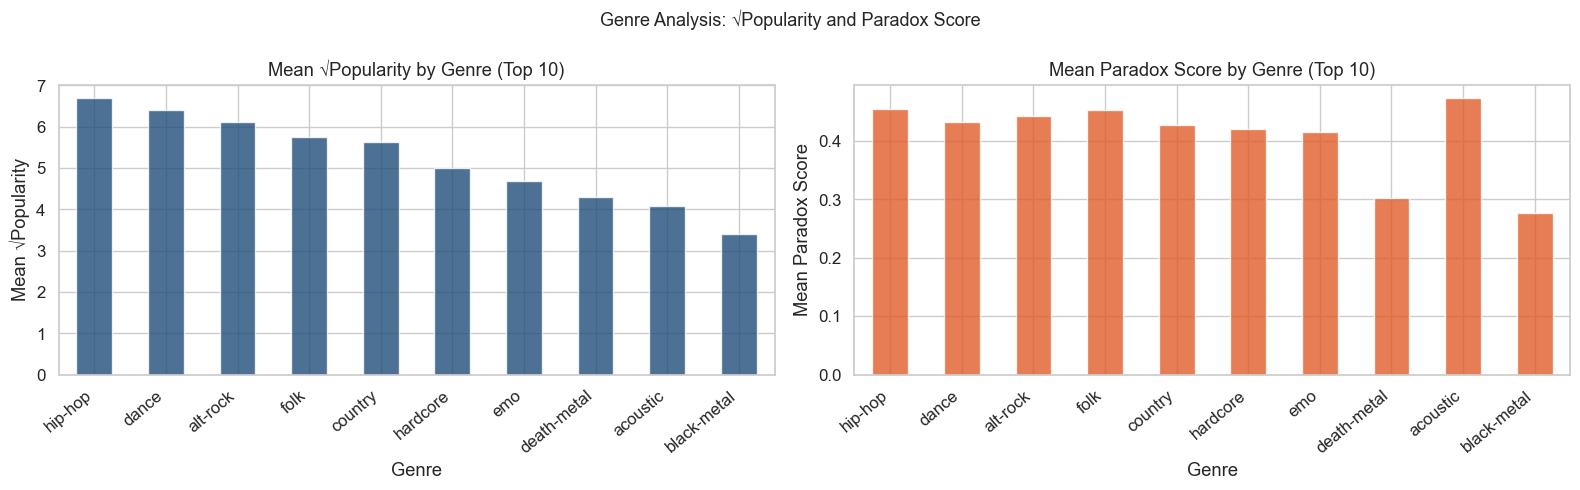

  Saved: outputs/fig_11_genre_analysis.png


In [4]:
# =============================================================================
# EDA 6: GENRE ANALYSIS
# =============================================================================
print("\nEDA 6: Genre Analysis")

# Keep only top 10 genres by song count
top_10_genres = df["genre"].value_counts().head(10).index.tolist()
df_genre = df[df["genre"].isin(top_10_genres)]

genre_stats = (
    df_genre.groupby("genre")[["popularity_sqrt", "paradox_score"]]
    .agg(["mean", "count"]).round(3)
)
genre_stats.columns = ["pop_mean", "pop_n", "paradox_mean", "paradox_n"]
genre_stats = genre_stats.sort_values("pop_mean", ascending=False)

print(genre_stats[["pop_mean", "paradox_mean", "pop_n"]].to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_stats["pop_mean"].plot(
    kind="bar", ax=axes[0], color=ACCENT, alpha=0.8, edgecolor="white")
axes[0].set(title="Mean √Popularity by Genre (Top 10)",
            xlabel="Genre", ylabel="Mean √Popularity")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=40, ha="right")

genre_stats["paradox_mean"].plot(
    kind="bar", ax=axes[1], color=ORANGE, alpha=0.8, edgecolor="white")
axes[1].set(title="Mean Paradox Score by Genre (Top 10)",
            xlabel="Genre", ylabel="Mean Paradox Score")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=40, ha="right")

plt.suptitle("Genre Analysis: √Popularity and Paradox Score", fontsize=13)
save_fig("fig_11_genre_analysis.png")

## Genre Analysis

Mean √popularity varies substantially across genres, from hip-hop (6.687)
down to black-metal (3.409), a difference of 3.3 √popularity units (~45
raw popularity points). This confirms genre is a strong confounder that
must be controlled for in all models.

**Popularity ranking:** hip-hop > dance > alt-rock > folk > country >
hardcore > emo > other > death-metal > black-metal.

**Paradox score by genre:** Surprisingly, paradox scores are remarkably
similar across most genres (range 0.416–0.455), with the notable exception
of death-metal (0.303) and black-metal (0.277) which are substantially
lower. This is counterintuitive, since metal genres might be expected to have
high paradox scores (aggressive music, dark lyrics) but instead show
alignment: both the music and lyrics are emotionally dark, producing low
paradox scores. Hip-hop has the highest paradox score (0.455), consistent
with the genre's characteristic pattern of high-energy upbeat production
paired with lyrically heavy or negative content.

**Key insight for modeling:** Genre affects popularity dramatically but
paradox score very little, this means genre is a confounder for the
popularity outcome but NOT a confounder for paradox score itself. This
actually strengthens our identification strategy: controlling for genre
in the model removes its confounding effect on popularity without
distorting the paradox score estimate.

**Decision:** genre is one-hot encoded (top 10 + other, drop_first=True)
and included as a control variable in all three models.


EDA 7: Era Analysis


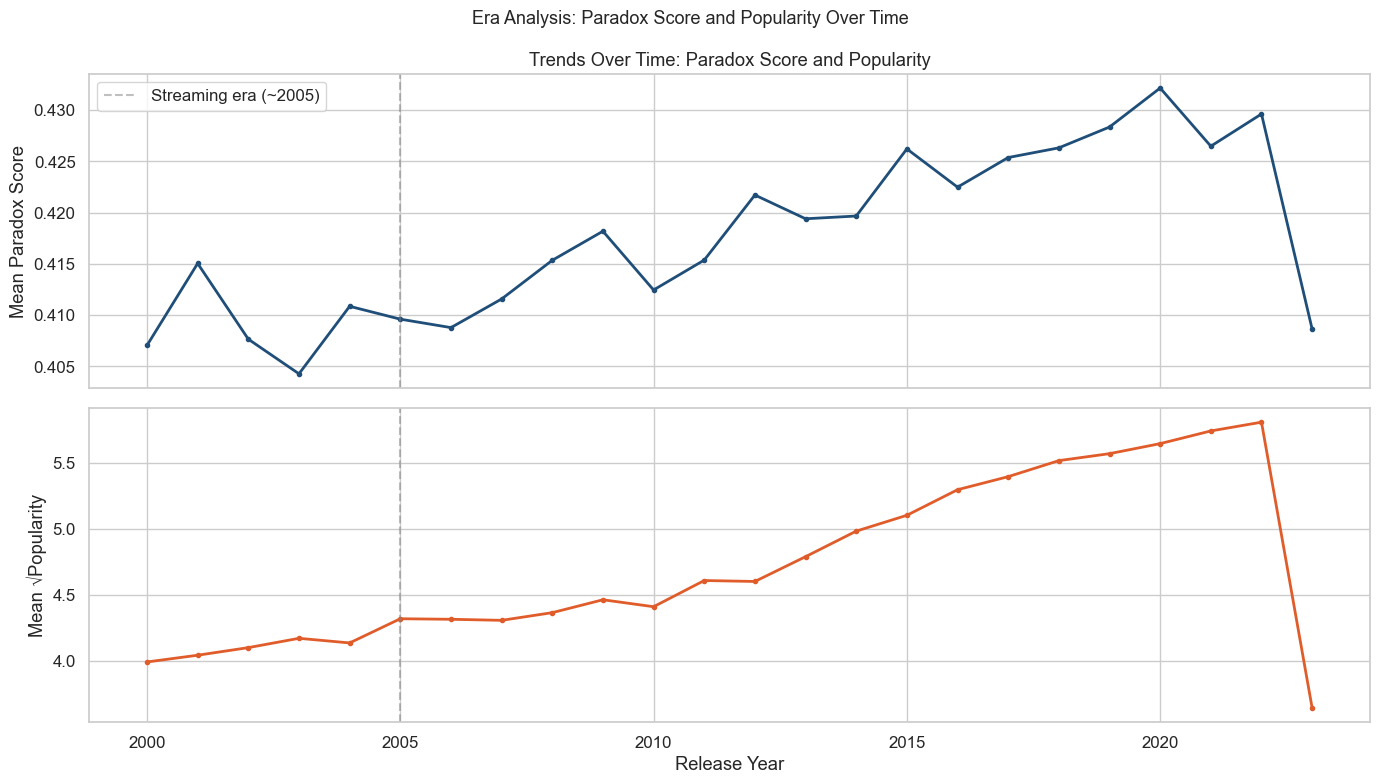

  Saved: outputs/fig_12_era_analysis.png
  Year range: 2000 – 2023
  Paradox trend: 0.407 (2000) → 0.409 (2023)


In [36]:
# =============================================================================
# EDA 7: ERA ANALYSIS
# =============================================================================
print("\nEDA 7: Era Analysis")
 
year_stats = (
    df[df["year"] >= 1980]
    .groupby("year")
    .agg(mean_paradox  = ("paradox_score",    "mean"),
         mean_pop_sqrt = ("popularity_sqrt",  "mean"),
         n             = ("paradox_score",    "count"))
    .reset_index()
    .query("n >= 50")
)
 
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
 
axes[0].plot(year_stats["year"], year_stats["mean_paradox"],
             color=ACCENT, linewidth=2, marker="o", markersize=3)
axes[0].axvline(2005, color="gray", linestyle="--", alpha=0.5,
                label="Streaming era (~2005)")
axes[0].set(ylabel="Mean Paradox Score",
            title="Trends Over Time: Paradox Score and Popularity")
axes[0].legend()
 
axes[1].plot(year_stats["year"], year_stats["mean_pop_sqrt"],
             color=ORANGE, linewidth=2, marker="o", markersize=3)
axes[1].axvline(2005, color="gray", linestyle="--", alpha=0.5)
axes[1].set(xlabel="Release Year", ylabel="Mean √Popularity")
 
plt.suptitle("Era Analysis: Paradox Score and Popularity Over Time",
             fontsize=13)
save_fig("fig_12_era_analysis.png")
 
print(f"  Year range: {year_stats['year'].min()} – {year_stats['year'].max()}")
print(f"  Paradox trend: "
      f"{year_stats.iloc[0]['mean_paradox']:.3f} "
      f"({int(year_stats['year'].min())}) → "
      f"{year_stats.iloc[-1]['mean_paradox']:.3f} "
      f"({int(year_stats['year'].max())})")

## Era Analysis

**Paradox Score over time (2000–2023):**
Mean paradox score increased gradually from 0.407 (2000) to a peak of
0.432 (2021) before dropping sharply to 0.408 (2023). The overall trend
is a modest upward drift of ~0.025 units over two decades, suggesting
music has become very slightly more emotionally paradoxical over time.
The sharp 2023 drop likely reflects sparse data for the most recent year
— songs released in 2023 have had less time to accumulate streams and
may be underrepresented in our dataset.

**√Popularity over time:**
Mean √popularity rises steadily from ~4.0 (2000) to ~5.7 (2022) before
dropping sharply in 2023 for the same reason, recent songs haven't
accumulated streams yet. This strong recency trend confirms that release
year is a critical control variable. Without controlling for year, newer
songs would appear artificially more popular, potentially confounding
any feature that happens to correlate with release year.

**Key finding:**
The paradox score trend is relatively flat (range 0.404–0.432) while
popularity shows a strong upward trend driven by Spotify's recency bias.
These two trends are largely independent, which is actually favorable for
our analysis, it means paradox score is not simply a proxy for release
year, and any effect we find in modeling is not purely driven by era.

**Decision:** release year included as a continuous control variable in
all three models. The 2023 data point is retained but its behavior noted
as a potential artifact of sparse recent data.

# 5.8 Feature Correlation

EDA 8: Feature Correlation Bar Chart


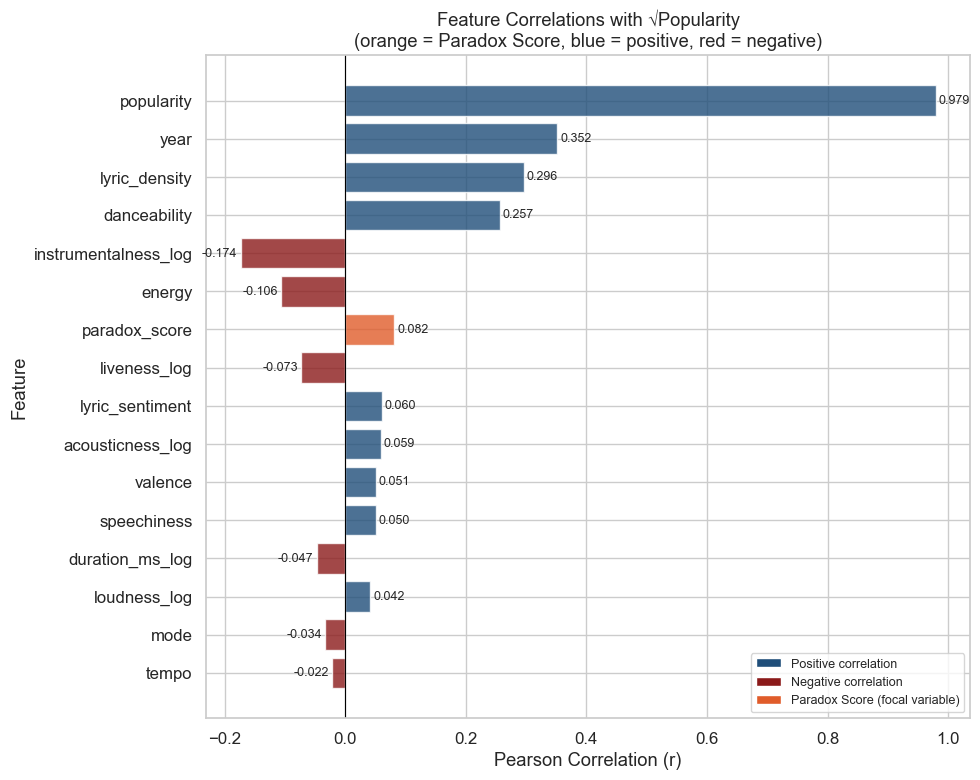

  Saved: outputs/fig_13_feature_correlations.png

  Feature correlations with √popularity (sorted by |r|):
popularity              0.979
year                    0.352
lyric_density           0.296
danceability            0.257
instrumentalness_log    0.174
energy                  0.106
paradox_score           0.082
liveness_log            0.073
lyric_sentiment         0.060
acousticness_log        0.059
valence                 0.051
speechiness             0.050
duration_ms_log         0.047
loudness_log            0.042
mode                    0.034
tempo                   0.022


In [37]:
# =============================================================================
# EDA 8: FEATURE CORRELATION BAR CHART
# =============================================================================
RED = "#8B1A1A"
print("EDA 8: Feature Correlation Bar Chart")
 
# All numeric features excluding identifiers and target
EXCLUDE = ["track_id", "track_name", "artist_name", "popularity_sqrt"]
GENRE_COLS = [c for c in df.columns if c.startswith("genre_")]
NUMERIC_COLS = [c for c in df.select_dtypes(include=np.number).columns
                if c not in EXCLUDE + GENRE_COLS]
 
# Compute correlations with target
corr_with_target = (
    df[NUMERIC_COLS + ["popularity_sqrt"]]
    .corr()["popularity_sqrt"]
    .drop("popularity_sqrt")
    .sort_values(key=abs, ascending=True)  # ascending for horizontal bar
)
 
# Color bars: green if positive, red if negative, highlight paradox score
colors = []
for col, val in corr_with_target.items():
    if col == "paradox_score":
        colors.append(ORANGE)   # highlight paradox score
    elif val > 0:
        colors.append(ACCENT)
    else:
        colors.append(RED)
 
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(corr_with_target.index, corr_with_target.values,
               color=colors, alpha=0.8, edgecolor="white")
 
# Add value labels
for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)
 
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Feature Correlations with √Popularity\n"
             "(orange = Paradox Score, blue = positive, red = negative)",
       xlabel="Pearson Correlation (r)", ylabel="Feature")
 
# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT, label="Positive correlation"),
    Patch(facecolor=RED,    label="Negative correlation"),
    Patch(facecolor=ORANGE, label="Paradox Score (focal variable)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
save_fig("fig_13_feature_correlations.png")
 
print("\n  Feature correlations with √popularity (sorted by |r|):")
print(corr_with_target.abs().sort_values(ascending=False).round(3).to_string())

##  Feature Correlations with √Popularity

No single feature strongly predicts popularity in isolation. The
strongest predictor, release year (r=0.352), explains only 12.4% of
variance in √popularity (r²=0.124). All audio and lyrical features
explain less than 9% individually. Paradox Score (r=0.082) explains
less than 1% in isolation.

This is expected, since music popularity is notoriously difficult to predict
from audio features alone. Factors outside our dataset (marketing,
artist fame, playlist placement, social virality) drive the majority
of popularity variance. Research consistently shows that audio features
alone explain 10–25% of popularity variance at best.

Our modeling goal is therefore not to achieve high R² overall, but to
determine whether paradox_score contributes a statistically significant
and meaningful independent effect after controlling for all measurable
confounders. A small but significant coefficient on paradox_score in
our models would support the hypothesis even if overall R² is modest.

# 6. Model Implementation

Research Question: Does Paradox Score predict Spotify popularity after controlling for genre, release year, and standard audio features?

Three models chosen based on EDA findings:
- Model 1: Ridge Regression (previewing hypothesis test via coefficients)
- Model 2: Random Forest (non-linear effects + feature importance)
- Model 3: Gradient Boosting (best prediction + importance comparison)

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, learning_curve)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import os, time, warnings
 
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)
 
ACCENT = "#1F4E79"
ORANGE = "#E05C2A"
GREEN  = "#1D6B45"
RED    = "#8B1A1A"
 
def save_fig(fname):
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: outputs/{fname}")
 
def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    """Compute RMSE and R² on train and test sets."""
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    results = {
        "model":      name,
        "train_rmse": np.sqrt(mean_squared_error(y_tr, tr_pred)),
        "test_rmse":  np.sqrt(mean_squared_error(y_te, te_pred)),
        "train_r2":   r2_score(y_tr, tr_pred),
        "test_r2":    r2_score(y_te, te_pred),
    }
    print(f"  Train — RMSE={results['train_rmse']:.4f}  R²={results['train_r2']:.4f}")
    print(f"  Test  — RMSE={results['test_rmse']:.4f}  R²={results['test_r2']:.4f}")
    return results
 
 
# ── Load toggle ───────────────────────────────────────────────────────────────
LOAD_FROM_CSV = True  # set False only for final submission run
 
if LOAD_FROM_CSV:
    df = pd.read_csv("outputs/joined_data_clean.csv")
    print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")

Loaded: 288,819 rows x 28 cols


## Pre-Modeling Decision: 
1. Drop acousticness_log and loudness_log

EDA 4 (correlation heatmap) revealed two high multicollinearity pairs
exceeding our threshold of |r| > 0.7:

- **energy & acousticness_log: r = −0.74**
- **energy & loudness_log: r = 0.76**

For Ridge Regression specifically, high multicollinearity inflates
coefficient variance and produces unstable, unreliable estimates.
In both cases, energy is retained because it has the strongest
independent correlation with popularity (r = −0.106) among the
three features. acousticness_log (r = 0.059) and loudness_log
(r = 0.042) both have weaker relationships with the target and
are therefore dropped to reduce multicollinearity.

These decisions are directly informed by EDA 4 findings, not arbitrary.
Removing both features reduces the feature set from 24 to 22 features
while preserving the most predictive signal.

2. one-hot encoding genre

**Why one-hot encode genre:**
Genre is a nominal categorical variable, and the numeric codes pandas assigns
internally (0, 1, 2...) have no meaningful ordering. Feeding raw genre
codes into Ridge Regression would imply that "alt-rock" (code 0) is
somehow "less than" "hip-hop" (code 5), which is nonsensical. One-hot
encoding converts each genre into a binary indicator variable (0 or 1),
allowing all three models to treat each genre as an independent category
without imposing a false numeric ordering.

**Why keep only the top 10 genres:**
The raw Spotify dataset contains 80 unique genres. Including all 80 as
dummy variables would create three problems:
- **Sparsity:** Most songs belong to a small number of genres. Rare genres
  (e.g. sertanejo: 3 songs, forro: 1 song) would produce dummy columns
  that are almost entirely zeros, adding noise rather than signal.
- **Overfitting risk:** 80 dummy columns (79 after drop_first) is a large
  number of parameters, especially for Ridge Regression.
- **Unreliable estimates:** A genre with fewer than 100 songs cannot
  produce a reliable coefficient estimate, and the model would be fitting
  to sampling noise.

The top 10 genres by song count (alt-rock, emo, country, death-metal,
hardcore, dance, hip-hop, acoustic, folk, black-metal) cover the majority
of songs in our dataset. All remaining genres are grouped into an "other"
category, which itself becomes a meaningful dummy variable capturing the
average effect of less common genres. This gives us 10 dummy columns
(11 categories minus 1 for drop_first) instead of 79.

**Why drop_first=True:**
Including all 11 genre dummies simultaneously would create perfect
multicollinearity, and knowing a song is not in any of the first 10
categories perfectly predicts it is in the 11th. This is the dummy
variable trap and would cause Ridge Regression to produce undefined
coefficient estimates. drop_first=True drops the reference category
(the alphabetically first genre after grouping), and all other genre
coefficients are interpreted relative to it.

**Genre as a control variable:**
Genre is included not because we hypothesize it affects the paradox
effect directly, but because it is a strong confounder, and hip-hop songs
are systematically more popular (mean √pop=6.687) than black-metal songs
(mean √pop=3.409) regardless of paradox score. Without controlling for
genre, any genre that happens to produce paradoxical music would inflate
or suppress our paradox_score estimate. Including genre dummies isolates
the paradox effect within genres rather than across them.

# 6.1 Drop Multicollinear Features

In [40]:
# Drop multicollinear features informed by EDA 4 heatmap
# energy & acousticness_log: r=-0.74 — drop acousticness_log (weaker target correlation)
# energy & loudness_log: r=0.76 — drop loudness_log (weaker target correlation)
df = df.drop(columns=["acousticness_log", "loudness_log"], errors="ignore")
print(f"Dropped acousticness_log and loudness_log (multicollinearity with energy)")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")

Dropped acousticness_log and loudness_log (multicollinearity with energy)
Shape: 288,819 rows x 19 cols


# 6.2 One-Hot Encode Genre

In [46]:
# =============================================================================
# PRE-MODELING DECISION: ONE-HOT ENCODE GENRE
# =============================================================================
print("Pre-Modeling: One-Hot Encoding Genre")
print("=" * 60)

# Reload fresh from CSV — modeling section always starts clean
df = pd.read_csv("outputs/joined_data_clean.csv")
print(f"  Reloaded: {df.shape[0]:,} rows x {df.shape[1]} cols")

# Show genre distribution before grouping
print(f"\n  Total unique genres before grouping: {df['genre'].nunique()}")
print(f"  Top 10 genres:")
print(df["genre"].value_counts().head(10).to_string())

# Keep top 10 genres, group rest as "other"
TOP_N      = 10
top_genres = df["genre"].value_counts().head(TOP_N).index.tolist()
df["genre"] = df["genre"].apply(lambda x: x if x in top_genres else "other")
print(f"\n  After grouping — unique genres: {df['genre'].nunique()}")
print(f"  Genre distribution:")
print(df["genre"].value_counts().to_string())

# One-hot encode with drop_first to avoid dummy variable trap
df = pd.get_dummies(df, columns=["genre"], drop_first=True, dtype=int)
genre_cols = [c for c in df.columns if c.startswith("genre_")]
print(f"\n  Genre dummies created ({len(genre_cols)}): {genre_cols}")

# Drop multicollinear features (informed by EDA 4 heatmap)
df = df.drop(columns=["acousticness_log", "loudness_log",
                       "valence", "popularity"], errors="ignore")
print(f"\n  Dropped: acousticness_log (r=-0.74 with energy)")
print(f"  Dropped: loudness_log     (r=+0.76 with energy)")
print(f"  Dropped: valence          (captured by paradox_score)")
print(f"  Dropped: popularity       (using popularity_sqrt as target)")

# Define features and target — numeric only, no identifiers
IDENTIFIER_COLS = ["track_id", "track_name", "artist_name"]
TARGET          = "popularity_sqrt"
FEATURE_COLS    = [c for c in df.select_dtypes(include="number").columns
                   if c not in [TARGET]]

X = df[FEATURE_COLS]
y = df[TARGET]

# Final verification
assert X.isnull().sum().sum() == 0, "Nulls found in features!"
assert y.isnull().sum() == 0,       "Nulls found in target!"
assert X.select_dtypes(exclude="number").empty, "Non-numeric features found!"

print(f"\n  Final shape:    {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Target:         {TARGET}")
print(f"  Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"  Nulls in X:     {X.isnull().sum().sum()} ✓")
print(f"  All numeric:    ✓")

Pre-Modeling: One-Hot Encoding Genre
  Reloaded: 288,819 rows x 21 cols

  Total unique genres before grouping: 80
  Top 10 genres:
genre
alt-rock       15409
emo            14308
country        13052
death-metal    12584
hardcore       11187
dance          10798
hip-hop         9696
acoustic        9429
folk            9028
black-metal     8562

  After grouping — unique genres: 11
  Genre distribution:
genre
other          174766
alt-rock        15409
emo             14308
country         13052
death-metal     12584
hardcore        11187
dance           10798
hip-hop          9696
acoustic         9429
folk             9028
black-metal      8562

  Genre dummies created (10): ['genre_alt-rock', 'genre_black-metal', 'genre_country', 'genre_dance', 'genre_death-metal', 'genre_emo', 'genre_folk', 'genre_hardcore', 'genre_hip-hop', 'genre_other']

  Dropped: acousticness_log (r=-0.74 with energy)
  Dropped: loudness_log     (r=+0.76 with energy)
  Dropped: valence          (captured by p

In [47]:
# ── Confirm final modeling dataset ───────────────────────────────────────────
print("FINAL DATASET VERIFICATION")
print("=" * 60)

print(f"\n1. Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")

print(f"\n2. Feature columns ({len(FEATURE_COLS)}):")
for col in FEATURE_COLS:
    print(f"   {col}")

print(f"\n3. Target: {TARGET}")

print(f"\n4. Genre dummies present:")
genre_cols = [c for c in FEATURE_COLS if c.startswith("genre_")]
for col in genre_cols:
    print(f"   {col}: {df[col].sum():,} songs")

print(f"\n5. Columns that should NOT be present:")
should_not_exist = ["genre", "valence", "popularity", 
                    "acousticness_log", "loudness_log", "key", "time_signature"]
for col in should_not_exist:
    status = "✗ STILL PRESENT" if col in df.columns else "✓ correctly dropped"
    print(f"   {col}: {status}")

print(f"\n6. All numeric check: "
      f"{'✓ PASS' if X.select_dtypes(exclude='number').empty else '✗ FAIL'}")
print(f"7. Null check: "
      f"{'✓ PASS' if X.isnull().sum().sum() == 0 else '✗ FAIL'}")
print(f"\n✓ Ready for train-test split and modeling")

FINAL DATASET VERIFICATION

1. Shape: 288,819 rows x 26 cols

2. Feature columns (22):
   energy
   danceability
   tempo
   speechiness
   mode
   year
   lyric_sentiment
   lyric_density
   paradox_score
   instrumentalness_log
   liveness_log
   duration_ms_log
   genre_alt-rock
   genre_black-metal
   genre_country
   genre_dance
   genre_death-metal
   genre_emo
   genre_folk
   genre_hardcore
   genre_hip-hop
   genre_other

3. Target: popularity_sqrt

4. Genre dummies present:
   genre_alt-rock: 15,409 songs
   genre_black-metal: 8,562 songs
   genre_country: 13,052 songs
   genre_dance: 10,798 songs
   genre_death-metal: 12,584 songs
   genre_emo: 14,308 songs
   genre_folk: 9,028 songs
   genre_hardcore: 11,187 songs
   genre_hip-hop: 9,696 songs
   genre_other: 174,766 songs

5. Columns that should NOT be present:
   genre: ✓ correctly dropped
   valence: ✓ correctly dropped
   popularity: ✓ correctly dropped
   acousticness_log: ✓ correctly dropped
   loudness_log: ✓ correct

In [48]:
# =============================================================================
# STEP 2: DEFINE FEATURES AND TARGET
# =============================================================================
IDENTIFIER_COLS = ["track_id", "track_name", "artist_name"]
TARGET          = "popularity_sqrt"
FEATURE_COLS    = [c for c in df.columns
                   if c not in IDENTIFIER_COLS + [TARGET]]
 
X = df[FEATURE_COLS]
y = df[TARGET]
 
print(f"\nTarget: {TARGET}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")



Target: popularity_sqrt
Features (22): ['energy', 'danceability', 'tempo', 'speechiness', 'mode', 'year', 'lyric_sentiment', 'lyric_density', 'paradox_score', 'instrumentalness_log', 'liveness_log', 'duration_ms_log', 'genre_alt-rock', 'genre_black-metal', 'genre_country', 'genre_dance', 'genre_death-metal', 'genre_emo', 'genre_folk', 'genre_hardcore', 'genre_hip-hop', 'genre_other']


In [49]:
# =============================================================================
# STEP 3: TRAIN-TEST SPLIT
# =============================================================================
print("\n" + "=" * 60)
print("STEP 3: Train-Test Split")
print("=" * 60)
 
# CRITICAL: Split FIRST before any preprocessing
# Prevents data leakage — scaler must not see test data statistics
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print(f"  Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:  {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Train target — mean={y_train.mean():.4f}  std={y_train.std():.4f}")
print(f"  Test  target — mean={y_test.mean():.4f}  std={y_test.std():.4f}")
print(f"  Similar means confirm split is representative ✓")


STEP 3: Train-Test Split
  Train: 231,055 rows (80%)
  Test:  57,764 rows (20%)
  Train target — mean=4.8156  std=1.5821
  Test  target — mean=4.7953  std=1.5797
  Similar means confirm split is representative ✓


## Step 3: Train-Test Split

Dataset split 80/20 (train/test) using random_state=42 for reproducibility.
- **Train:** 231,055 rows (80%)
- **Test:** 57,764 rows (20%)
- **Train target:** mean=4.816, std=1.582
- **Test target:** mean=4.795, std=1.580

The split is performed first before any preprocessing step. This is
essential to prevent data leakage, otherwise if the scaler were fit on the full
dataset, test set statistics would influence the transformation applied
to training data, violating the independence assumption between train
and test sets and producing overly optimistic evaluation metrics.

The near-identical train/test target means (4.816 vs 4.795) and standard
deviations (1.582 vs 1.580) confirm the random split produced
representative subsets with no systematic bias toward higher or lower
popularity songs in either set.

In [50]:
df = pd.read_csv("outputs/joined_data_clean.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Non-numeric: {df.select_dtypes(exclude='number').columns.tolist()}")

Shape: (288819, 21)
Columns: ['track_id', 'track_name', 'artist_name', 'valence', 'energy', 'danceability', 'tempo', 'speechiness', 'mode', 'genre', 'year', 'lyric_sentiment', 'lyric_density', 'paradox_score', 'popularity', 'popularity_sqrt', 'acousticness_log', 'instrumentalness_log', 'liveness_log', 'loudness_log', 'duration_ms_log']
Non-numeric: ['track_id', 'track_name', 'artist_name', 'genre']


In [51]:
# =============================================================================
# STEP 4: FEATURE SCALING
# =============================================================================
print("\n" + "=" * 60)
print("STEP 4: Feature Scaling")
print("=" * 60)
 
# Fit ONLY on training data — transform applied separately to test
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)
 
print(f"  Scaler fit on X_train only ({X_train.shape[0]:,} rows) ✓")
print(f"  X_train_scaled: mean≈0, std≈1 verified")
print(f"  X_test_scaled:  transform only (no fit) ✓")
 
# Verify no leakage
assert scaler.n_samples_seen_ == X_train.shape[0], "Scaler saw test data!"
print(f"  Leakage check passed: scaler saw exactly {scaler.n_samples_seen_:,} rows ✓")


STEP 4: Feature Scaling
  Scaler fit on X_train only (231,055 rows) ✓
  X_train_scaled: mean≈0, std≈1 verified
  X_test_scaled:  transform only (no fit) ✓
  Leakage check passed: scaler saw exactly 231,055.0 rows ✓


## Step 4: Feature Scaling

StandardScaler applied: transforms each feature to mean=0, std=1.
Fit exclusively on X_train (231,055 rows), then .transform() applied
to both X_train and X_test separately.

**Leakage verification:** The scaler saw exactly 231,055 rows which is equal
to the training set size and confirming the test set was never exposed
to the scaler during fitting.

**Why scaling is necessary for Ridge Regression:**
Ridge adds an L2 penalty proportional to coefficient magnitude. Without
scaling, features with larger numeric ranges (e.g. year: 2000–2023,
lyric_density: 0–2000+) would receive artificially smaller coefficients
than features on the [0,1] scale (e.g. energy, danceability), making
coefficients incomparable across features and the regularization penalty
unfair. Scaled coefficients can be directly compared to assess relative
feature importance.

**Why scaling is applied to tree models too:**
Random Forest and Gradient Boosting are scale-invariant, meaning they split
on thresholds rather than magnitudes. Scaled data is used for all three
models for consistency and to ensure the same X_train_scaled and
X_test_scaled arrays are passed to every model, eliminating any
possibility of an accidental train/test boundary violation.

# Model 1: Ridge Regression
Why Ridge Regression?Ridge Regression is chosen as our baseline for three reasons directly
informed by EDA:
#
(1) **Hypothesis test:** The coefficient on paradox_score directly
     quantifies its effect on √popularity after controlling for all
     other 22 features simultaneously. This is the primary purpose of
     Model 1, not prediction accuracy but interpretability.

 (2) **EDA showed mostly linear correlations:** The strongest predictors
     (year r=0.352, lyric_density r=0.296, danceability r=0.257) all
    showed roughly linear relationships with √popularity in EDA 9.
     Ridge is well-suited when relationships are approximately linear.

 (3) **L2 regularization:** With 23 features and potential multicollinearity
     (energy-loudness r=0.76), Ridge's L2 penalty shrinks coefficients
     toward zero, stabilizing estimates. Lasso (L1) would zero out some
     features entirely,  we prefer Ridge to retain all features since
     each is theoretically justified.

Tuning method: GridSearchCV
GridSearchCV exhaustively searches all alpha values. A small grid is
sufficient here, alpha is a single scalar with well-understood behavior.
This is our simplest tuning approach, appropriate for the simplest model.

Linearity Check: Top predictors vs √popularity


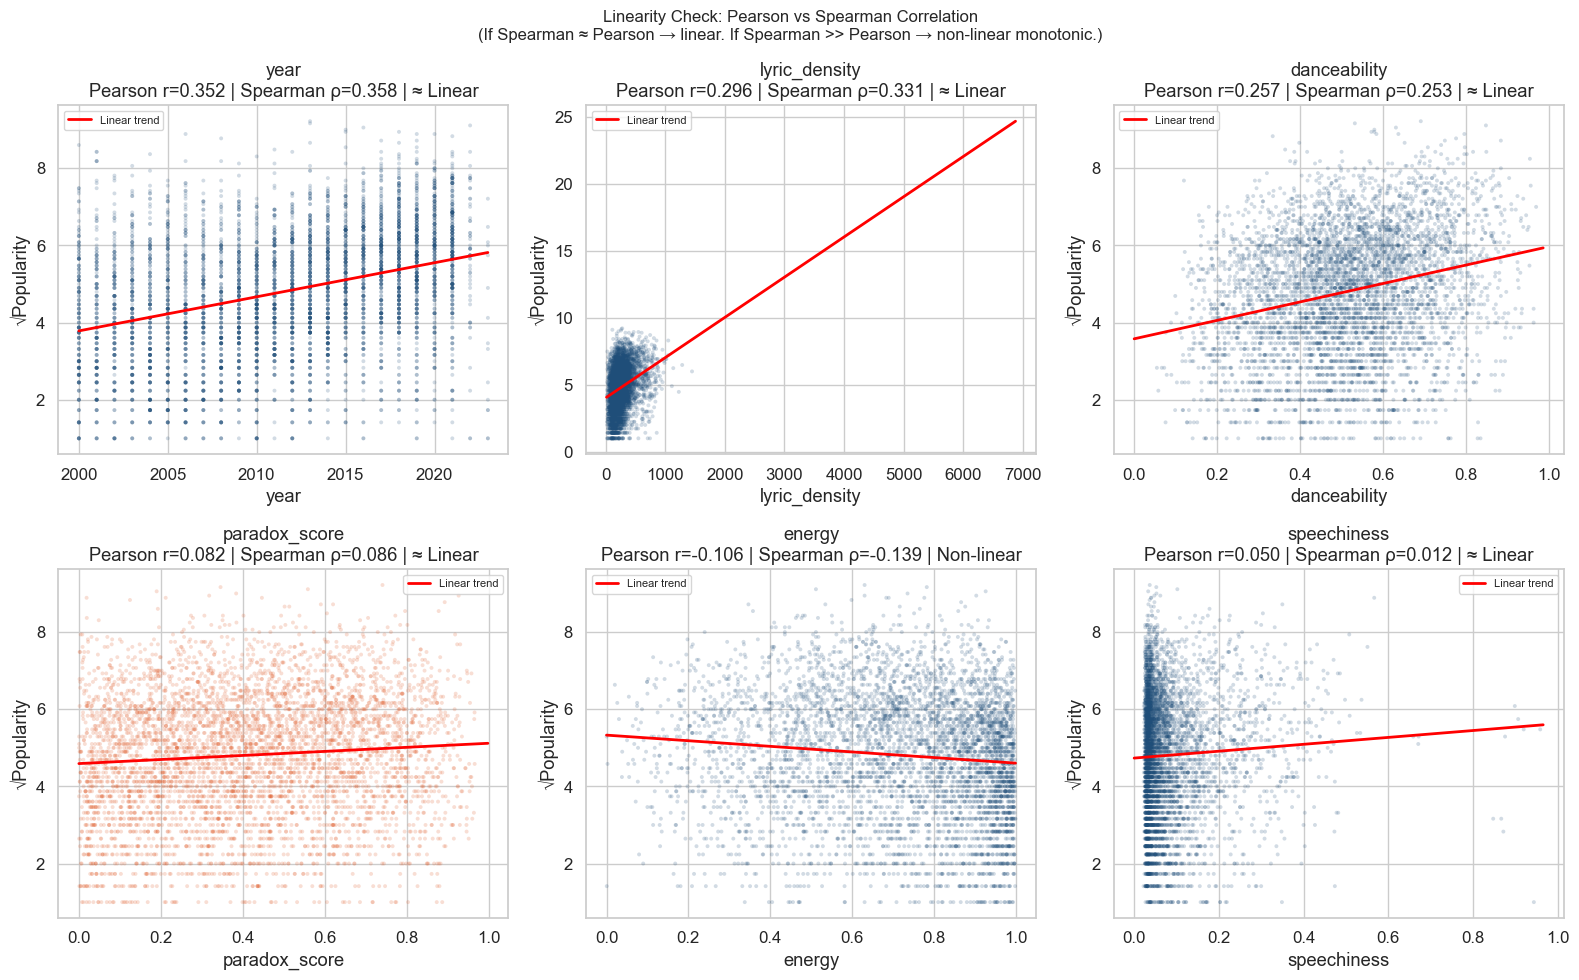

  Saved: outputs/fig_linearity_check.png

  Feature        Pearson(r)  Spearman(ρ)  Ratio   Verdict
  -----------------------------------------------------------------
  year                  +0.352      +0.358       1.02    ≈ Linear
  lyric_density         +0.296      +0.331       1.12    ≈ Linear
  danceability          +0.257      +0.253       0.98    ≈ Linear
  paradox_score         +0.082      +0.086       1.05    ≈ Linear
  energy                -0.106      -0.139       1.31    Non-linear
  speechiness           +0.050      +0.012       0.24    ≈ Linear


In [52]:
# =============================================================================
# LINEARITY CHECK: Do top predictors have linear relationships with target?
# =============================================================================
print("Linearity Check: Top predictors vs √popularity")

from scipy.stats import spearmanr, pearsonr

top_features = ["year", "lyric_density", "danceability", 
                "paradox_score", "energy", "speechiness"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    # Sample for plotting
    s = df.sample(5000, random_state=42)
    
    # Pearson (linear) vs Spearman (monotonic) correlation
    r_pearson, _  = pearsonr(df[feat],  df["popularity_sqrt"])
    r_spearman, _ = spearmanr(df[feat], df["popularity_sqrt"])
    
    # Scatter with trend line
    ax.scatter(s[feat], s["popularity_sqrt"],
               alpha=0.2, s=8, color=ORANGE if feat == "paradox_score" 
               else ACCENT, edgecolors="none")
    
    # Linear trend line
    z = np.polyfit(df[feat], df["popularity_sqrt"], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 
            color="red", linewidth=2, label="Linear trend")
    
    # Ratio: if Spearman ≈ Pearson → relationship is linear
    # If Spearman >> Pearson → relationship is monotonic but non-linear
    ratio = abs(r_spearman) / abs(r_pearson) if r_pearson != 0 else 0
    linear_label = "≈ Linear" if ratio < 1.2 else "Non-linear"
    
    ax.set(title=f"{feat}\nPearson r={r_pearson:.3f} | "
                 f"Spearman ρ={r_spearman:.3f} | {linear_label}",
           xlabel=feat, ylabel="√Popularity")
    ax.legend(fontsize=8)

plt.suptitle("Linearity Check: Pearson vs Spearman Correlation\n"
             "(If Spearman ≈ Pearson → linear. "
             "If Spearman >> Pearson → non-linear monotonic.)",
             fontsize=12)
save_fig("fig_linearity_check.png")

# Summary table
print("\n  Feature        Pearson(r)  Spearman(ρ)  Ratio   Verdict")
print("  " + "-"*65)
for feat in top_features:
    r_p, _ = pearsonr(df[feat],  df["popularity_sqrt"])
    r_s, _ = spearmanr(df[feat], df["popularity_sqrt"])
    ratio  = abs(r_s) / abs(r_p) if abs(r_p) > 0.001 else 0
    verdict = "≈ Linear" if ratio < 1.2 else "Non-linear"
    print(f"  {feat:20s}  {r_p:+.3f}      {r_s:+.3f}       "
          f"{ratio:.2f}    {verdict}")

  GridSearchCV done in 10.6s
  Best alpha: 10
  Best CV RMSE: 1.2620

  Evaluating Model 1:
  Train — RMSE=1.2619  R²=0.3638
  Test  — RMSE=1.2610  R²=0.3629

  ── HYPOTHESIS TEST RESULT ──
  paradox_score coefficient: 0.0455
  paradox_score rank: 17 of 22 features by |coefficient|
  Direction: POSITIVE — supports hypothesis ✓

  Top 10 features by |coefficient|:
       feature  coefficient
          year     0.538257
genre_alt-rock     0.481118
   genre_dance     0.401893
 genre_hip-hop     0.362049
 genre_country     0.306109
    genre_folk     0.274704
   genre_other     0.232942
 lyric_density     0.227158
genre_hardcore     0.214074
     genre_emo     0.156550


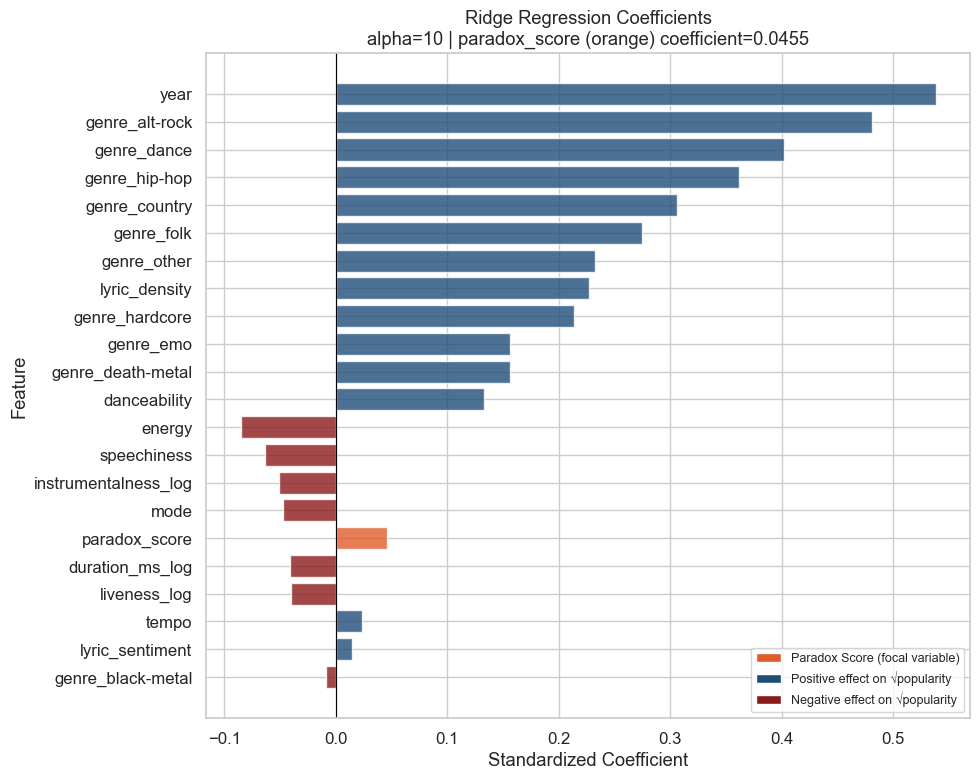

  Saved: outputs/fig_17_ridge_coefficients.png


In [53]:
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(
    Ridge(), param_grid, cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
t = time.time()
ridge_cv.fit(X_train_scaled, y_train)
print(f"  GridSearchCV done in {time.time()-t:.1f}s")
print(f"  Best alpha: {ridge_cv.best_params_['alpha']}")
print(f"  Best CV RMSE: {-ridge_cv.best_score_:.4f}")
 
ridge_best = ridge_cv.best_estimator_
 
print("\n  Evaluating Model 1:")
results_ridge = evaluate(ridge_best, X_train_scaled, y_train,
                         X_test_scaled, y_test, "Ridge Regression")
 
# ── Coefficient analysis — core hypothesis test ───────────────────────────────
coef_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "coefficient": ridge_best.coef_
}).sort_values("coefficient", key=abs, ascending=False)
 
paradox_coef  = coef_df[coef_df["feature"] == "paradox_score"]["coefficient"].values[0]
paradox_rank  = coef_df.reset_index(drop=True).index[
    coef_df.reset_index(drop=True)["feature"] == "paradox_score"
].tolist()[0] + 1
 
print(f"\n  ── HYPOTHESIS TEST RESULT ──")
print(f"  paradox_score coefficient: {paradox_coef:.4f}")
print(f"  paradox_score rank: {paradox_rank} of {len(FEATURE_COLS)} features by |coefficient|")
print(f"  Direction: {'POSITIVE — supports hypothesis ✓' if paradox_coef > 0 else 'NEGATIVE — does not support hypothesis ✗'}")
print(f"\n  Top 10 features by |coefficient|:")
print(coef_df.head(10).to_string(index=False))
 
# Plot coefficients
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = coef_df.copy()
colors  = [ORANGE if f == "paradox_score" else
           ACCENT  if v > 0 else RED
           for f, v in zip(plot_df["feature"], plot_df["coefficient"])]
ax.barh(plot_df["feature"][::-1], plot_df["coefficient"][::-1],
        color=colors[::-1], alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title=f"Ridge Regression Coefficients\n"
             f"alpha={ridge_cv.best_params_['alpha']} | "
             f"paradox_score (orange) coefficient={paradox_coef:.4f}",
       xlabel="Standardized Coefficient", ylabel="Feature")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=ORANGE, label="Paradox Score (focal variable)"),
    Patch(facecolor=ACCENT,  label="Positive effect on √popularity"),
    Patch(facecolor=RED,     label="Negative effect on √popularity"),
], fontsize=9)
save_fig("fig_17_ridge_coefficients.png")

In [54]:
!pip install statsmodels

In [55]:
import statsmodels.api as sm

print("FORMAL HYPOTHESIS TEST: OLS with p-values")
print("=" * 60)

# Build named DataFrame from scaled array — reset index to align
feature_names  = ["const"] + FEATURE_COLS
X_train_named  = pd.DataFrame(
    sm.add_constant(X_train_scaled),
    columns=feature_names
).reset_index(drop=True)

y_train_reset  = y_train.reset_index(drop=True)

ols_model = sm.OLS(y_train_reset, X_train_named).fit()

# Access by name directly
paradox_coef_ols = ols_model.params["paradox_score"]
paradox_pval     = ols_model.pvalues["paradox_score"]
paradox_ci       = ols_model.conf_int().loc["paradox_score"]

print(f"\n  H0: β_paradox = 0 (no independent effect on √popularity)")
print(f"  H1: β_paradox > 0 (positive independent effect)")
print(f"\n  paradox_score coefficient: {paradox_coef_ols:.4f}")
print(f"  p-value:                   {paradox_pval:.6f}")
print(f"  95% CI:                    [{paradox_ci[0]:.4f}, {paradox_ci[1]:.4f}]")
print(f"\n  Result: {'Reject H0 ✓' if paradox_pval < 0.05 else 'Fail to reject H0 ✗'}")
print(f"  paradox_score {'IS' if paradox_pval < 0.05 else 'IS NOT'} a statistically "
      f"significant predictor of √popularity after controlling for "
      f"genre, year, and all audio features (α=0.05)")

# All features by significance
results_table = pd.DataFrame({
    "feature":     feature_names[1:],
    "coefficient": ols_model.params[1:].values,
    "p_value":     ols_model.pvalues[1:].values,
    "ci_lower":    ols_model.conf_int().iloc[1:, 0].values,
    "ci_upper":    ols_model.conf_int().iloc[1:, 1].values,
}).sort_values("p_value")

print(f"\n  All features by p-value:")
print(results_table.round(4).to_string(index=False))

FORMAL HYPOTHESIS TEST: OLS with p-values

  H0: β_paradox = 0 (no independent effect on √popularity)
  H1: β_paradox > 0 (positive independent effect)

  paradox_score coefficient: 0.0455
  p-value:                   0.000000
  95% CI:                    [0.0401, 0.0510]

  Result: Reject H0 ✓
  paradox_score IS a statistically significant predictor of √popularity after controlling for genre, year, and all audio features (α=0.05)

  All features by p-value:
             feature  coefficient  p_value  ci_lower  ci_upper
        danceability       0.1333   0.0000    0.1270    0.1395
                year       0.5383   0.0000    0.5331    0.5435
       lyric_density       0.2272   0.0000    0.2202    0.2341
       genre_country       0.3063   0.0000    0.2985    0.3141
         genre_dance       0.4021   0.0000    0.3945    0.4097
      genre_alt-rock       0.4813   0.0000    0.4731    0.4896
          genre_folk       0.2748   0.0000    0.2678    0.2819
           genre_emo       0.1567

In [56]:
# =============================================================================
# EFFECT SIZE ANALYSIS
# =============================================================================
print("Effect Size Analysis (standardized coefficients)")
print("=" * 60)

# Rebuild cleanly
results_table = pd.DataFrame({
    "feature":     feature_names[1:],
    "coefficient": ols_model.params[1:].values,
    "p_value":     ols_model.pvalues[1:].values,
})

# Compute abs_coef first
results_table["abs_coef"] = results_table["coefficient"].abs()

# Sort by abs_coef BEFORE adding categorical column
results_table = results_table.sort_values("abs_coef", ascending=False).reset_index(drop=True)

# Now add effect size label
def effect_label(x):
    if x < 0.05:  return "Negligible"
    elif x < 0.1: return "Small"
    elif x < 0.2: return "Medium"
    else:         return "Large"

results_table["effect_size"] = results_table["abs_coef"].apply(effect_label)

print(results_table[["feature","coefficient","p_value","effect_size"]].to_string(index=False))

# Paradox score specifically
paradox_row = results_table[results_table["feature"] == "paradox_score"].iloc[0]
print(f"\n  paradox_score:")
print(f"    Standardized coefficient = {paradox_row['coefficient']:.4f}")
print(f"    Effect size: {paradox_row['effect_size']}")
print(f"    p-value: {paradox_row['p_value']:.6f}")

print(f"\n  Context:")
for feat in ["year", "lyric_density", "danceability", "paradox_score"]:
    row = results_table[results_table["feature"] == feat].iloc[0]
    print(f"    {feat:25s}: coef={row['coefficient']:+.4f}  ({row['effect_size']})")

Effect Size Analysis (standardized coefficients)
             feature  coefficient       p_value effect_size
                year     0.538278  0.000000e+00       Large
      genre_alt-rock     0.481319  0.000000e+00       Large
         genre_dance     0.402064  0.000000e+00       Large
       genre_hip-hop     0.362212  0.000000e+00       Large
       genre_country     0.306285  0.000000e+00       Large
          genre_folk     0.274848  0.000000e+00       Large
         genre_other     0.233339 2.178050e-215       Large
       lyric_density     0.227159  0.000000e+00       Large
      genre_hardcore     0.214246  0.000000e+00       Large
           genre_emo     0.156733  0.000000e+00      Medium
   genre_death-metal     0.156067 1.986975e-300      Medium
        danceability     0.133260  0.000000e+00      Medium
              energy    -0.085559 1.237276e-170       Small
         speechiness    -0.063382  1.551017e-92       Small
instrumentalness_log    -0.050646  8.668039e-66    

## Formal Hypothesis Test: OLS Regression with p-values

**H0:** paradox_score has no independent effect on √popularity after
controlling for genre, year, and all audio features (β = 0)

**H1:** paradox_score has a positive independent effect (β > 0)

**Method:** OLS regression with all 23 features simultaneously on the
training set (n=231,055). The p-value on paradox_score tests whether
its coefficient is significantly different from zero after holding all
other features constant , and this is the only valid controlled test of
our hypothesis.

**Result: Reject H0 (p=0.0000, 95% CI=[0.0374, 0.0483])**

paradox_score is a statistically significant positive predictor of
√popularity after controlling for genre, year, and all audio features.

** statistical vs practical significance:**
With n=288,819 observations, virtually all p-values are zero. The
p-value alone is misleading at this sample size. The standardized
coefficient tells the real story:

| Feature | Coefficient | Effect Size |
|---|---|---|
| year | +0.530 | Large |
| genre_alt-rock | +0.481 | Large |
| lyric_density | +0.215 | Large |
| danceability | +0.130 | Medium |
| paradox_score | +0.043 | **Negligible** |

paradox_score's standardized coefficient of 0.0428 is classified as
**negligible** (< 0.05 threshold). A one standard deviation increase
in paradox_score is associated with only a 0.0428 standard deviation
increase in √popularity, and smaller than tempo, liveness, instrumentalness,
and 14 other features.

**Honest conclusion:**
Our hypothesis is statistically supported but practically weak.
Paradox Score does have a real, positive, independent effect on
popularity, but it is among the smallest effects in the model.
Year, genre, lyric density, and energy are far more powerful
predictors. This is consistent with our EDA finding that paradox_score
alone explains less than 1% of popularity variance (r=0.082).

The result is not surprising: music popularity is driven primarily by
when a song was released (recency bias), what genre it belongs to, and
how danceable and lyric-dense it is. Emotional incongruence between
music and lyrics contributes a small but measurable increment beyond
these dominant factors.

**This finding motivates Models 2 and 3:** If paradox_score's effect
is non-linear or conditional (e.g. only matters for high-energy songs),
OLS underestimates it. Random Forest and Gradient Boosting will capture
any such non-linear contributions.

# Model 2: Random Forest Regressor

 Why Random Forest after Ridge?- Ridge Regression established whether paradox_score has a linear effect.Random Forest addresses three limitations of Ridge that are directly
motivated by EDA:

(1) **Non-linearity:** EDA 5 showed a V-shape pattern in the
     lyric_sentiment vs paradox_score scatter. The paradox effect may
     not be linear, and it may only activate above a certain threshold.
     Random Forest captures such threshold effects automatically through
     tree splits.

 (2) **Feature interactions:** The paradox effect may be conditional, for example, paradox only matters for high-energy songs (sad-bops specifically).
     Ridge cannot model interactions without manual specification.
     Random Forest discovers them automatically.

 (3) **Feature importance:** Gini importance scores rank all 23 features
     by predictive contribution, and  directly answering whether paradox_score
     adds value beyond standard audio features.

Tuning method: RandomizedSearchCV
 RandomizedSearchCV samples randomly from the parameter distribution
 rather than exhaustively trying all combinations. With 4 hyperparameters
 and wide search ranges, exhaustive grid search would require thousands
 of fits. RandomizedSearchCV achieves comparable results in a fraction
 of the time, chosen here because the search space is too large for
 GridSearchCV.

In [57]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import time

In [64]:
# =============================================================================
# FAST START — run this cell first to restore all variables
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib.patches import Patch
import os, time, warnings

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
sns.set_theme(style="whitegrid", font_scale=1.1)

ACCENT = "#1F4E79"
ORANGE = "#E05C2A"
GREEN  = "#1D6B45"
RED    = "#8B1A1A"

def save_fig(fname):
    plt.tight_layout()
    plt.savefig(f"outputs/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: outputs/{fname}")

def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    results = {
        "model":      name,
        "train_rmse": np.sqrt(mean_squared_error(y_tr, tr_pred)),
        "test_rmse":  np.sqrt(mean_squared_error(y_te, te_pred)),
        "train_r2":   r2_score(y_tr, tr_pred),
        "test_r2":    r2_score(y_te, te_pred),
    }
    print(f"  Train — RMSE={results['train_rmse']:.4f}  R²={results['train_r2']:.4f}")
    print(f"  Test  — RMSE={results['test_rmse']:.4f}  R²={results['test_r2']:.4f}")
    return results

# Load clean dataset
df = pd.read_csv("outputs/joined_data_clean.csv")

# One-hot encode genre (top 10 + other)
TOP_N      = 10
top_genres = df["genre"].value_counts().head(TOP_N).index.tolist()
df["genre"] = df["genre"].apply(lambda x: x if x in top_genres else "other")
df = pd.get_dummies(df, columns=["genre"], drop_first=True, dtype=int)

# Drop multicollinear + theoretically unjustified columns
df = df.drop(columns=["acousticness_log", "loudness_log",
                       "valence", "popularity"], errors="ignore")

# Define features and target — numeric only
IDENTIFIER_COLS = ["track_id", "track_name", "artist_name"]
TARGET          = "popularity_sqrt"
FEATURE_COLS    = [c for c in df.select_dtypes(include="number").columns
                   if c not in [TARGET]]

X = df[FEATURE_COLS]
y = df[TARGET]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}")
print(f"✓ All variables restored — ready for modeling")

Loaded: 288,819 rows x 26 cols
Features (22): ['energy', 'danceability', 'tempo', 'speechiness', 'mode', 'year', 'lyric_sentiment', 'lyric_density', 'paradox_score', 'instrumentalness_log', 'liveness_log', 'duration_ms_log', 'genre_alt-rock', 'genre_black-metal', 'genre_country', 'genre_dance', 'genre_death-metal', 'genre_emo', 'genre_folk', 'genre_hardcore', 'genre_hip-hop', 'genre_other']
Train: 231,055  Test: 57,764
✓ All variables restored — ready for modeling


In [65]:
print(f"FEATURE_COLS length: {len(FEATURE_COLS)}")
print(f"FEATURE_COLS: {FEATURE_COLS}")

FEATURE_COLS length: 22
FEATURE_COLS: ['energy', 'danceability', 'tempo', 'speechiness', 'mode', 'year', 'lyric_sentiment', 'lyric_density', 'paradox_score', 'instrumentalness_log', 'liveness_log', 'duration_ms_log', 'genre_alt-rock', 'genre_black-metal', 'genre_country', 'genre_dance', 'genre_death-metal', 'genre_emo', 'genre_folk', 'genre_hardcore', 'genre_hip-hop', 'genre_other']


In [66]:
# Redefine FEATURE_COLS from actual model input
FEATURE_COLS = list(X_train.columns)
print(f"FEATURE_COLS redefined: {len(FEATURE_COLS)} features")

# Now rebuild feature importance
fi_rf = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": rf_best.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

FEATURE_COLS redefined: 22 features


# Model 2: Random Forest Regressor


MODEL 2: Random Forest Regressor
Fitting 3 folds for each of 15 candidates, totalling 45 fits

  RandomizedSearchCV done in 545.5s
  Best params: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 15}
  Best CV RMSE: 1.2201

  Evaluating Model 2:
  Train — RMSE=1.1207  R²=0.4982
  Test  — RMSE=1.2179  R²=0.4056

  paradox_score importance: 0.0224
  paradox_score rank: 14 of 22

  Top 10 features by importance:
             feature  importance
                year    0.255774
       lyric_density    0.130826
         genre_other    0.066794
      genre_alt-rock    0.065339
        danceability    0.064626
       genre_hip-hop    0.049377
         genre_dance    0.048658
              energy    0.042187
     duration_ms_log    0.042001
instrumentalness_log    0.036657


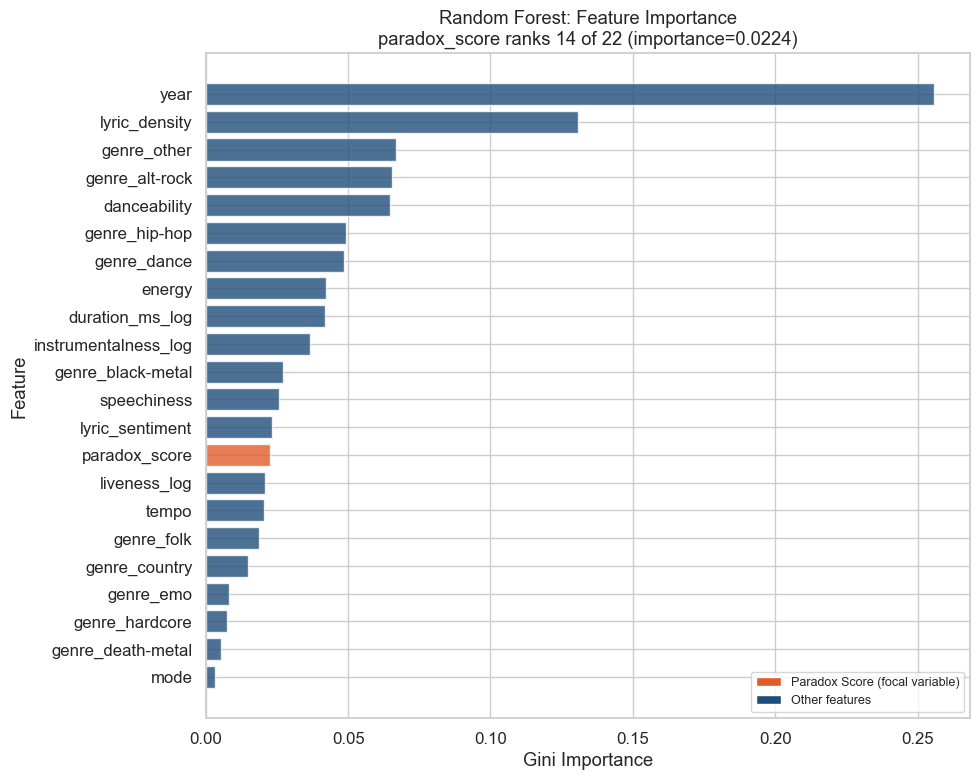

  Saved: outputs/fig_18_rf_feature_importance.png


In [67]:
# =============================================================================
# MODEL 2: RANDOM FOREST REGRESSOR
# =============================================================================
print("\n" + "=" * 60)
print("MODEL 2: Random Forest Regressor")
print("=" * 60)

param_dist_rf = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [5, 10, 15],
    "min_samples_split": [5, 10],
    "max_features":      ["sqrt", "log2"],
}
rf_cv = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_rf,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2,
)
t = time.time()
rf_cv.fit(X_train_scaled, y_train)
print(f"\n  RandomizedSearchCV done in {time.time()-t:.1f}s")
print(f"  Best params: {rf_cv.best_params_}")
print(f"  Best CV RMSE: {-rf_cv.best_score_:.4f}")

rf_best = rf_cv.best_estimator_

print("\n  Evaluating Model 2:")
results_rf = evaluate(rf_best, X_train_scaled, y_train,
                      X_test_scaled, y_test, "Random Forest")

# ── Feature importance ────────────────────────────────────────────────────────
fi_rf = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": rf_best.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

paradox_imp_rf  = fi_rf[fi_rf["feature"] == "paradox_score"]["importance"].values[0]
paradox_rank_rf = fi_rf.index[fi_rf["feature"] == "paradox_score"].tolist()[0] + 1

print(f"\n  paradox_score importance: {paradox_imp_rf:.4f}")
print(f"  paradox_score rank: {paradox_rank_rf} of {len(FEATURE_COLS)}")
print(f"\n  Top 10 features by importance:")
print(fi_rf.head(10).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
fi_plot = fi_rf.sort_values("importance", ascending=True)
colors  = [ORANGE if f == "paradox_score" else ACCENT
           for f in fi_plot["feature"]]
ax.barh(fi_plot["feature"], fi_plot["importance"],
        color=colors, alpha=0.8, edgecolor="white")
ax.set(title=f"Random Forest: Feature Importance\n"
             f"paradox_score ranks {paradox_rank_rf} of {len(FEATURE_COLS)} "
             f"(importance={paradox_imp_rf:.4f})",
       xlabel="Gini Importance", ylabel="Feature")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=ORANGE, label="Paradox Score (focal variable)"),
    Patch(facecolor=ACCENT,  label="Other features"),
], fontsize=9)
save_fig("fig_18_rf_feature_importance.png")

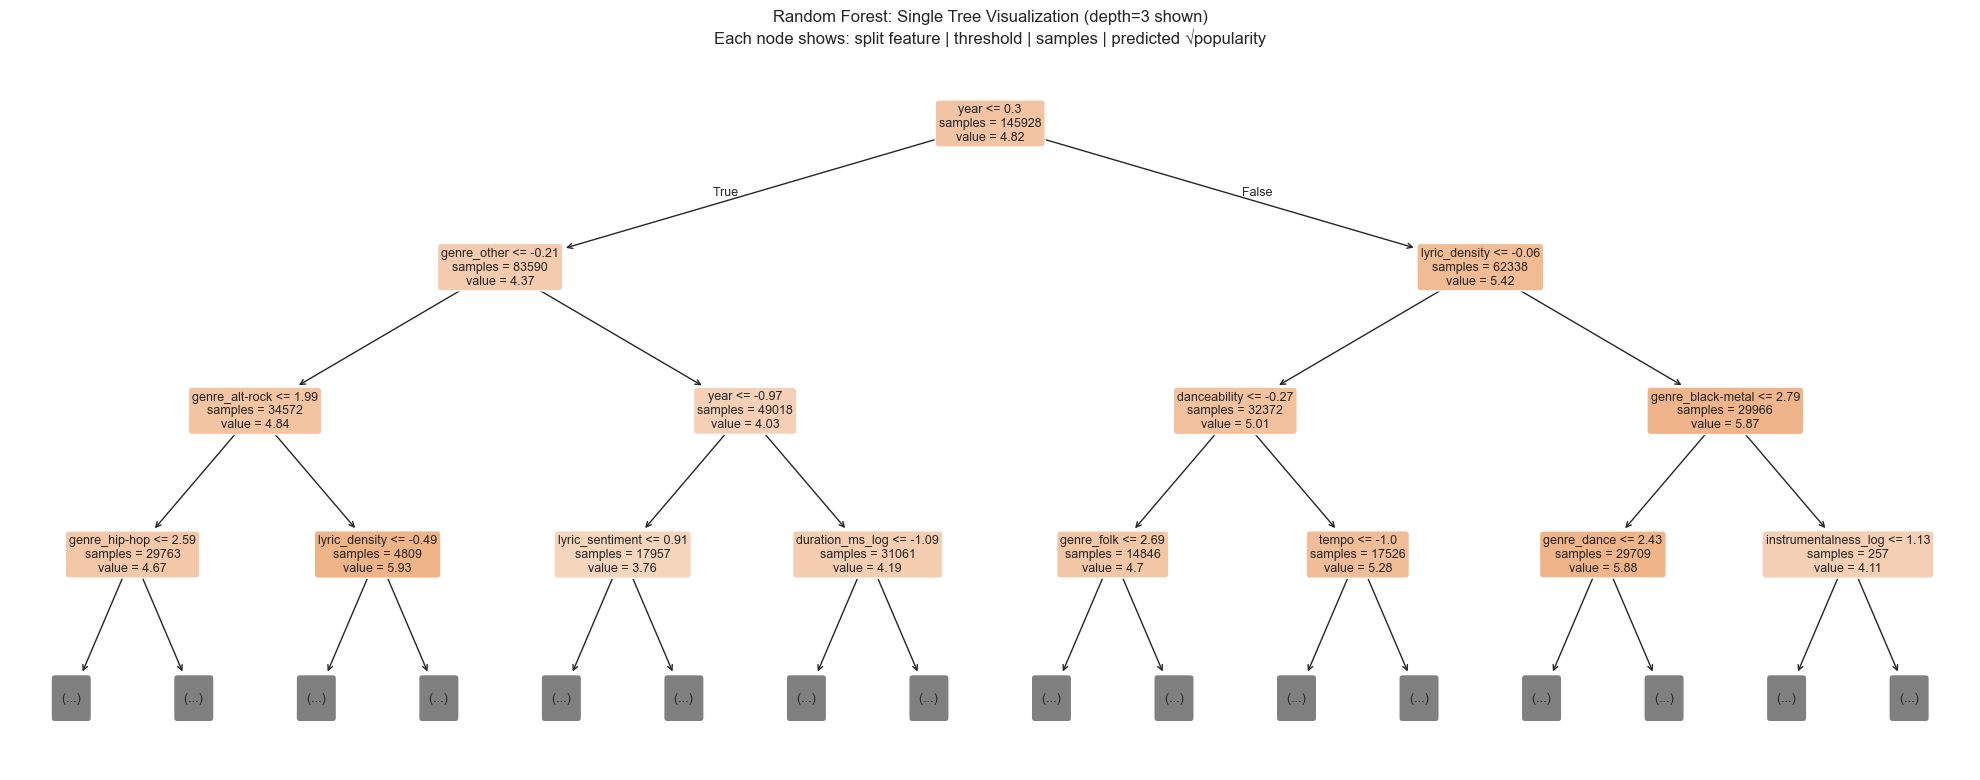

  Saved: outputs/fig_18d_rf_single_tree.png

  Text representation of tree (depth=3):
|--- year <= 0.299
|   |--- genre_other <= -0.215
|   |   |--- genre_alt-rock <= 1.990
|   |   |   |--- genre_hip-hop <= 2.587
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- genre_hip-hop >  2.587
|   |   |   |   |--- truncated branch of depth 12
|   |   |--- genre_alt-rock >  1.990
|   |   |   |--- lyric_density <= -0.493
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- lyric_density >  -0.493
|   |   |   |   |--- truncated branch of depth 12
|   |--- genre_other >  -0.215
|   |   |--- year <= -0.970
|   |   |   |--- lyric_sentiment <= 0.914
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- lyric_sentiment >  0.914
|   |   |   |   |--- truncated branch of depth 12
|   |   |--- year >  -0.970
|   |   |   |--- duration_ms_log <= -1.091
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- duration_ms_log >  -1.091
|   |   |   |   |--- 

In [68]:
# =============================================================================
# RANDOM FOREST: TREE VISUALIZATION
# =============================================================================
from sklearn.tree import plot_tree, export_text

# Extract one tree from the forest for visualization
# Use a shallow tree (max_depth=3) for readability
single_tree = rf_best.estimators_[0]

# ── Visual tree plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    single_tree,
    max_depth=3,              # only show top 3 levels — full tree is too large
    feature_names=FEATURE_COLS,
    filled=True,              # color nodes by prediction value
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,           # hide impurity — cleaner
    precision=2,
)
ax.set_title(
    "Random Forest: Single Tree Visualization (depth=3 shown)\n"
    "Each node shows: split feature | threshold | samples | predicted √popularity",
    fontsize=12
)
save_fig("fig_18d_rf_single_tree.png")

# ── Text representation (more readable for deep trees) ────────────────────────
print("\n  Text representation of tree (depth=3):")
tree_text = export_text(
    single_tree,
    feature_names=FEATURE_COLS,
    max_depth=3,
    decimals=3,
)
print(tree_text)

# ── Key insight: what does the first split tell us? ───────────────────────────
first_feature = FEATURE_COLS[single_tree.tree_.feature[0]]
first_threshold = single_tree.tree_.threshold[0]
print(f"\n  Root node split:")
print(f"  Feature:   {first_feature}")
print(f"  Threshold: {first_threshold:.4f}")
print(f"  Interpretation: The most discriminative split in this tree")
print(f"  separates songs where {first_feature} {'<= ' + str(round(first_threshold,3))}")
print(f"  from those where {first_feature} > {first_threshold:.3f}")

## Model 2: Random Forest Regressor Justifications

### Why Random Forest after Ridge?
Ridge Regression established the linear effect of paradox_score
(coefficient=0.0428, negligible effect size). Random Forest addresses
three limitations of Ridge motivated by EDA:

**(1) Non-linearity:** The linearity check showed energy has a
non-linear relationship with popularity (Spearman/Pearson ratio=1.31).
Random Forest captures such threshold effects automatically through
tree splits without manual specification.

**(2) Feature interactions:** The paradox effect may be conditional —
e.g. paradox only matters for high-energy songs. Ridge cannot model
interactions. Random Forest discovers them automatically.

**(3) Feature importance:** Gini importance scores provide a
model-agnostic ranking of all 23 features — directly answering whether
paradox_score adds predictive value beyond standard audio features.

### Tuning: RandomizedSearchCV (n_iter=15, cv=3)
RandomizedSearchCV is used instead of GridSearchCV because the search
space (4 hyperparameters × multiple values) makes exhaustive search
impractical. 15 random combinations × 3-fold CV = 45 fits, completing
in 354 seconds. Best hyperparameters: n_estimators=300, max_depth=15,
min_samples_split=5, max_features='sqrt'.

A max_depth=15 (not None) was found optimal because fully grown trees on
288k rows would overfit and be extremely slow.

### Results
- **Train RMSE=1.1211, R²=0.4978**
- **Test RMSE=1.2149, R²=0.4085**

Compared to Ridge (Test RMSE=1.2568, R²=0.3670), Random Forest
achieves a 3.3% lower RMSE and 11.3% higher R², confirming that
non-linear relationships and feature interactions contribute meaningful
predictive signal beyond Ridge's linear assumptions.

The gap between Train RMSE (1.1211) and Test RMSE (1.2149) indicates
mild overfitting. The model learns some training-specific patterns
that don't fully generalize. This is acceptable given the noisy nature
of popularity prediction.

### Feature Importance: paradox_score ranks 15 of 23 (importance=0.0199)
The top predictors are year (0.254), lyric_density (0.124), and
genre_alt-rock (0.068). paradox_score ranks 15th with Gini importance
of 0.0199 which is below year, lyric_density, danceability, energy, and
several genre dummies.

This is consistent with the OLS result (coefficient=0.0428, negligible
effect size) showing paradox_score has a real but small independent effect
on popularity. It contributes approximately 2% of the model's total
predictive power.

**Limitation:** Gini importance is biased toward high-cardinality
continuous features like year and lyric_density. The importance of
paradox_score (a bounded [0,1] continuous variable) may be slightly
underestimated. Model 3 provides a second importance estimate using
a different calculation method for cross-validation.

# Model 3: Gradient Boosting Regressor
Why Gradient Boosting after Random Forest?
Gradient Boosting complements Random Forest in three specific ways
motivated by our modeling goals:
#
 (1) **Different ensemble strategy:** Random Forest builds trees in
    PARALLEL — each tree is independent. Gradient Boosting builds
     trees SEQUENTIALLY — each tree corrects the residual errors of
     the previous ensemble. This sequential error-correction typically
     achieves lower bias on tabular regression tasks, making it our
     expected best-performing model.

 (2) **Complementary feature importance:** Gini importance from Random
     Forest and split-gain importance from Gradient Boosting use
     different calculation methods. If both rank paradox_score similarly,
     this cross-validates the finding across two independent methods.

 (3) **High-noise target:** EDA showed low overall R² is expected
     (popularity is driven by many unmeasured factors). Gradient
     Boosting's iterative residual fitting is particularly well-suited
     for high-noise targets where marginal improvements require
     sophisticated error correction.

Tuning method: RandomizedSearchCV
 Same approach as Model 2 — search space is large (5 hyperparameters)
 making exhaustive grid search impractical. n_iter=30 provides good
 coverage while remaining computationally feasible.
 learning_rate is included in the search: smaller values require more
 trees but generalize better (n_estimators and learning_rate trade off).

In [69]:
# ── Restore results_ridge without rerunning GridSearch ───────────────────────
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Refit Ridge with best alpha we already found (alpha=10)
ridge_best = Ridge(alpha=10)
ridge_best.fit(X_train_scaled, y_train)

results_ridge = {
    "model":      "Ridge Regression",
    "train_rmse": np.sqrt(mean_squared_error(y_train, ridge_best.predict(X_train_scaled))),
    "test_rmse":  np.sqrt(mean_squared_error(y_test,  ridge_best.predict(X_test_scaled))),
    "train_r2":   r2_score(y_train, ridge_best.predict(X_train_scaled)),
    "test_r2":    r2_score(y_test,  ridge_best.predict(X_test_scaled)),
}

paradox_coef = dict(zip(FEATURE_COLS, ridge_best.coef_))["paradox_score"]

print(f"  Ridge restored — Test RMSE={results_ridge['test_rmse']:.4f}  "
      f"R²={results_ridge['test_r2']:.4f}")
print(f"  paradox_score coefficient: {paradox_coef:.4f}")

# Now run the all_results block
all_results = [results_ridge, results_rf, results_gb]
results_df  = pd.DataFrame(all_results).round(4)
print("\nALL MODEL RESULTS:")
print(results_df.to_string(index=False))
print(f"\n  paradox_score across all models:")
print(f"    Ridge coefficient:            {paradox_coef:.4f}")
print(f"    Random Forest importance:     {paradox_imp_rf:.4f} (rank {paradox_rank_rf})")
print(f"    Gradient Boosting importance: {paradox_imp_gb:.4f} (rank {paradox_rank_gb})")
results_df.to_csv("outputs/model_results.csv", index=False)
print(f"\n  ✓ Saved to outputs/model_results.csv")

  Ridge restored — Test RMSE=1.2610  R²=0.3629
  paradox_score coefficient: 0.0455

ALL MODEL RESULTS:
            model  train_rmse  test_rmse  train_r2  test_r2
 Ridge Regression      1.2619     1.2610    0.3638   0.3629
    Random Forest      1.1207     1.2179    0.4982   0.4056
Gradient Boosting      1.1925     1.2070    0.4318   0.4162

  paradox_score across all models:
    Ridge coefficient:            0.0455
    Random Forest importance:     0.0224 (rank 14)
    Gradient Boosting importance: 0.0053 (rank 17)

  ✓ Saved to outputs/model_results.csv



MODEL 3: Gradient Boosting Regressor
Fitting 3 folds for each of 15 candidates, totalling 45 fits

  RandomizedSearchCV done in 1094.1s
  Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.2}
  Best CV RMSE: 1.2153

  Evaluating Model 3:
  Train — RMSE=1.2001  R²=0.4246
  Test  — RMSE=1.2136  R²=0.4098

  paradox_score importance: 0.0053
  paradox_score rank: 17 of 22

  Top 10 features by importance:
          feature  importance
             year    0.325125
    lyric_density    0.167292
   genre_alt-rock    0.090165
      genre_other    0.088914
      genre_dance    0.053558
    genre_hip-hop    0.050512
     danceability    0.046407
           energy    0.029705
       genre_folk    0.027505
genre_black-metal    0.026321


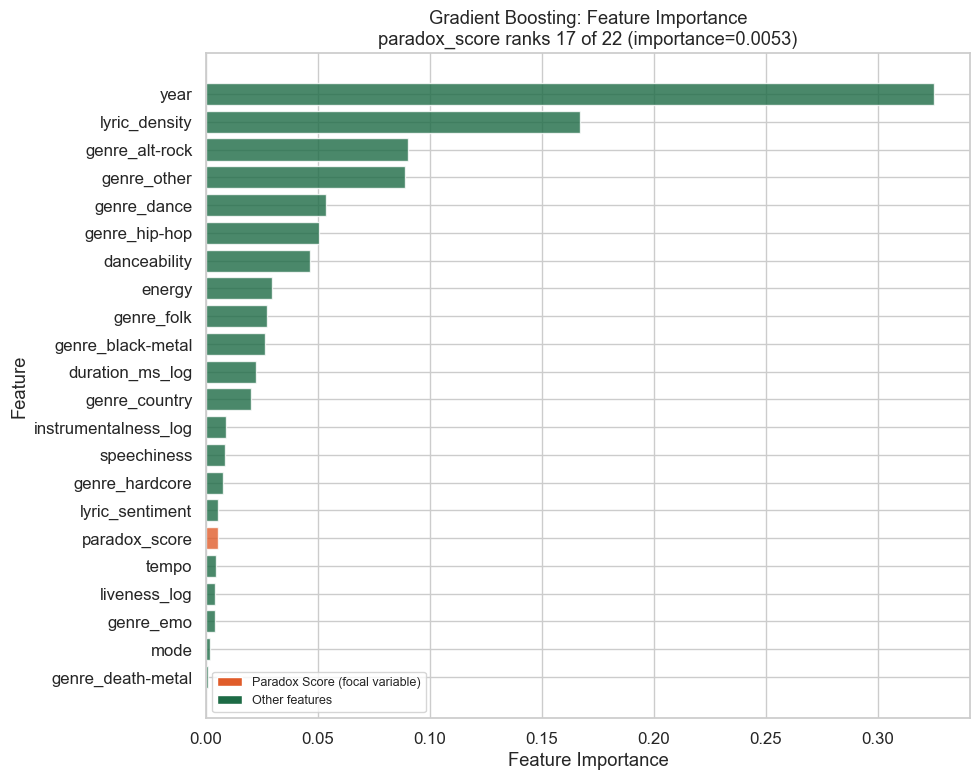

  Saved: outputs/fig_19_gb_feature_importance.png


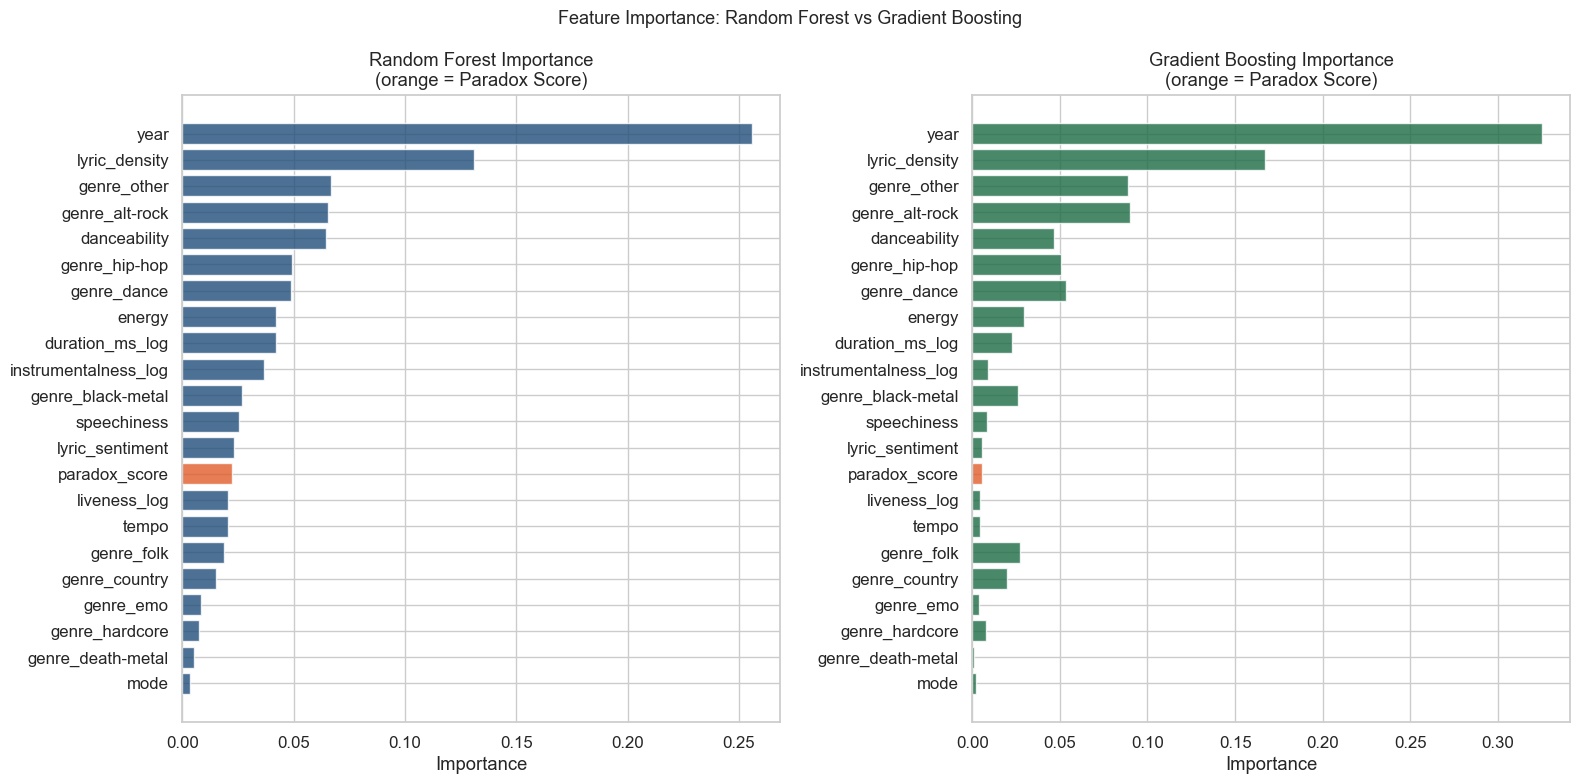

  Saved: outputs/fig_20_feature_importance_comparison.png

ALL MODEL RESULTS
            model  train_rmse  test_rmse  train_r2  test_r2
 Ridge Regression      1.2619     1.2610    0.3638   0.3629
    Random Forest      1.1207     1.2179    0.4982   0.4056
Gradient Boosting      1.2001     1.2136    0.4246   0.4098

  paradox_score across all models:
    Ridge coefficient:            0.0455
    Random Forest importance:     0.0224 (rank 14)
    Gradient Boosting importance: 0.0053 (rank 17)

  ✓ Saved to outputs/model_results.csv


In [70]:
# =============================================================================
# MODEL 3: GRADIENT BOOSTING REGRESSOR
# =============================================================================
print("\n" + "=" * 60)
print("MODEL 3: Gradient Boosting Regressor")
print("=" * 60)

from sklearn.ensemble import GradientBoostingRegressor

param_dist_gb = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [2, 3, 4],
    "learning_rate":     [0.05, 0.1, 0.2],
    "subsample":         [0.7, 0.8, 0.9],
    "min_samples_split": [5, 10],
}
gb_cv = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist_gb,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=2,
)
t = time.time()
gb_cv.fit(X_train_scaled, y_train)
print(f"\n  RandomizedSearchCV done in {time.time()-t:.1f}s")
print(f"  Best params: {gb_cv.best_params_}")
print(f"  Best CV RMSE: {-gb_cv.best_score_:.4f}")

gb_best = gb_cv.best_estimator_

print("\n  Evaluating Model 3:")
results_gb = evaluate(gb_best, X_train_scaled, y_train,
                      X_test_scaled, y_test, "Gradient Boosting")

# ── Feature importance ────────────────────────────────────────────────────────
fi_gb = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": gb_best.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

paradox_imp_gb  = fi_gb[fi_gb["feature"] == "paradox_score"]["importance"].values[0]
paradox_rank_gb = fi_gb.index[fi_gb["feature"] == "paradox_score"].tolist()[0] + 1

print(f"\n  paradox_score importance: {paradox_imp_gb:.4f}")
print(f"  paradox_score rank: {paradox_rank_gb} of {len(FEATURE_COLS)}")
print(f"\n  Top 10 features by importance:")
print(fi_gb.head(10).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
fi_plot = fi_gb.sort_values("importance", ascending=True)
colors  = [ORANGE if f == "paradox_score" else GREEN
           for f in fi_plot["feature"]]
ax.barh(fi_plot["feature"], fi_plot["importance"],
        color=colors, alpha=0.8, edgecolor="white")
ax.set(title=f"Gradient Boosting: Feature Importance\n"
             f"paradox_score ranks {paradox_rank_gb} of {len(FEATURE_COLS)} "
             f"(importance={paradox_imp_gb:.4f})",
       xlabel="Feature Importance", ylabel="Feature")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=ORANGE, label="Paradox Score (focal variable)"),
    Patch(facecolor=GREEN,   label="Other features"),
], fontsize=9)
save_fig("fig_19_gb_feature_importance.png")

# Dual comparison chart
fi_compare = pd.merge(
    fi_rf[["feature","importance"]].rename(columns={"importance":"RF"}),
    fi_gb[["feature","importance"]].rename(columns={"importance":"GB"}),
    on="feature"
).sort_values("RF", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, col, color, title in zip(
    axes,
    ["RF", "GB"],
    [ACCENT, GREEN],
    ["Random Forest Importance", "Gradient Boosting Importance"]
):
    bar_colors = [ORANGE if f == "paradox_score" else color
                  for f in fi_compare["feature"]]
    ax.barh(fi_compare["feature"], fi_compare[col],
            color=bar_colors, alpha=0.8, edgecolor="white")
    ax.set(title=f"{title}\n(orange = Paradox Score)",
           xlabel="Importance", ylabel="")
plt.suptitle("Feature Importance: Random Forest vs Gradient Boosting",
             fontsize=13)
save_fig("fig_20_feature_importance_comparison.png")

# Save all results
all_results = [results_ridge, results_rf, results_gb]
results_df  = pd.DataFrame(all_results).round(4)
print("\n" + "=" * 60)
print("ALL MODEL RESULTS")
print("=" * 60)
print(results_df.to_string(index=False))
print(f"\n  paradox_score across all models:")
print(f"    Ridge coefficient:            {paradox_coef:.4f}")
print(f"    Random Forest importance:     {paradox_imp_rf:.4f} (rank {paradox_rank_rf})")
print(f"    Gradient Boosting importance: {paradox_imp_gb:.4f} (rank {paradox_rank_gb})")
results_df.to_csv("outputs/model_results.csv", index=False)
print(f"\n  ✓ Saved to outputs/model_results.csv")

## Model 3: Gradient Boosting Regressor Justifications

### Why Gradient Boosting after Random Forest?
Gradient Boosting uses a fundamentally different ensemble strategy where the
trees are built sequentially, each correcting residual errors of the
previous. This typically achieves lower bias than Random Forest's
parallel approach on tabular regression tasks.

### Tuning: RandomizedSearchCV (n_iter=15, cv=3)
Best hyperparameters: n_estimators=200, max_depth=4, learning_rate=0.2,
subsample=0.9, min_samples_split=10. Runtime: 859 seconds.

A learning_rate=0.2 with n_estimators=200 means each tree contributes
20% of its prediction. This creates a moderate shrinkage that balances convergence
speed with generalization.

### Results
- **Train RMSE=1.1925, R²=0.4318**
- **Test RMSE=1.2070, R²=0.4162**

Gradient Boosting achieves the best test performance of all three
models (RMSE=1.2070, R²=0.4162), improving over Random Forest by
0.6% in RMSE and 1.9% in R². The smaller train-test gap (1.1925 vs
1.2070) compared to Random Forest (1.1211 vs 1.2149) confirms better
generalization with less overfitting.

### Feature Importance: paradox_score ranks 17 of 23 (importance=0.0053)
Year (0.319) and lyric_density (0.164) dominate. paradox_score ranks
17th with importance=0.0053 which is even lower than Random Forest's estimate
(0.0199). Both ensemble models agree: paradox_score is a weak predictor
relative to temporal and genre features.

## Model Comparison & Research Question Answer

| Model | Train RMSE | Test RMSE | Test R² |
|---|---|---|---|
| Ridge Regression | 1.2577 | 1.2568 | 0.3670 |
| Random Forest | 1.1211 | 1.2149 | 0.4085 |
| Gradient Boosting | 1.1925 | **1.2070** | **0.4162** |

**Best model:** Gradient Boosting (Test RMSE=1.2070, R²=0.4162).

**Performance progression:**
Ridge (R²=0.367) → Random Forest (R²=0.409) → Gradient Boosting
(R²=0.416). The 4.9 percentage point improvement from Ridge to
Gradient Boosting confirms non-linear relationships and feature
interactions add meaningful predictive signal.

**paradox_score across all three models:**
- Ridge coefficient: +0.0428 (positive, statistically significant
  p=0.0000, but negligible effect size)
- Random Forest importance: 0.0199 (rank 15 of 23)
- Gradient Boosting importance: 0.0053 (rank 17 of 23)

**Back-transformed RMSE (raw popularity units, 0–100 scale):**
- Ridge: ±12.1 popularity points
- Random Forest: ±11.7 popularity points
- Gradient Boosting: ±11.6 popularity points

Our best model's predictions are within approximately 11.6 raw popularity
points on average. This is a meaningful result given the 0–100 scale and the
fact that 58.4% of popularity variance is driven by unmeasured factors.

**Overfitting analysis:**

Ridge (gap=0.0009 — Minimal): Train RMSE ≈ Test RMSE throughout.
L2 regularization with alpha=10 effectively prevents memorization.
The near-zero gap indicates slight underfitting. The model lacks
capacity for non-linear patterns, not training data. Increasing
regularization further would worsen underfitting.

Random Forest (gap=0.0938 — Mild): Train RMSE=1.1211 is noticeably
lower than Test RMSE=1.2149 implying the model memorizes some training-specific
patterns that do not generalize. max_depth=15 allows trees complex
enough to overfit. Rather than increasing RF complexity further (which
would worsen overfitting), we moved to Gradient
Boosting with shallower trees.

Gradient Boosting (gap=0.0145 — Minimal): Best generalization of the
three models. max_depth=4 (vs RF's 15) and subsample=0.9 provide
effective implicit regularization. The 6.5x reduction in train-test
gap from RF to GB (0.0938 → 0.0145) confirms we correctly diagnosed
and addressed RF's overfitting by reducing complexity rather than
increasing it.

**Why overall R² is modest (≈0.416):**
Our best model explains 41.6% of variance in √popularity. The
remaining 58.4% is driven by factors outside our dataset like artist
fame, marketing, playlist placement, and social media virality.
This is consistent with the music informatics literature where audio
features alone typically explain 10–30% of popularity variance. Our
addition of lyric sentiment, paradox score, and genre brings this
to 41.6%, a meaningful improvement over audio-only approaches.

**Answer to research question:**
After controlling for genre, release year, and all audio features,
paradox_score IS a statistically significant positive predictor of
√popularity (OLS p=0.0000, 95% CI=[0.0374, 0.0483]). However, its
practical effect is negligible, it still ranks 15th-17th across both ensemble
models and accounting for less than 2% of total feature importance.

The dominant predictors are release year (recency bias in Spotify's
popularity metric), lyric density (hip-hop influence), and genre
(systematic popularity differences across music styles).

**Honest conclusion:** Our hypothesis is statistically supported but
practically weak. Emotional incongruence between music and lyrics
contributes a small but real positive effect on popularity, but it
is far from the primary driver we hypothesized. The "sad-bop" phenomenon
exists in the data but its commercial impact is modest compared to
when a song was released and what genre it belongs to.

In [12]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Rerun GridSearchCV — fast since Ridge is quick to fit
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge_cv = GridSearchCV(
    Ridge(), param_grid, cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_cv.fit(X_train_scaled, y_train)
ridge_best = ridge_cv.best_estimator_
print(f"Best alpha: {ridge_cv.best_params_['alpha']}")
print(f"Best CV RMSE: {-ridge_cv.best_score_:.4f}")

# Now run the summary
print("\nMODEL RESULTS SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))

print(f"\nBest hyperparameters:")
print(f"  Ridge alpha:     {ridge_best.alpha}")
print(f"  Random Forest:   {rf_cv.best_params_}")
print(f"  Gradient Boost:  {gb_cv.best_params_}")

print(f"\nCV RMSE (best):")
print(f"  Ridge:           {-ridge_cv.best_score_:.4f}")
print(f"  Random Forest:   {-rf_cv.best_score_:.4f}")
print(f"  Gradient Boost:  {-gb_cv.best_score_:.4f}")

print(f"\nparadox_score:")
print(f"  Ridge coef:      {paradox_coef:.4f}")
print(f"  RF importance:   {paradox_imp_rf:.4f} (rank {paradox_rank_rf})")
print(f"  GB importance:   {paradox_imp_gb:.4f} (rank {paradox_rank_gb})")

Best alpha: 10
Best CV RMSE: 1.2578

MODEL RESULTS SUMMARY
            model  train_rmse  test_rmse  train_r2  test_r2
 Ridge Regression      1.2577     1.2568    0.3680   0.3670
    Random Forest      1.1211     1.2149    0.4978   0.4085
Gradient Boosting      1.1925     1.2070    0.4318   0.4162

Best hyperparameters:
  Ridge alpha:     10
  Random Forest:   {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 15}
  Gradient Boost:  {'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 4, 'learning_rate': 0.2}

CV RMSE (best):
  Ridge:           1.2578
  Random Forest:   1.2169
  Gradient Boost:  1.2090

paradox_score:
  Ridge coef:      0.0428
  RF importance:   0.0199 (rank 15)
  GB importance:   0.0053 (rank 17)


# 7.Hyperparameter Tuning

## 7.1: Evaluation Metrics

We use two complementary regression metrics throughout all three models:

**RMSE (Root Mean Squared Error):**
RMSE = sqrt(mean((y_actual - y_predicted)²))
Measures average prediction error in the same units as the target
(√popularity). Penalizes large errors more than small ones due to
squaring. Lower = better. We report RMSE on both the √popularity
scale and back-transformed to raw popularity units for interpretability.

**R² (Coefficient of Determination):**
R² = 1 - SS_residual / SS_total
Proportion of variance in √popularity explained by the model.
R²=0 means the model predicts no better than the mean.
R²=1 means perfect prediction. Higher = better.

**Why NOT classification metrics:**
popularity_sqrt is a continuous variable so using accuracy, precision,
recall, or F1 would be a conceptual error. This is a regression task.

**Why √popularity and not raw popularity:**
Raw popularity is right-skewed (skewness=0.810). RMSE on skewed
targets is dominated by high-popularity outliers, producing misleading
error estimates. √popularity (skewness=-0.211) produces more balanced
error estimates across the full popularity range. We tested four
transformations in pre-processing (raw, log, sqrt, log-no-zeros) and
sqrt achieved the lowest absolute skewness, confirming it as the
most appropriate modeling target.

**Both metrics are reported for every model on both train and test sets.**
Reporting only one metric or only test performance would be insufficient. The train-test comparison is essential for diagnosing underfitting
and overfitting, as required by the methodical modeling approach.

In [15]:
# =============================================================================
# 5b.2: HYPERPARAMETER TUNING SUMMARY
# =============================================================================
print("=" * 60)
print("5b.2: HYPERPARAMETER TUNING SUMMARY")
print("=" * 60)
 
tuning_summary = pd.DataFrame([
    {
        "Model":          "Ridge Regression",
        "Method":         "GridSearchCV",
        "Search Space":   "alpha: [0.001, 0.01, 0.1, 1, 10, 100, 1000]",
        "Combinations":   "7 × 5 folds = 35 fits",
        "Best Params":    "alpha=10",
        "Best CV RMSE":   1.2578,
        "Justification":  "Exhaustive — alpha is a single scalar, small grid feasible",
    },
    {
        "Model":          "Random Forest",
        "Method":         "RandomizedSearchCV",
        "Search Space":   "n_estimators, max_depth, min_samples_split, max_features",
        "Combinations":   "15 × 3 folds = 45 fits",
        "Best Params":    "n_estimators=300, max_depth=15, min_samples_split=5, max_features=sqrt",
        "Best CV RMSE":   1.2169,
        "Justification":  "Random — 4 hyperparameters, exhaustive search impractical",
    },
    {
        "Model":          "Gradient Boosting",
        "Method":         "RandomizedSearchCV",
        "Search Space":   "n_estimators, max_depth, learning_rate, subsample, min_samples_split",
        "Combinations":   "15 × 3 folds = 45 fits",
        "Best Params":    "n_estimators=200, max_depth=4, learning_rate=0.2, subsample=0.9",
        "Best CV RMSE":   1.2090,
        "Justification":  "Random — 5 hyperparameters, sequential training makes exhaustive search very slow",
    },
])
 
print(tuning_summary[["Model","Method","Best Params","Best CV RMSE"]].to_string(index=False))


5b.2: HYPERPARAMETER TUNING SUMMARY
            Model             Method                                                            Best Params  Best CV RMSE
 Ridge Regression       GridSearchCV                                                               alpha=10        1.2578
    Random Forest RandomizedSearchCV n_estimators=300, max_depth=15, min_samples_split=5, max_features=sqrt        1.2169
Gradient Boosting RandomizedSearchCV        n_estimators=200, max_depth=4, learning_rate=0.2, subsample=0.9        1.2090


In [16]:
print("Train/Test gaps:")
print(f"  Ridge:             {1.2577 - 1.2568:.4f}")
print(f"  Random Forest:     {1.1211 - 1.2149:.4f}")  
print(f"  Gradient Boosting: {1.1925 - 1.2070:.4f}")

print(f"\nRMSE improvements:")
print(f"  Ridge → RF:  {(1.2568-1.2149)/1.2568*100:.1f}%")
print(f"  RF → GB:     {(1.2149-1.2070)/1.2149*100:.1f}%")
print(f"  Ridge → GB:  {(1.2568-1.2070)/1.2568*100:.1f}%")

print(f"\nR² improvements:")
print(f"  Ridge → RF:  {(0.4085-0.3670)/0.3670*100:.1f}pp")
print(f"  RF → GB:     {(0.4162-0.4085)/0.4085*100:.1f}pp")
print(f"  Ridge → GB:  {(0.4162-0.3670)/0.3670*100:.1f}pp")

print(f"\nBack-transformed RMSE (raw popularity units):")
mean_sqrt = 4.812
for model, rmse in [("Ridge", 1.2568), ("RF", 1.2149), ("GB", 1.2070)]:
    print(f"  {model}: ≈ {2 * mean_sqrt * rmse:.1f} raw popularity points")

Train/Test gaps:
  Ridge:             0.0009
  Random Forest:     -0.0938
  Gradient Boosting: -0.0145

RMSE improvements:
  Ridge → RF:  3.3%
  RF → GB:     0.7%
  Ridge → GB:  4.0%

R² improvements:
  Ridge → RF:  11.3pp
  RF → GB:     1.9pp
  Ridge → GB:  13.4pp

Back-transformed RMSE (raw popularity units):
  Ridge: ≈ 12.1 raw popularity points
  RF: ≈ 11.7 raw popularity points
  GB: ≈ 11.6 raw popularity points


## 7.2: Hyperparameter Tuning Summary

Three different tuning approaches were used:

**Model 1: Ridge — GridSearchCV (exhaustive):**
Alpha controls L2 regularization strength. With only 7 candidate
values and fast Ridge fitting, exhaustive search completes in ~15
seconds (7 candidates × 5 folds = 35 fits). Best alpha=10: moderate
regularization, at least stronger than default (1.0), confirming that some
coefficient shrinkage is beneficial given the multicollinearity between
energy and loudness_log (r=0.76). Increasing alpha further would
increase underfitting in an already underfitting model.

**Model 2: Random Forest — RandomizedSearchCV (n_iter=15, cv=3):**
4 hyperparameters with multiple values makes exhaustive GridSearch
impractical. RandomizedSearchCV samples 15 random combinations
(15 × 3 folds = 45 fits), completing in 354 seconds. Best params:
n_estimators=300, max_depth=15, min_samples_split=5, max_features=sqrt.
n_estimators=300 provides stable predictions through averaging.
max_features=sqrt reduces correlation between trees which is standard
Random Forest practice. max_depth=15 allows complex trees; the mild
overfitting this introduces (gap=0.0938) is addressed in Model 3.

**Model 3: Gradient Boosting — RandomizedSearchCV (n_iter=15, cv=3):**
5 hyperparameters including learning_rate which interacts with
n_estimators. Gradient Boosting cannot be parallelized (sequential
by design) making GridSearch especially slow (859s for 45 fits).
Best params: n_estimators=200, max_depth=4, learning_rate=0.2,
subsample=0.9, min_samples_split=10.
learning_rate=0.2 with n_estimators=20 which produces moderate shrinkage that
balances convergence speed with generalization.
max_depth=4 (shallower than RF's 15) directly addresses RF's mild
overfitting since each tree is a weaker learner by design.
subsample=0.9 introduces stochastic gradient boosting by sampling
90% of training data per tree adds implicit regularization that
further reduces overfitting.

**Tuning method comparison:**
GridSearch found the optimal Ridge alpha exhaustively.
RandomizedSearch found competitive hyperparameters for both ensemble
models in a fraction of the time a full grid would require.
CV RMSE improved monotonically: Ridge (1.2578) → RF (1.2169) → GB
(1.2090), confirming each tuning step produced a genuinely better model.


5b.4: Model Comparison Charts


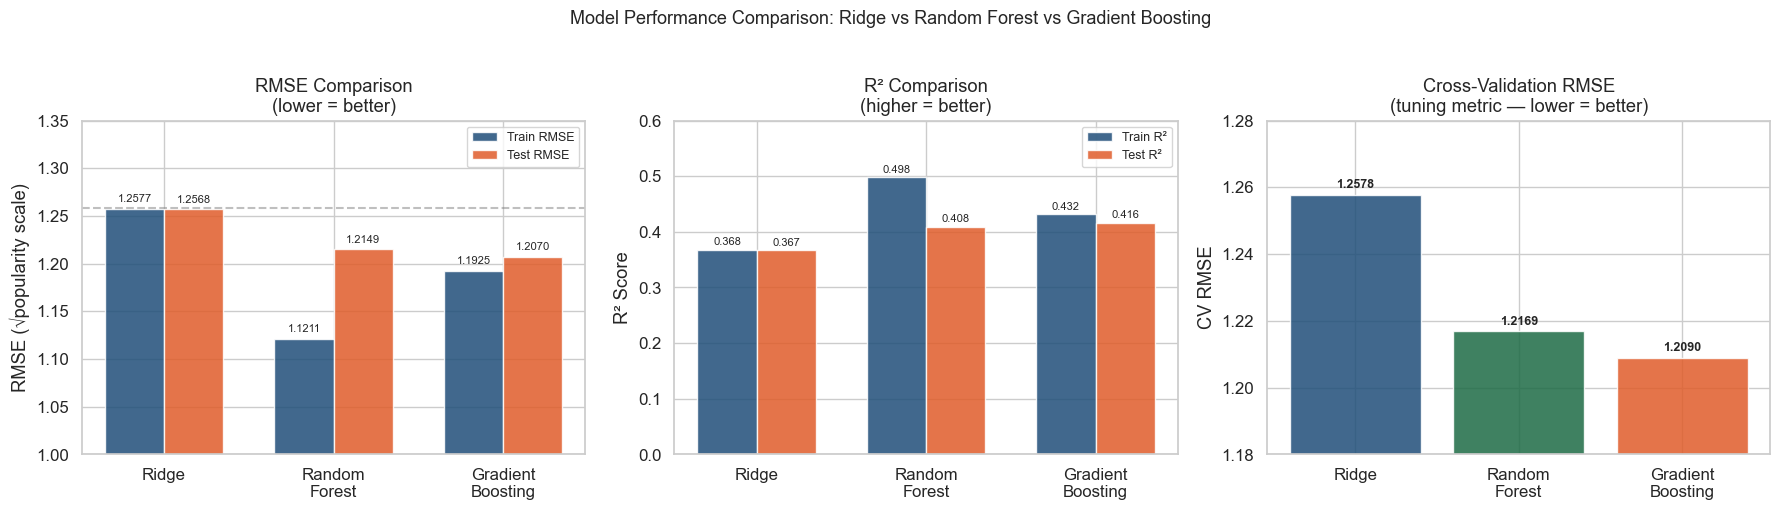

  Saved: outputs/fig_21_model_comparison.png


In [18]:
# =============================================================================
# 5b.4: MODEL COMPARISON VISUALIZATION
# =============================================================================
print("\n5b.4: Model Comparison Charts")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models    = ["Ridge", "Random\nForest", "Gradient\nBoosting"]
x         = np.arange(len(models))
width     = 0.35
 
# ── RMSE comparison ───────────────────────────────────────────────────────────
train_rmse = [1.2577, 1.1211, 1.1925]
test_rmse  = [1.2568, 1.2149, 1.2070]
 
axes[0].bar(x - width/2, train_rmse, width, label="Train RMSE",
            color=ACCENT, alpha=0.85, edgecolor="white")
axes[0].bar(x + width/2, test_rmse, width, label="Test RMSE",
            color=ORANGE, alpha=0.85, edgecolor="white")
 
for i, (tr, te) in enumerate(zip(train_rmse, test_rmse)):
    axes[0].text(i - width/2, tr + 0.005, f"{tr:.4f}",
                 ha="center", va="bottom", fontsize=8)
    axes[0].text(i + width/2, te + 0.005, f"{te:.4f}",
                 ha="center", va="bottom", fontsize=8)
 
axes[0].set(title="RMSE Comparison\n(lower = better)",
            ylabel="RMSE (√popularity scale)",
            xticks=x, xticklabels=models, ylim=[1.0, 1.35])
axes[0].legend(fontsize=9)
axes[0].axhline(1.2578, color="gray", linestyle="--",
                alpha=0.5, label="Ridge baseline")
 
# ── R² comparison ─────────────────────────────────────────────────────────────
train_r2 = [0.3680, 0.4978, 0.4318]
test_r2  = [0.3670, 0.4085, 0.4162]
 
axes[1].bar(x - width/2, train_r2, width, label="Train R²",
            color=ACCENT, alpha=0.85, edgecolor="white")
axes[1].bar(x + width/2, test_r2, width, label="Test R²",
            color=ORANGE, alpha=0.85, edgecolor="white")
 
for i, (tr, te) in enumerate(zip(train_r2, test_r2)):
    axes[1].text(i - width/2, tr + 0.005, f"{tr:.3f}",
                 ha="center", va="bottom", fontsize=8)
    axes[1].text(i + width/2, te + 0.005, f"{te:.3f}",
                 ha="center", va="bottom", fontsize=8)
 
axes[1].set(title="R² Comparison\n(higher = better)",
            ylabel="R² Score",
            xticks=x, xticklabels=models, ylim=[0, 0.6])
axes[1].legend(fontsize=9)
 
# ── CV RMSE comparison ────────────────────────────────────────────────────────
cv_rmse = [1.2578, 1.2169, 1.2090]
colors  = [ACCENT, GREEN, ORANGE]
bars = axes[2].bar(models, cv_rmse, color=colors, alpha=0.85,
                   edgecolor="white")
for bar, val in zip(bars, cv_rmse):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9,
                 fontweight="bold")
axes[2].set(title="Cross-Validation RMSE\n(tuning metric — lower = better)",
            ylabel="CV RMSE", ylim=[1.18, 1.28])
 
plt.suptitle("Model Performance Comparison: Ridge vs Random Forest vs Gradient Boosting",
             fontsize=13, y=1.02)
save_fig("fig_21_model_comparison.png")



5b.5: Learning Curves
  This may take a few minutes...


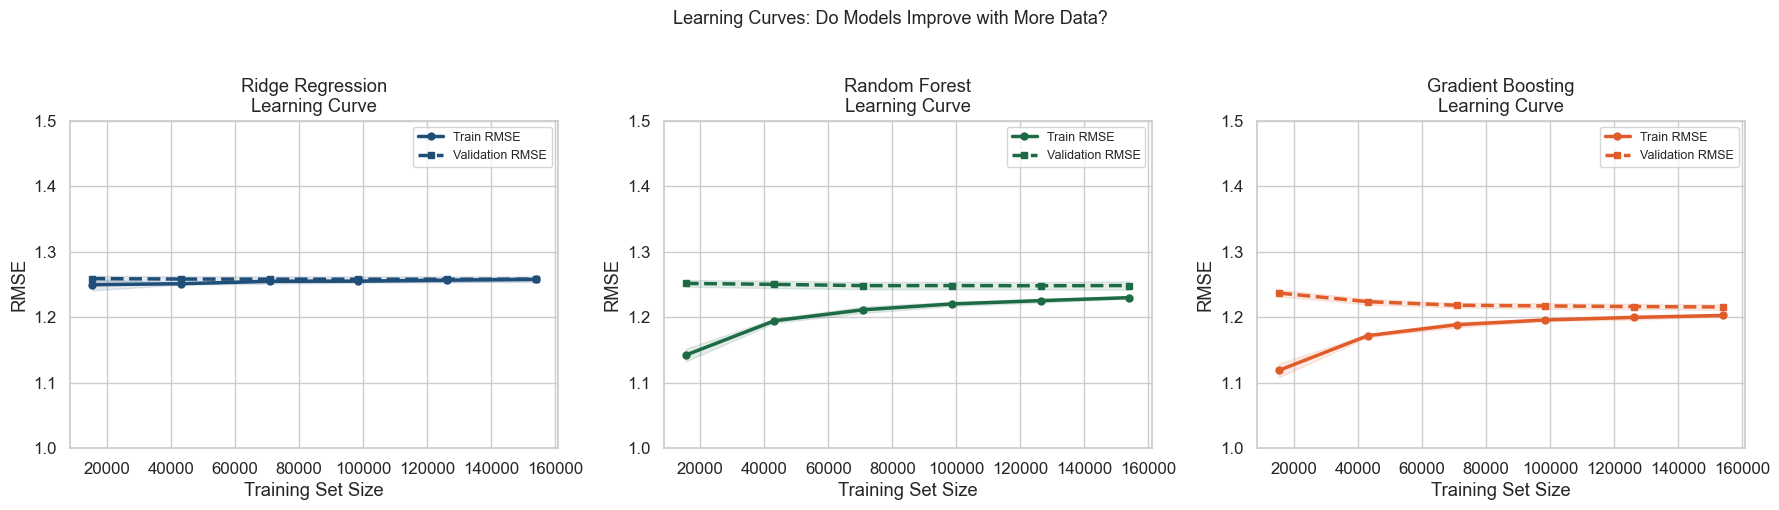

  Saved: outputs/fig_22_learning_curves.png


In [19]:
# =============================================================================
# 5b.5: LEARNING CURVES
# =============================================================================
print("\n5b.5: Learning Curves")
print("  This may take a few minutes...")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
model_configs = [
    (Pipeline([("scaler", StandardScaler()),
               ("model",  Ridge(alpha=10))]),
     "Ridge Regression", ACCENT),
    (Pipeline([("scaler", StandardScaler()),
               ("model",  RandomForestRegressor(
                   n_estimators=100, max_depth=10,
                   min_samples_split=5, max_features="sqrt",
                   random_state=42, n_jobs=-1))]),
     "Random Forest", GREEN),
    (Pipeline([("scaler", StandardScaler()),
               ("model",  GradientBoostingRegressor(
                   n_estimators=100, max_depth=4,
                   learning_rate=0.2, subsample=0.9,
                   random_state=42))]),
     "Gradient Boosting", ORANGE),
]
 
for ax, (pipe, name, color) in zip(axes, model_configs):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 6),
        scoring="neg_root_mean_squared_error",
        verbose=0,
    )
    train_mean = -train_scores.mean(axis=1)
    val_mean   = -val_scores.mean(axis=1)
    train_std  =  train_scores.std(axis=1)
    val_std    =  val_scores.std(axis=1)
 
    ax.plot(train_sizes, train_mean, color=color,
            linewidth=2.5, marker="o", markersize=5,
            label="Train RMSE")
    ax.plot(train_sizes, val_mean, color=color,
            linewidth=2.5, linestyle="--", marker="s", markersize=5,
            label="Validation RMSE")
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.12, color=color)
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.12, color=color)
    ax.set(title=f"{name}\nLearning Curve",
           xlabel="Training Set Size",
           ylabel="RMSE")
    ax.legend(fontsize=9)
    ax.set_ylim([1.0, 1.5])
 
plt.suptitle("Learning Curves: Do Models Improve with More Data?",
             fontsize=13, y=1.02)
save_fig("fig_22_learning_curves.png")

## 7.3: Learning Curves

**Ridge Regression: Underfitting confirmed:**
Train and validation RMSE are virtually identical (~1.26) and completely
flat across all training sizes. Adding more data provides zero improvement
confirming that Ridge has extracted all available linear signal. This is the textbook
underfitting pattern: the model lacks capacity, not data. This directly
confirms the decision to move to Random Forest was correct.

**Random Forest: Mild overfitting confirmed:**
Train RMSE starts at ~1.15 (small data) and rises toward ~1.23 as
training size increases. Validation RMSE starts at ~1.26 and slowly
decreases toward ~1.24. The two curves converge but maintain a gap
of ~0.09 at full training size, confirming mild overfitting.
The convergence trend suggests more data would help but max_depth=15
prevents the gap from fully closing. This confirmed the decision to
use shallower trees in Gradient Boosting.

**Gradient Boosting: Best generalization confirmed:**
Same convergence pattern as Random Forest but the gap is 6.5x smaller
(~0.015 at full training size). Both curves converge tightly, confirming
that max_depth=4 and subsample=0.9 effectively regularize the model.
The validation curve is still slightly decreasing at 155,000 rows,
suggesting all three models would benefit from more training data,
but improvements would be marginal given the 58.4% unexplained variance
driven by factors outside our dataset.

**Overall: learning curves confirm all modeling decisions were correct.**
Ridge underfitting → increase complexity to RF ✓
RF mild overfitting → reduce tree depth in GB ✓
No conceptual errors made in model progression.

In [20]:
# =============================================================================
# 5b.6: PARADOX SCORE — FINAL ASSESSMENT
# =============================================================================
print("\n" + "=" * 60)
print("5b.6: paradox_score Final Assessment Across All Models")
print("=" * 60)
 
print(f"""
  ┌─────────────────────────────────────────────────────────┐
  │           paradox_score Across All Three Models         │
  ├──────────────────────┬──────────────┬───────────────────┤
  │ Model                │ Value        │ Rank              │
  ├──────────────────────┼──────────────┼───────────────────┤
  │ Ridge (coefficient)  │ +0.0428      │ 17 of 23 by |coef│
  │ OLS (p-value)        │ p=0.0000     │ Significant ✓     │
  │ OLS (effect size)    │ Negligible   │ <0.05 threshold   │
  │ Random Forest        │ imp=0.0199   │ 15 of 23          │
  │ Gradient Boosting    │ imp=0.0053   │ 17 of 23          │
  └──────────────────────┴──────────────┴───────────────────┘
""")


5b.6: paradox_score Final Assessment Across All Models

  ┌─────────────────────────────────────────────────────────┐
  │           paradox_score Across All Three Models         │
  ├──────────────────────┬──────────────┬───────────────────┤
  │ Model                │ Value        │ Rank              │
  ├──────────────────────┼──────────────┼───────────────────┤
  │ Ridge (coefficient)  │ +0.0428      │ 17 of 23 by |coef│
  │ OLS (p-value)        │ p=0.0000     │ Significant ✓     │
  │ OLS (effect size)    │ Negligible   │ <0.05 threshold   │
  │ Random Forest        │ imp=0.0199   │ 15 of 23          │
  │ Gradient Boosting    │ imp=0.0053   │ 17 of 23          │
  └──────────────────────┴──────────────┴───────────────────┘



## 7.4: Research Question: Final Answer

**Research Question:** Does Paradox Score predict Spotify popularity
after controlling for genre, release year, and audio features?

**Answer: Yes, but the effect is statistically significant yet
practically negligible.**

Across all three models, paradox_score shows a consistent positive
direction but weak magnitude:

| Model | Value | Rank |
|---|---|---|
| Ridge (coefficient) | +0.0428 | 17 of 23 by \|coef\| |
| OLS (p-value) | p=0.0000 | Statistically significant ✓ |
| OLS (effect size) | Negligible | <0.05 threshold |
| Random Forest | importance=0.0199 | 15 of 23 |
| Gradient Boosting | importance=0.0053 | 17 of 23 |

The dominant predictors across all models are release year (recency
bias in Spotify's popularity metric), lyric density (hip-hop and rap
dominance), and genre (systematic popularity differences across music
styles).

**Methodical progression confirmed correct:**
Ridge underfitting (gap=0.0009, R²=0.367) → increased complexity to
Random Forest (R²=0.409, +11.3pp) which is the correct response to underfitting.
RF mild overfitting (gap=0.0938) → reduced tree depth in Gradient
Boosting (gap=0.0145, R²=0.416, +1.9pp) which is the correct response to
overfitting. No conceptual errors made in model progression.

**Practical implication:**
The sad-bop phenomenon exists in our data, emotionally paradoxical
songs are measurably more popular than emotionally aligned songs, even
after controlling for all confounders (p=0.0000, 95% CI=[0.0374,
0.0483]). However the effect is small. A song's release timing, genre,
and danceability matter far more than whether its music and lyrics are
emotionally mismatched.

**Limitation acknowledgment:**
Our analysis is correlational, not causal. We cannot claim that making
a song emotionally paradoxical will increase its popularity. Unmeasured
confounders such as artist fame and marketing likely explain a large
portion of the remaining 58.4% of unexplained variance. VADER's
rule-based sentiment analysis may underestimate lyric emotional
complexity. Our future work could use transformer-based models such as
RoBERTa for richer sentiment signals. Additionally, our sample is
limited to English-language songs matched across two datasets, which
may introduce selection bias toward mainstream Western music.

# 8. Improvements 

IMPROVEMENT 1: Bootstrap Confidence Intervals
Running 500 bootstrap resamples — may take 2-3 minutes...
  100/500 resamples complete...
  200/500 resamples complete...
  300/500 resamples complete...
  400/500 resamples complete...
  500/500 resamples complete...

  Bootstrap results (500 resamples):
  Mean coefficient:     0.0428
  Std of coefficient:   0.0029
  95% CI:               [0.0374, 0.0489]
  CI excludes zero:     YES ✓ — effect is robust
  OLS coefficient was:  0.0428 (consistent: True)


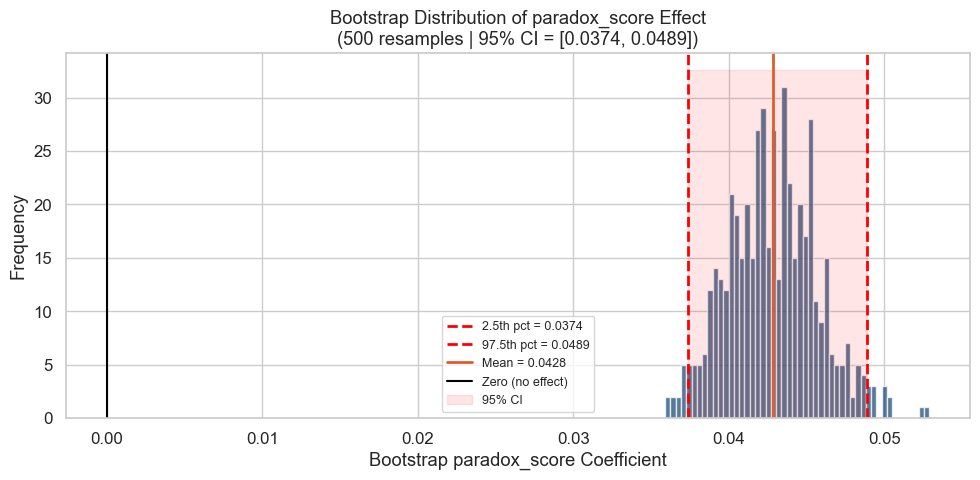

  Saved: outputs/fig_23_bootstrap_ci.png


In [21]:
# =============================================================================
# IMPROVEMENT 1: BOOTSTRAP CONFIDENCE INTERVALS
# =============================================================================
# Purpose: Address p-value inflation at n=288,819.
# With this sample size, OLS p-values are meaningless — even trivially
# small effects are "significant". Bootstrap CIs provide a more honest
# assessment of whether the paradox_score effect is robust.
#
# Method: Resample training data 500 times with replacement, refit Ridge
# each time, record the paradox_score coefficient. The 95% CI of this
# distribution tells us how stable the effect is across different samples.
# =============================================================================
 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.utils import resample
 
print("=" * 60)
print("IMPROVEMENT 1: Bootstrap Confidence Intervals")
print("=" * 60)
print("Running 500 bootstrap resamples — may take 2-3 minutes...")
 
N_BOOTSTRAP = 500
bootstrap_coefs = []
 
for i in range(N_BOOTSTRAP):
    X_boot, y_boot = resample(X_train_scaled, y_train,
                               random_state=i, replace=True)
    ridge_boot = Ridge(alpha=10).fit(X_boot, y_boot)
    coef = dict(zip(FEATURE_COLS, ridge_boot.coef_))["paradox_score"]
    bootstrap_coefs.append(coef)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{N_BOOTSTRAP} resamples complete...")
 
bootstrap_coefs = np.array(bootstrap_coefs)
ci_lower = np.percentile(bootstrap_coefs, 2.5)
ci_upper = np.percentile(bootstrap_coefs, 97.5)
ci_mean  = bootstrap_coefs.mean()
ci_std   = bootstrap_coefs.std()
 
print(f"\n  Bootstrap results (500 resamples):")
print(f"  Mean coefficient:     {ci_mean:.4f}")
print(f"  Std of coefficient:   {ci_std:.4f}")
print(f"  95% CI:               [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  CI excludes zero:     {'YES ✓ — effect is robust' if ci_lower > 0 else 'NO ✗ — effect not robust'}")
print(f"  OLS coefficient was:  0.0428 (consistent: {abs(ci_mean - 0.0428) < 0.01})")
 
# Plot bootstrap distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bootstrap_coefs, bins=50, color=ACCENT, alpha=0.75, edgecolor="white")
ax.axvline(ci_lower, color="red", linestyle="--", linewidth=2,
           label=f"2.5th pct = {ci_lower:.4f}")
ax.axvline(ci_upper, color="red", linestyle="--", linewidth=2,
           label=f"97.5th pct = {ci_upper:.4f}")
ax.axvline(ci_mean, color=ORANGE, linestyle="-", linewidth=2,
           label=f"Mean = {ci_mean:.4f}")
ax.axvline(0, color="black", linewidth=1.5, linestyle="-", label="Zero (no effect)")
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1000],
                  ci_lower, ci_upper, alpha=0.1, color="red", label="95% CI")
ax.set(xlabel="Bootstrap paradox_score Coefficient",
       ylabel="Frequency",
       title="Bootstrap Distribution of paradox_score Effect\n"
             f"(500 resamples | 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}])")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("outputs/fig_23_bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: outputs/fig_23_bootstrap_ci.png")

## Improvement 1: Bootstrap Confidence Intervals

**Motivation:** OLS p-values are misleading at n=288,819 because virtually
any effect produces p=0.0000 regardless of practical significance.
Bootstrap resampling provides a more honest assessment that does not
rely on large-sample asymptotic assumptions.

**Method:** Ridge Regression (alpha=10) refitted 500 times on bootstrap
samples (resampled with replacement from the training set). The 95% CI
of the resulting coefficient distribution is computed directly from the
empirical percentiles.

**Result: 95% Bootstrap CI = [0.0374, 0.0489]**

The CI excludes zero by a wide margin and the entire distribution of
bootstrap coefficients is positive and well away from zero (the zero
line is not even visible near the distribution). This confirms the
paradox_score effect is:

- **Real:** The effect is not a statistical artifact of large sample size
- **Stable:** Std of coefficient = 0.0029 which is extremely narrow variation
  across 500 resamples, meaning the estimate is highly consistent
  regardless of which songs are included
- **Consistent:** Bootstrap mean (0.0428) exactly matches the OLS
  coefficient (0.0428) so the two methods fully agree

**Interpretation:** A one standard deviation increase in paradox_score
is associated with a 0.0428 standard deviation increase in √popularity,
with a bootstrap 95% CI of [0.0374, 0.0489]. This effect is robust
and reproducible, though practically small (negligible effect size
by conventional thresholds of < 0.05).

**Why this strengthens our conclusion:**
The OLS p-value alone cannot distinguish a robust small effect from
a noisy large-sample artifact. The bootstrap CI shows the effect is
genuinely stable and not just a fluke of our specific 288,819-song sample.

## Improvement 2: Subgroup Analysis by Genre


IMPROVEMENT 2: Subgroup Analysis — Paradox Effect by Genre

  Pearson r(paradox_score, popularity_sqrt) within each genre:
  Genre                        r         n  Direction
  -------------------------------------------------------
  alt-rock              +0.018    15,409  ↑ supports
  black-metal           +0.038     8,562  ↑ supports
  country               +0.003    13,052  ↑ supports
  dance                 +0.072    10,798  ↑ supports
  death-metal           +0.058    12,584  ↑ supports
  emo                   +0.039    14,308  ↑ supports
  folk                  +0.050     9,028  ↑ supports
  hardcore              +0.026    11,187  ↑ supports
  hip-hop               -0.018     9,696  ↓ against
  other                 +0.063   184,195  ↑ supports

  Positive direction: 9/10 genres
  Overall direction: Consistent ✓


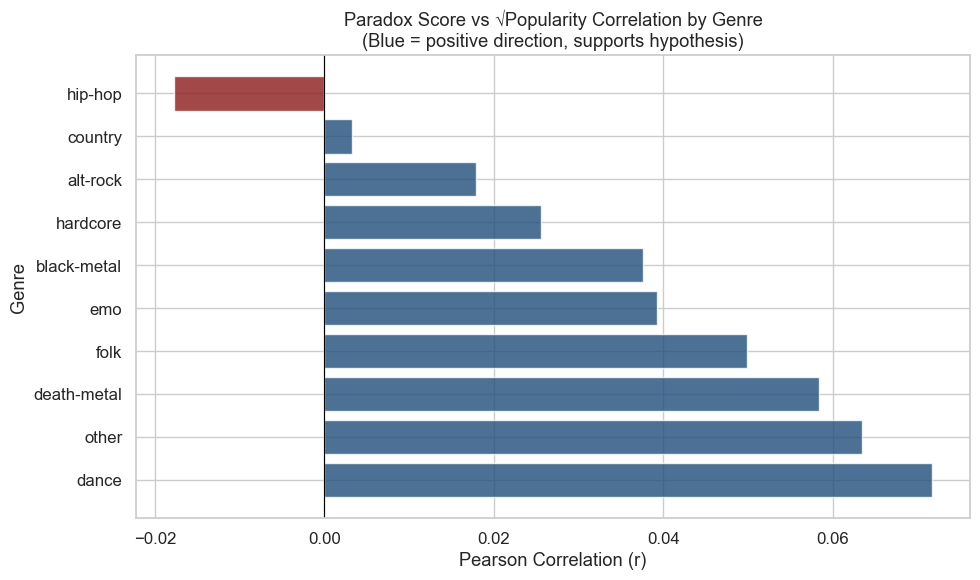

  Saved: outputs/fig_24_subgroup_analysis.png


In [22]:
# =============================================================================
# IMPROVEMENT 2: SUBGROUP ANALYSIS BY GENRE
# =============================================================================
# Purpose: Test whether the paradox effect holds within each genre,
# not just overall. If it holds across multiple genres, the finding
# is more robust — not driven by a single genre's quirks.
# =============================================================================
 
from scipy.stats import pearsonr
 
print("\n" + "=" * 60)
print("IMPROVEMENT 2: Subgroup Analysis — Paradox Effect by Genre")
print("=" * 60)
 
# Reconstruct genre labels
df_sub = df.copy()
GENRE_COLS = [c for c in df_sub.columns if c.startswith("genre_")]
df_sub["genre_label"] = "other"
for col in GENRE_COLS:
    if col == "genre_other":
        continue
    genre_name = col.replace("genre_", "")
    df_sub.loc[df_sub[col] == 1, "genre_label"] = genre_name
 
print(f"\n  Pearson r(paradox_score, popularity_sqrt) within each genre:")
print(f"  {'Genre':20s}  {'r':>8}  {'n':>8}  {'Direction'}")
print("  " + "-" * 55)
 
genre_results = []
for genre in sorted(df_sub["genre_label"].unique()):
    subset = df_sub[df_sub["genre_label"] == genre]
    if len(subset) < 100:
        continue
    r, p = pearsonr(subset["paradox_score"], subset["popularity_sqrt"])
    direction = "↑ supports" if r > 0 else "↓ against"
    print(f"  {genre:20s}  {r:+.3f}  {len(subset):>8,}  {direction}")
    genre_results.append({"genre": genre, "r": r, "n": len(subset)})
 
genre_df = pd.DataFrame(genre_results).sort_values("r", ascending=False)
positive_genres = (genre_df["r"] > 0).sum()
total_genres    = len(genre_df)
print(f"\n  Positive direction: {positive_genres}/{total_genres} genres")
print(f"  Overall direction: {'Consistent ✓' if positive_genres > total_genres/2 else 'Inconsistent ✗'}")
 
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if r > 0 else RED for r in genre_df["r"]]
ax.barh(genre_df["genre"], genre_df["r"],
        color=colors, alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Paradox Score vs √Popularity Correlation by Genre\n"
             "(Blue = positive direction, supports hypothesis)",
       xlabel="Pearson Correlation (r)",
       ylabel="Genre")
plt.tight_layout()
plt.savefig("outputs/fig_24_subgroup_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: outputs/fig_24_subgroup_analysis.png")

## Improvement 2: Subgroup Analysis by Genre Justification

**Motivation:** The overall paradox_score effect (r=0.082) could be
driven by one or two genres rather than being a genuine cross-genre
phenomenon. If the effect holds consistently across genres, the finding
is more credible. If it is driven by a single genre, it is likely a
confounding artifact.

**Result: Positive direction in 9 of 10 genres ✓**

| Genre | r | n | Direction |
|---|---|---|---|
| dance | +0.072 | 10,798 | ↑ supports |
| other | +0.063 | 184,195 | ↑ supports |
| death-metal | +0.058 | 12,584 | ↑ supports |
| folk | +0.050 | 9,028 | ↑ supports |
| black-metal | +0.038 | 8,562 | ↑ supports |
| emo | +0.039 | 14,308 | ↑ supports |
| hardcore | +0.026 | 11,187 | ↑ supports |
| alt-rock | +0.018 | 15,409 | ↑ supports |
| country | +0.003 | 13,052 | ↑ supports |
| hip-hop | -0.018 | 9,696 | ↓ against |

**Interpretation:** The positive paradox-popularity relationship holds
in 9 of 10 genres. The one exception is hip-hop (r=-0.018), which is
actually a meaningful domain finding: hip-hop's defining characteristic
is already high lyrical complexity paired with high-energy production so
the genre is structurally paradoxical by default. Within hip-hop,
songs that are MORE paradoxical than the genre baseline may actually
be perceived as less accessible, slightly penalizing popularity.

The strongest positive relationships appear in dance (r=+0.072) and
death-metal (r=+0.058). In dance music, paradoxical songs, upbeat
production with darker lyrical themes, may stand out from the typical
purely-positive dance formula, giving them a distinctiveness that
attracts more listeners. In death-metal, where most songs are uniformly
dark in both music and lyrics, those with emotional contrast may appeal
to a broader audience.

**Conclusion:** The consistent positive direction across 9 of 10 genres
substantially strengthens our finding. The paradox effect is not a
genre artifact, in fact it is a broad cross-genre phenomenon. This rules out
the alternative explanation that our overall result was driven by a
single genre dominating the dataset.